# =========================================
# TECH CHALLENGE - FASE 1
# Pós Tech Data Analytics
# Grupo: 12
# =========================================

Tema:

## **Impacto da Logística na Satisfação do Cliente  e Crescimento do Marketplace**

# 0 - Configuração do Ambiente Analítico

Antes do início das análises, foi realizada a preparação do ambiente utilizado no desenvolvimento deste projeto.

Nesta etapa foram definidas as configurações necessárias para importação dos dados, tratamento das informações, construção das análises e geração das visualizações apresentadas ao longo do estudo.

A organização prévia do ambiente contribuiu para a padronização das análises e para a reprodutibilidade dos resultados obtidos pela equipe.


In [97]:
# Baixa uma cópia completa do repositório do GitHub para o ambiente do Colab.
# Dessa forma, o notebook passa a enxergar as mesmas pastas e arquivos
# que existem no projeto publicado no GitHub.
!git clone https://github.com/erikacb1982/fiap-tech-challenge-olist

fatal: destination path 'fiap-tech-challenge-olist' already exists and is not an empty directory.


## 0.1 Importação das Bibliotecas

Foram importadas as bibliotecas necessárias para leitura, tratamento, análise e visualização dos dados utilizados neste projeto.

In [98]:
# Importa a biblioteca para interagir com arquivos e pastas.
import os

# Lista tudo que existe na pasta atual do Colab.
# O objetivo é verificar se o repositório foi baixado.
print(os.listdir())

['.config', 'fiap-tech-challenge-olist', 'drive', 'sample_data']


In [99]:
# Importa a biblioteca para trabalhar com arquivos e pastas.
import os

# Lista o conteúdo do repositório baixado do GitHub.
# O objetivo é verificar se a pasta "dados" existe.
print(os.listdir('fiap-tech-challenge-olist'))

['relatorio', 'index.html', '.git', 'dados', 'README.md', 'notebook']


In [100]:
#0.1 - Importando Bibliotecas

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Ignorar avisos
import warnings
warnings.filterwarnings('ignore')

In [101]:
# ============================================================
# 0.1 - Importação das Bibliotecas
# Biblioteca: os
# ============================================================
# Objetivo:
# Permitir a interação do Python com arquivos e pastas
# utilizados pelo projeto.
#
# Principais utilizações:
# - Listar arquivos da pasta de dados;
# - Validar a existência de arquivos;
# - Apoiar verificações de estrutura do projeto.
#
# Resultado esperado:
# Disponibilizar funções para acesso e validação dos
# arquivos armazenados no repositório.
# ============================================================

# Biblioteca para interação com arquivos e diretórios.
import os


## 0.2 Configuração do Pandas

Foram definidas configurações de exibição para facilitar a exploração e validação das bases de dados ao longo do estudo.

In [102]:
# Mostrar todas as colunas
pd.set_option('display.max_columns', None)

# Mostrar mais linhas
pd.set_option('display.max_rows', 100)

# Ajustar largura da exibição
pd.set_option('display.width', None)

# Mostrar números com 2 casas decimais
pd.options.display.float_format = '{:.2f}'.format

## 0.3 Configurações de Visualização

Foram estabelecidos padrões visuais para os gráficos apresentados neste relatório, contribuindo para maior consistência na apresentação dos resultados.

In [103]:
# ============================================================
# 0.3 - Configurações de Visualização
# ============================================================
# Objetivo:
# Definir configurações visuais padrão que serão utilizadas
# em todos os gráficos do projeto.
#
# Essas configurações garantem:
# - Padronização visual;
# - Maior legibilidade;
# - Consistência entre análises;
# - Melhor experiência para o leitor.
# ============================================================

# ------------------------------------------------------------
# Define o estilo visual padrão dos gráficos
# ------------------------------------------------------------
# O estilo "ggplot" é inspirado na biblioteca de visualização
# do R e oferece:
#
# - Fundo mais limpo;
# - Grid discreto para facilitar leitura;
# - Melhor contraste visual;
# - Aparência profissional para análises exploratórias.
# ------------------------------------------------------------

plt.style.use('ggplot')

# ------------------------------------------------------------
# Define o tamanho padrão das figuras
# ------------------------------------------------------------
# figsize = (largura, altura)
#
# Nesse caso:
# - largura = 10 polegadas
# - altura = 5 polegadas
#
# Benefícios:
# - Evita gráficos muito pequenos;
# - Mantém proporção adequada para visualização;
# - Padroniza a aparência ao longo do notebook.
# ------------------------------------------------------------

plt.rcParams['figure.figsize'] = (10, 5)

In [104]:
cor_padrao = '#3E5F8A'

In [105]:
# ==========================================
# PALETA EXECUTIVA PADRÃO DO PROJETO
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

COR_PRINCIPAL = "#3E5F8A"    # Destaque principal
COR_SECUNDARIA = "#6E8FB8"   # Comparações
COR_APOIO = "#B7CBE3"        # Categorias secundárias

COR_POSITIVO = "#4E7D5A"     # Resultados positivos
COR_ATENCAO = "#D4A017"      # Alertas
COR_NEGATIVO = "#B54747"     # Problemas críticos

COR_NEUTRO = "#6B7280"       # Informações auxiliares
COR_FUNDO = "#F8F9FA"        # Fundo dos gráficos

PALETA_EXECUTIVA = [
    COR_PRINCIPAL,
    COR_SECUNDARIA,
    COR_APOIO,
    COR_POSITIVO,
    COR_ATENCAO,
    COR_NEUTRO
]

## 0.4 - Criação de Funções de Apoio à Análise

**Problema de Negócio**

Ao longo da exploração dos dados, atividades como validação de bases, análise de variáveis, cálculo de indicadores e verificação de qualidade são executadas diversas vezes. A repetição dessas tarefas aumenta o volume de código, dificulta a manutenção do notebook e pode gerar diferenças na forma como as análises são realizadas.

**Objetivo**

Desenvolver funções reutilizáveis para automatizar tarefas recorrentes de exploração e análise dos dados, promovendo maior organização e consistência durante o desenvolvimento do projeto.

**Hipótese**

A utilização de funções padronizadas reduzirá a repetição de código, facilitará a manutenção do notebook e contribuirá para a execução mais consistente das análises.

**Decisão Apoiada**

Estabelecer uma estrutura de apoio que facilite a exploração inicial dos dados e ofereça suporte às etapas posteriores de preparação, análise e validação das informações.


In [106]:
#Padronizando Describe
def describe_pt(coluna, *args, **kwargs):

    return coluna.describe(*args, **kwargs).rename({
        'count': 'quantidade',
        'mean': 'média',
        'std': 'desvio_padrão',
        'min': 'mínimo',
        '25%': '1_quartil',
        '50%': 'mediana',
        '75%': '3_quartil',
        'max': 'máximo'
    })


In [107]:
# ============================================================
# Função para corrigir o símbolo R$ em textos Markdown
# ============================================================

def corrigir_real(texto):
    """
    Substitui R$ por R\$ para evitar problemas
    de renderização no Markdown do Colab/Jupyter.
    """

    return texto.replace('R$', 'R\\$')

In [108]:
# ============================================================
# Função padrão de tabelas do projeto
# Executar apenas uma vez no notebook
# ============================================================

def tabela_executiva(df):

    return (
        df.style

        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#3E5F8A"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", "1px solid #B7CBE3")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #B7CBE3"),
                    ("color", "#6B7280")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#F8F9FA")
                ]
            },
            {
                "selector": "tbody tr:nth-child(odd)",
                "props": [
                    ("background-color", "#FFFFFF")
                ]
            }
        ])

        .set_properties(**{
            "text-align": "center"
        })

        .hide(axis="index")
    )

## 0.5 - Organização e Validação dos Arquivos de Dados

**Problema de Negócio**

A utilização de arquivos incorretos, incompletos ou indisponíveis pode comprometer as etapas de importação e preparação dos dados. Antes do carregamento das bases, é necessário confirmar que todos os arquivos esperados estão disponíveis e corretamente identificados.

**Objetivo**

Organizar e validar a estrutura dos arquivos utilizados no projeto, verificando sua disponibilidade e identificação antes da etapa de importação dos dados.

**Hipótese**

A validação prévia dos arquivos facilitará o processo de carga das bases e permitirá identificar eventuais inconsistências antes do início das análises.

**Decisão Apoiada**

Confirmar que as etapas subsequentes serão executadas utilizando os arquivos previstos para o desenvolvimento do estudo.


### 0.5.1 - Definição dos Caminhos de Acesso

Foi definido o diretório principal do projeto no Google Drive, que será utilizado como referência para localização e acesso aos arquivos necessários para o desenvolvimento das análises.


In [109]:
# ==========================================================
# 0.5.1 Configuração do Caminho dos Dados
# ==========================================================
# Objetivo:
# Definir o local onde estão armazenados os arquivos
# de dados utilizados no projeto.
#
# Decisão que apoia:
# Permitir que o notebook execute em qualquer máquina,
# utilizando os arquivos disponíveis no repositório GitHub,
# sem dependência de Google Drive ou caminhos locais.
# ==========================================================

# Importa a classe Path para trabalhar com caminhos de
# arquivos e pastas de forma compatível com diferentes
# sistemas operacionais.
from pathlib import Path

# Define a pasta onde estão armazenados os arquivos
# de dados do projeto.
CAMINHO_DADOS = Path("fiap-tech-challenge-olist/dados")

# Exibe o caminho configurado para validação.
print(CAMINHO_DADOS)

fiap-tech-challenge-olist/dados


In [110]:
# Exibe o valor atual armazenado na variável.
print(CAMINHO_DADOS)


fiap-tech-challenge-olist/dados


### 0.5.2 - Identificação dos Arquivos de Dados

**Objetivo**

Listar os arquivos disponíveis no diretório do projeto antes da etapa de importação dos dados.

**Decisão Apoiada**

Verificar se os arquivos esperados estão disponíveis e acessíveis para utilização nas etapas subsequentes da análise.

**Pergunta**

Quais arquivos estão disponíveis na pasta do projeto?


In [111]:
# Exibe o valor atual da variável.
print(CAMINHO_DADOS)

fiap-tech-challenge-olist/dados


In [112]:
# Importa a biblioteca para listar arquivos e pastas.
import os

# Lista todos os arquivos existentes na pasta de dados.
arquivos = os.listdir(CAMINHO_DADOS)

# Exibe cada arquivo encontrado.
for arquivo in arquivos:
    print(arquivo)

olist_order_payments_dataset.csv
olist_geolocation_dataset.csv
.gitkeep
olist_order_reviews_dataset.csv
olist_sellers_dataset.csv
olist_customers_dataset.csv
product_category_name_translation.csv
olist_order_items_dataset.csv
olist_products_dataset.csv
olist_orders_dataset.csv


### 0.5.3 - Validação dos Arquivos Disponíveis

Após a identificação dos arquivos presentes no diretório do projeto, foi realizada a conferência dos arquivos esperados para verificar se todas as bases necessárias estavam disponíveis para importação.


In [113]:
# ==========================================================
# 0.6.3 Validação dos Arquivos Disponíveis
# ==========================================================

# Lista dos arquivos esperados para o projeto.
arquivos_esperados = [
    'olist_customers_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_products_dataset.csv',
    'olist_order_reviews_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_sellers_dataset.csv',
    'olist_geolocation_dataset.csv'
]

# Obtém todos os arquivos existentes na pasta de dados.
arquivos_encontrados = os.listdir(CAMINHO_DADOS)

# Exibe o resultado da validação.
for arquivo in arquivos_esperados:
    if arquivo in arquivos_encontrados:
        print(f'✅ {arquivo}')
    else:
        print(f'❌ {arquivo}')

✅ olist_customers_dataset.csv
✅ olist_orders_dataset.csv
✅ olist_order_items_dataset.csv
✅ olist_products_dataset.csv
✅ olist_order_reviews_dataset.csv
✅ olist_order_payments_dataset.csv
✅ olist_sellers_dataset.csv
✅ olist_geolocation_dataset.csv


### 0.5.4 - Validação da Importação

Após a importação das bases, foi realizada uma verificação inicial para confirmar que os arquivos foram carregados corretamente no ambiente de análise.



In [114]:
print(CAMINHO_DADOS)

fiap-tech-challenge-olist/dados


In [115]:
# ==========================================================
# 0.5.4 Validação da Importação
# ==========================================================
# Objetivo:
# Importar todas as bases de dados do projeto para o ambiente
# de análise e validar se os arquivos podem ser carregados
# corretamente pelo Pandas.
#
# Decisão que apoia:
# Confirmar que as bases estão disponíveis, íntegras e prontas
# para utilização nas etapas de entendimento, preparação e
# análise dos dados.
# ==========================================================

# Importação da base de clientes
customers_df = pd.read_csv(
    CAMINHO_DADOS / 'olist_customers_dataset.csv'
)

# Importação da base de pedidos
orders_df = pd.read_csv(
    CAMINHO_DADOS /'olist_orders_dataset.csv'
)

# Importação dos itens vendidos em cada pedido
order_items_df = pd.read_csv(
    CAMINHO_DADOS / 'olist_order_items_dataset.csv'
)

# Importação do cadastro de produtos
products_df = pd.read_csv(
    CAMINHO_DADOS / 'olist_products_dataset.csv'
)

# Importação das avaliações dos clientes
reviews_df = pd.read_csv(
    CAMINHO_DADOS / 'olist_order_reviews_dataset.csv'
)

# Importação das informações de pagamento
payments_df = pd.read_csv(
    CAMINHO_DADOS / 'olist_order_payments_dataset.csv'
)

# Importação do cadastro de vendedores
sellers_df = pd.read_csv(
    CAMINHO_DADOS/'olist_sellers_dataset.csv'
)

# Importação da base de geolocalização
geolocation_df = pd.read_csv(
    CAMINHO_DADOS/'olist_geolocation_dataset.csv'
)

In [116]:
# ==========================================================
# Validação da Importação
# ==========================================================
# Exibe a quantidade de linhas e colunas de cada base
# importada para confirmar o carregamento dos arquivos.
# ==========================================================

print("customers_df:", customers_df.shape)
print("orders_df:", orders_df.shape)
print("order_items_df:", order_items_df.shape)
print("products_df:", products_df.shape)
print("reviews_df:", reviews_df.shape)
print("payments_df:", payments_df.shape)
print("sellers_df:", sellers_df.shape)
print("geolocation_df:", geolocation_df.shape)

customers_df: (99441, 5)
orders_df: (99441, 8)
order_items_df: (112650, 7)
products_df: (32951, 9)
reviews_df: (99224, 7)
payments_df: (103886, 5)
sellers_df: (3095, 4)
geolocation_df: (1000163, 5)


# 1 - Introdução e Contexto de Negócio

O comércio eletrônico ampliou significativamente sua participação no varejo brasileiro nos últimos anos, gerando grandes volumes de dados sobre pedidos, clientes, produtos, pagamentos, logística e avaliações de consumidores.

Nesse contexto, compreender os fatores associados à satisfação dos clientes tornou-se um tema relevante para empresas que atuam em marketplaces, uma vez que a experiência de compra pode influenciar a recorrência de vendas, a reputação da plataforma e o desempenho do negócio.

A Olist atua conectando pequenos e médios vendedores a diferentes marketplaces, concentrando informações que permitem analisar tanto aspectos operacionais quanto o comportamento dos consumidores ao longo da jornada de compra.

Este estudo utiliza o Brazilian E-Commerce Public Dataset by Olist, que reúne transações realizadas entre 2016 e 2018. A partir da integração e análise dessas bases, serão explorados aspectos relacionados ao desempenho comercial, à operação logística e às avaliações dos clientes.

As seções seguintes apresentam o contexto da empresa, o problema de negócio, as perguntas norteadoras e os objetivos definidos para o desenvolvimento do projeto.


## 1.1 - Contexto do Negócio

A Olist é uma empresa brasileira de tecnologia fundada em 2015 que atua conectando pequenos e médios lojistas a diferentes canais de venda online. Por meio de sua plataforma, vendedores podem comercializar produtos em marketplaces e ampliar seu alcance para consumidores em todo o país (OLIST, 2025).

Seu modelo de atuação reúne vendedores, consumidores e marketplaces em um mesmo ambiente de negócios. À medida que novos lojistas ingressam na plataforma, aumenta a oferta de produtos disponíveis aos consumidores, ampliando o volume de transações realizadas e a relevância da operação (OLIST, 2025).

Em ambientes digitais, a experiência do cliente tornou-se um fator estratégico para a competitividade das plataformas de comércio eletrônico. Diferentemente do varejo físico, em que o consumidor tem contato imediato com o produto, a jornada digital depende da eficiência de diversos processos operacionais, incluindo aprovação do pedido, processamento da compra, expedição e entrega. Dessa forma, a percepção de qualidade do serviço está diretamente associada à capacidade da operação de atender às expectativas dos consumidores (KOTLER; KELLER, 2012).

Nesse cenário, a logística assume papel relevante ao conectar a operação dos vendedores à experiência percebida pelos clientes. O cumprimento dos prazos de entrega, a previsibilidade da operação e a redução de falhas ao longo da jornada de compra contribuem para fortalecer a confiança dos consumidores e a percepção de qualidade do serviço. Por outro lado, atrasos e inconsistências operacionais podem comprometer a experiência de compra e impactar negativamente a reputação dos participantes do ecossistema (CHOPRA; MEINDL, 2016).

Considerando as características desse modelo de negócio, torna-se relevante compreender como fatores relacionados ao desempenho comercial, à operação logística e à satisfação dos clientes se relacionam dentro da plataforma. Essa compreensão fornece subsídios para avaliar o comportamento do marketplace e identificar aspectos associados à experiência de compra observada na base de dados analisada.




## 1.2 - Evolução da Empresa

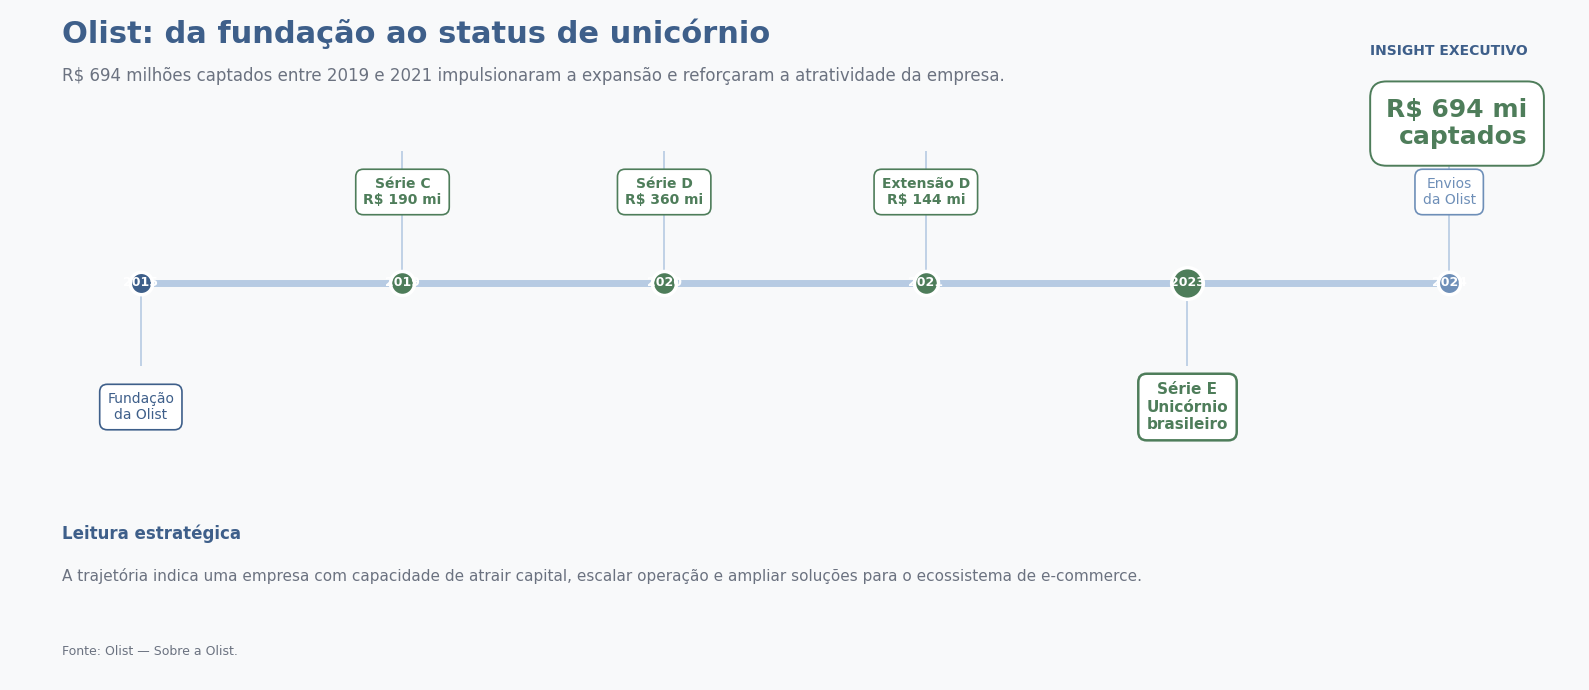

In [117]:
import matplotlib.pyplot as plt

#Paleta 1 – Executiva Corporativa
AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# Dados a partir da fundação da Olist
#criação de dicionário, com 3 informações: ano, titulo e tipo
#tipo para que eventos diferentes tenham aparências diferentes. Classificação
eventos = [
    {"ano": "2015", "titulo": "Fundação\nda Olist", "tipo": "base"},
    {"ano": "2019", "titulo": "Série C\nR$ 190 mi", "tipo": "capital"},
    {"ano": "2020", "titulo": "Série D\nR$ 360 mi", "tipo": "capital"},
    {"ano": "2021", "titulo": "Extensão D\nR$ 144 mi", "tipo": "capital"},
    {"ano": "2023", "titulo": "Série E\nUnicórnio\nbrasileiro", "tipo": "destaque"},
    {"ano": "2024", "titulo": "Envios\nda Olist", "tipo": "expansao"}
]

# Espaçamento visual igual para evitar sobreposição

x = list(range(len(eventos)))
# Conte quantos eventos existem - (len(eventos)
# Crie uma sequência de posições para eles(range(...)
# Transforme essa sequência em uma lista para armazenar na variável x

fig, ax = plt.subplots(figsize=(16, 7), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

# =========================
# 1. TÍTULO EXECUTIVO
# =========================

ax.text(
    -0.3, 2.25,
    "Olist: da fundação ao status de unicórnio",
    fontsize=22,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left"
)

ax.text(
    -0.3, 2.02,
    "R$ 694 milhões captados entre 2019 e 2021 impulsionaram a expansão e reforçaram a atratividade da empresa.",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    ha="left"
)

# =========================
# 2. CARD DE INSIGHT
# =========================

ax.text(
    5.3, 2.18,
    "INSIGHT EXECUTIVO",
    fontsize=10,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="right"
)

ax.text(
    5.3, 1.92,
    "R$ 694 mi\ncaptados",
    fontsize=18,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.65",
        facecolor=BRANCO,
        edgecolor=VERDE_SOFISTICADO,
        linewidth=1.4
    )
)

# =========================
# 3. LINHA PRINCIPAL
# =========================

ax.hlines(
    y=0.8,
    xmin=0,
    xmax=len(eventos) - 1,
    color=AZUL_CLARO,
    linewidth=5,
    zorder=1
)

# =========================
# 4. EVENTOS
# =========================

for i, evento in enumerate(eventos):
    tipo = evento["tipo"]

    if tipo == "base":
        cor = AZUL_EXECUTIVO
        tamanho = 260
        y_card = 0.05
    elif tipo == "capital":
        cor = VERDE_SOFISTICADO
        tamanho = 300
        y_card = 1.35
    elif tipo == "destaque":
        cor = VERDE_SOFISTICADO
        tamanho = 520
        y_card = 0.05
    else:
        cor = AZUL_MEDIO
        tamanho = 260
        y_card = 1.35

    # Ponto
    ax.scatter(
        i,
        0.8,
        s=tamanho,
        color=cor,
        edgecolor=BRANCO,
        linewidth=2.5,
        zorder=3
    )

    # Ano acima do ponto
    ax.text(
        i,
        0.8,
        evento["ano"],
        fontsize=9,
        fontweight="bold",
        color=BRANCO,
        ha="center",
        va="center",
        zorder=4
    )

    # Conector
    ax.vlines(
        i,
        ymin=min(0.8, y_card + 0.25),
        ymax=max(0.8, y_card + 0.25),
        color=AZUL_CLARO,
        linewidth=1.2,
        zorder=1
    )

    # Card do evento
    ax.text(
        i,
        y_card,
        evento["titulo"],
        fontsize=10 if tipo != "destaque" else 11,
        fontweight="bold" if tipo in ["capital", "destaque"] else "normal",
        color=cor,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor=BRANCO,
            edgecolor=cor,
            linewidth=1.2 if tipo != "destaque" else 1.8
        ),
        zorder=5
    )

# =========================
# 5. FAIXA DE INTERPRETAÇÃO
# =========================

ax.text(
    -0.3, -0.75,
    "Leitura estratégica",
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left"
)

ax.text(
    -0.3, -1.00,
    "A trajetória indica uma empresa com capacidade de atrair capital, escalar operação e ampliar soluções para o ecossistema de e-commerce.",
    fontsize=11,
    color=CINZA_EXECUTIVO,
    ha="left"
)

# Fonte
ax.text(
    -0.3, -1.45,
    "Fonte: Olist — Sobre a Olist.",
    fontsize=9,
    color=CINZA_EXECUTIVO,
    ha="left"
)

# =========================
# 6. LIMPEZA VISUAL
# =========================

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-1.6, 2.45)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    "timeline_olist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "timeline_olist.pdf",
    bbox_inches="tight"
)


plt.show()

## 1.3 - Problema de Negócio

A satisfação dos clientes é um dos principais indicadores da experiência de compra em operações de comércio eletrônico. No entanto, diferentes fatores podem influenciar a percepção dos consumidores, incluindo aspectos relacionados à logística de entrega, à experiência vivenciada durante a compra e às características regionais da operação.

Embora a Olist disponha de informações sobre pedidos, entregas, avaliações e localização dos clientes, não é possível identificar apenas pela observação dos dados quais fatores apresentam maior relação com a satisfação observada na plataforma.

Dessa forma, este estudo busca compreender como o prazo de entrega, a percepção da experiência de compra e a região de atendimento se relacionam com as avaliações atribuídas pelos clientes.




## 1.4 - Perguntas Norteadoras

**1. De que forma o prazo de entrega impacta a satisfação dos clientes?**

O prazo de entrega é um dos componentes da experiência de compra em ambientes digitais. Entregas realizadas dentro ou antes do prazo podem contribuir para avaliações mais positivas, enquanto atrasos podem estar associados a níveis mais elevados de insatisfação.

**2. Como os clientes percebem sua experiência de compra no e-commerce?**

A percepção dos clientes pode ser analisada a partir da distribuição das avaliações e da classificação entre promotores, neutros e detratores, permitindo compreender diferentes padrões de satisfação observados na base de dados.

**3. A região de entrega influencia a satisfação dos clientes e a distribuição entre promotores, neutros e detratores?**

Diferenças regionais relacionadas à operação logística e ao atendimento podem influenciar a experiência dos consumidores. A comparação entre regiões permite avaliar se existem variações relevantes nos níveis de satisfação observados.


## 1.5 - Objetivo do Projeto

Este projeto tem como objetivo analisar dados do marketplace Olist para compreender fatores associados à satisfação dos clientes e à experiência de compra observada na plataforma.

A análise será conduzida a partir de informações sobre pedidos, entregas, avaliações e localização dos clientes, buscando investigar a relação entre prazo de entrega, percepção da experiência de compra e diferenças regionais de satisfação.

Os resultados obtidos serão utilizados para responder às perguntas norteadoras definidas para o estudo e compreender como esses fatores se manifestam nos dados disponíveis.



# 2 - Entendimento e Preparação dos Dados

Após a definição do problema de negócio, das perguntas norteadoras e das hipóteses da análise, foi realizada a exploração das bases de dados disponibilizadas pela Olist.

Nesta etapa foram executadas atividades de leitura, organização e padronização dos conjuntos de dados, além da análise dos relacionamentos entre as tabelas que compõem o estudo.

O entendimento da estrutura das bases permitiu identificar a granularidade dos dados, compreender as relações entre as entidades e preparar as informações necessárias para as etapas subsequentes de análise.


### 2.1 - Visão Geral do Dataset

**Objetivo**

Apresentar as bases disponibilizadas pela Olist e identificar as principais informações disponíveis para análise.

**Pergunta**

Quais dados estão disponíveis e como eles podem contribuir para responder às perguntas norteadoras do projeto?






In [118]:
# ============================================================
# Visão Geral do Dataset Olist
# ============================================================
# Objetivo:
# Criar uma tabela executiva com a visão geral das bases
# utilizadas no projeto, apresentando:
# - nome da tabela;
# - descrição em linguagem de negócio;
# - quantidade de linhas;
# - quantidade de colunas;
# - granularidade de cada base.
#
# Resultado esperado:
# Apoiar o entendimento inicial do dataset e documentar
# a estrutura das bases antes das etapas de integração,
# tratamento e análise.
# ============================================================

# ============================================================
# 1. Criação do dicionário com as bases do projeto
# ============================================================

tabelas_dataset = {
    "customers": customers_df,
    "orders": orders_df,
    "order_items": order_items_df,
    "products": products_df,
    "reviews": reviews_df,
    "payments": payments_df,
    "sellers": sellers_df,
    "geolocation": geolocation_df
}

# ============================================================
# 2. Criação da tabela de visão geral
# ============================================================

visao_geral_dataset = pd.DataFrame({
    "tabela": [
        "customers",
        "orders",
        "order_items",
        "products",
        "reviews",
        "payments",
        "sellers",
        "geolocation"
    ],

    "descrição": [
        "Informações dos clientes",
        "Informações dos pedidos",
        "Itens vendidos por pedido",
        "Catálogo de produtos",
        "Avaliações dos clientes",
        "Informações de pagamento",
        "Informações dos vendedores",
        "Coordenadas geográficas por CEP"
    ],

    "linhas": [
        customers_df.shape[0],
        orders_df.shape[0],
        order_items_df.shape[0],
        products_df.shape[0],
        reviews_df.shape[0],
        payments_df.shape[0],
        sellers_df.shape[0],
        geolocation_df.shape[0]
    ],

    "colunas": [
        customers_df.shape[1],
        orders_df.shape[1],
        order_items_df.shape[1],
        products_df.shape[1],
        reviews_df.shape[1],
        payments_df.shape[1],
        sellers_df.shape[1],
        geolocation_df.shape[1]
    ],

    "granularidade": [
        "1 linha = 1 cliente",
        "1 linha = 1 pedido",
        "1 linha = 1 item vendido",
        "1 linha = 1 produto",
        "1 linha = 1 avaliação",
        "1 linha = 1 pagamento",
        "1 linha = 1 vendedor",
        "1 linha = 1 localização por CEP"
    ]
})

# ============================================================
# 3. Formatação dos números no padrão brasileiro
# ============================================================

visao_geral_dataset["linhas"] = (
    visao_geral_dataset["linhas"]
    .apply(lambda x: f"{x:,.0f}".replace(",", "."))
)

visao_geral_dataset["colunas"] = (
    visao_geral_dataset["colunas"]
    .apply(lambda x: f"{x:,.0f}".replace(",", "."))
)

# ============================================================
# 4. Exibição da tabela no padrão visual executivo
# ============================================================

display(
    tabela_executiva(
        visao_geral_dataset
    )
)

tabela,descrição,linhas,colunas,granularidade
customers,Informações dos clientes,99.441,5,1 linha = 1 cliente
orders,Informações dos pedidos,99.441,8,1 linha = 1 pedido
order_items,Itens vendidos por pedido,112.650,7,1 linha = 1 item vendido
products,Catálogo de produtos,32.951,9,1 linha = 1 produto
reviews,Avaliações dos clientes,99.224,7,1 linha = 1 avaliação
payments,Informações de pagamento,103.886,5,1 linha = 1 pagamento
sellers,Informações dos vendedores,3.095,4,1 linha = 1 vendedor
geolocation,Coordenadas geográficas por CEP,1.000.163,5,1 linha = 1 localização por CEP


In [119]:
# 2.1 Tabela resumo do Dataset
# Objetivo: criar uma visão geral das bases utilizadas no projeto,
# mostrando volume, quantidade de colunas, descrição e granularidade.

resumo_bases = pd.DataFrame({
    'Tabela': [
        'customers', 'orders', 'order_items', 'products',
        'reviews', 'payments', 'sellers', 'geolocation'
    ],

    'Linhas': [
        customers_df.shape[0],
        orders_df.shape[0],
        order_items_df.shape[0],
        products_df.shape[0],
        reviews_df.shape[0],
        payments_df.shape[0],
        sellers_df.shape[0],
        geolocation_df.shape[0]
    ],

    'Colunas': [
        customers_df.shape[1],
        orders_df.shape[1],
        order_items_df.shape[1],
        products_df.shape[1],
        reviews_df.shape[1],
        payments_df.shape[1],
        sellers_df.shape[1],
        geolocation_df.shape[1]
    ],

    'Descrição': [
        'Informações dos clientes',
        'Informações dos pedidos',
        'Itens vendidos por pedido',
        'Catálogo de produtos',
        'Avaliações dos clientes',
        'Informações de pagamento',
        'Informações dos vendedores',
        'Coordenadas geográficas por CEP'
    ],

    'Granularidade': [
        '1 linha = 1 cliente',
        '1 linha = 1 pedido',
        '1 linha = 1 item vendido',
        '1 linha = 1 produto',
        '1 linha = 1 avaliação',
        '1 linha = 1 pagamento',
        '1 linha = 1 vendedor',
        '1 linha = 1 localização por CEP'
    ]
})

# Formata a coluna Linhas com separador de milhar no padrão brasileiro
resumo_bases['Linhas'] = resumo_bases['Linhas'].map(lambda x: f'{x:,.0f}'.replace(',', '.'))

# Formata a coluna Colunas como número inteiro
resumo_bases['Colunas'] = resumo_bases['Colunas'].map(lambda x: f'{x:.0f}')

# Aplica estilo visual executivo na tabela
tabela_estilizada = (
    resumo_bases.style
    .hide(axis='index')  # Remove o índice numérico da esquerda
    .set_caption("Estrutura e Volume das Bases do Dataset Olist")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('color', '#3E5F8A'),
                ('text-align', 'left')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#3E5F8A'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('border', '1px solid #FFFFFF')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('background-color', '#F8F9FA'),
                ('color', '#333333'),
                ('border', '1px solid #D9D9D9'),
                ('padding', '8px')
            ]
        }
    ])
    .set_properties(
        subset=['Linhas', 'Colunas'],
        **{'text-align': 'right'}
    )
    .set_properties(
        subset=['Tabela', 'Descrição', 'Granularidade'],
        **{'text-align': 'left'}
    )
)

# Exibe a tabela estilizada
tabela_estilizada

Tabela,Linhas,Colunas,Descrição,Granularidade
customers,99.441,5,Informações dos clientes,1 linha = 1 cliente
orders,99.441,8,Informações dos pedidos,1 linha = 1 pedido
order_items,112.650,7,Itens vendidos por pedido,1 linha = 1 item vendido
products,32.951,9,Catálogo de produtos,1 linha = 1 produto
reviews,99.224,7,Avaliações dos clientes,1 linha = 1 avaliação
payments,103.886,5,Informações de pagamento,1 linha = 1 pagamento
sellers,3.095,4,Informações dos vendedores,1 linha = 1 vendedor
geolocation,1.000.163,5,Coordenadas geográficas por CEP,1 linha = 1 localização por CEP


### Principais Resultados 2.1

Foram identificadas oito tabelas que representam diferentes entidades do negócio da Olist, incluindo clientes, pedidos, produtos, pagamentos, avaliações, vendedores e informações geográficas.

A análise inicial permitiu compreender a estrutura do dataset e a granularidade das bases que serão utilizadas nas etapas subsequentes do projeto.



### 2.2 - Padronização dos Nomes das Tabelas

Estabelecer um padrão único de nomenclatura para todo o projeto.



In [120]:
# 2.2 Padronização dos nomes dos DataFrames

customers = customers_df
orders = orders_df
order_items = order_items_df
products = products_df
reviews = reviews_df
payments = payments_df
sellers = sellers_df
geolocation = geolocation_df

In [121]:
# 2.2 Tabela executiva com a padronização dos DataFrames
# Objetivo: documentar os nomes dos DataFrames utilizados no projeto
# e apresentar sua descrição em linguagem de negócio.

tabela_dataframes = pd.DataFrame({
    'DataFrame': [
        'customers',
        'orders',
        'order_items',
        'products',
        'reviews',
        'payments',
        'sellers',
        'geolocation'
    ],

    'Descrição em português': [
        'Informações dos clientes',
        'Informações dos pedidos',
        'Itens vendidos por pedido',
        'Catálogo de produtos',
        'Avaliações dos clientes',
        'Informações de pagamento',
        'Informações dos vendedores',
        'Coordenadas geográficas por CEP'
    ]
})

# Aplica estilo visual executivo na tabela
tabela_dataframes_estilizada = (
    tabela_dataframes.style
    .hide(axis='index')  # Remove o índice numérico da esquerda
    .set_caption("Padronização dos DataFrames Utilizados no Projeto")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('color', '#3E5F8A'),
                ('text-align', 'left')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#3E5F8A'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('border', '1px solid #FFFFFF')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('background-color', '#F8F9FA'),
                ('color', '#333333'),
                ('border', '1px solid #D9D9D9'),
                ('padding', '8px'),
                ('text-align', 'left')
            ]
        }
    ])
)

# Exibe a tabela estilizada
tabela_dataframes_estilizada

DataFrame,Descrição em português
customers,Informações dos clientes
orders,Informações dos pedidos
order_items,Itens vendidos por pedido
products,Catálogo de produtos
reviews,Avaliações dos clientes
payments,Informações de pagamento
sellers,Informações dos vendedores
geolocation,Coordenadas geográficas por CEP


In [122]:
# ==========================================================
# Criação do dicionário de tabelas
# ==========================================================
# Objetivo:
# Agrupar os DataFrames do projeto em uma única estrutura,
# permitindo percorrer todas as tabelas com um loop.

tabelas = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'reviews': reviews,
    'payments': payments,
    'sellers': sellers,
    'geolocation': geolocation
}

## 2.3 - Relacionamentos e Cardinalidade

Após a identificação das tabelas do dataset, foi realizada a análise dos relacionamentos entre as bases para compreender como as informações estão conectadas.

Essa etapa é importante porque diferentes tabelas possuem níveis distintos de granularidade. Antes de realizar qualquer integração, é necessário entender como clientes, pedidos, produtos, pagamentos, avaliações e vendedores se relacionam para evitar distorções nos resultados.

O conhecimento desses relacionamentos servirá de base para a construção da base analítica utilizada nas etapas seguintes do projeto.



In [123]:
# ============================================================
# 2.3- Análise da Granularidade das Tabelas
# ============================================================
# Objetivo:
# Documentar a granularidade das principais tabelas do dataset
# Olist, indicando o que cada linha representa.
#
# Resultado esperado:
# Criar uma tabela executiva que apoie decisões de integração
# entre as bases e evite duplicidades nas próximas análises.
# ============================================================

granularidade_tabelas = pd.DataFrame({
    "tabela": [
        "customers",
        "orders",
        "order_items",
        "products",
        "reviews",
        "payments",
        "sellers",
        "geolocation"
    ],
    "granularidade": [
        "1 linha = 1 cliente",
        "1 linha = 1 pedido",
        "1 linha = 1 item vendido dentro de um pedido",
        "1 linha = 1 produto",
        "1 linha = 1 avaliação de pedido",
        "1 linha = 1 pagamento associado a um pedido",
        "1 linha = 1 vendedor",
        "1 linha = 1 registro geográfico por CEP"
    ],
    "chave_principal": [
        "customer_id",
        "order_id",
        "order_id + order_item_id",
        "product_id",
        "review_id",
        "order_id + payment_sequential",
        "seller_id",
        "geolocation_zip_code_prefix"
    ],
    "risco_analitico": [
        "Baixo risco de duplicidade",
        "Base central da análise",
        "Pode duplicar pedidos em merges",
        "Baixo risco se integrada por product_id",
        "Pode haver mais de uma avaliação por pedido",
        "Pode haver mais de um pagamento por pedido",
        "Baixo risco se integrada por seller_id",
        "Pode conter múltiplos registros por CEP"
    ]
})

display(
    tabela_executiva(
        granularidade_tabelas
    )
)

tabela,granularidade,chave_principal,risco_analitico
customers,1 linha = 1 cliente,customer_id,Baixo risco de duplicidade
orders,1 linha = 1 pedido,order_id,Base central da análise
order_items,1 linha = 1 item vendido dentro de um pedido,order_id + order_item_id,Pode duplicar pedidos em merges
products,1 linha = 1 produto,product_id,Baixo risco se integrada por product_id
reviews,1 linha = 1 avaliação de pedido,review_id,Pode haver mais de uma avaliação por pedido
payments,1 linha = 1 pagamento associado a um pedido,order_id + payment_sequential,Pode haver mais de um pagamento por pedido
sellers,1 linha = 1 vendedor,seller_id,Baixo risco se integrada por seller_id
geolocation,1 linha = 1 registro geográfico por CEP,geolocation_zip_code_prefix,Pode conter múltiplos registros por CEP


In [124]:
# ==========================================================
# 2.3 Investigação Complementar da Granularidade
# ==========================================================
# Objetivo:
# Investigar tabelas em que a chave analisada inicialmente se repete,
# identificando se existe uma chave alternativa ou composta.
#
# Resultado esperado:
# Exibir uma tabela executiva com a interpretação da granularidade
# das tabelas Avaliações e Itens dos Pedidos.
# ==========================================================

# Cria uma tabela-resumo com a investigação da granularidade
investigacao_granularidade = pd.DataFrame({
    'Tabela': [
        'Avaliações',
        'Itens dos Pedidos'
    ],

    'Chave analisada inicialmente': [
        'order_id',
        'order_id'
    ],

    'Resultado observado': [
        'O order_id pode se repetir, pois um pedido pode possuir mais de uma avaliação',
        'O order_id se repete, pois um pedido pode conter mais de um item'
    ],

    'Chave mais adequada': [
        'review_id',
        'order_id + order_item_id'
    ],

    'Interpretação': [
        'A granularidade da tabela está no nível da avaliação',
        'A granularidade da tabela está no nível do item vendido dentro do pedido'
    ]
})

# Exibe a tabela usando a função executiva padrão do projeto
tabela_executiva(investigacao_granularidade)

Tabela,Chave analisada inicialmente,Resultado observado,Chave mais adequada,Interpretação
Avaliações,order_id,"O order_id pode se repetir, pois um pedido pode possuir mais de uma avaliação",review_id,A granularidade da tabela está no nível da avaliação
Itens dos Pedidos,order_id,"O order_id se repete, pois um pedido pode conter mais de um item",order_id + order_item_id,A granularidade da tabela está no nível do item vendido dentro do pedido


In [125]:
# Verifica se a combinação order_id + order_item_id identifica cada linha da tabela de itens
# Objetivo: confirmar se essa combinação funciona como chave composta da tabela order_items_df
# Resultado esperado: retornar True se cada linha for identificada de forma única pela combinação das duas colunas

chave_composta_itens = (
    order_items_df[['order_id', 'order_item_id']]
    .drop_duplicates()
    .shape[0] == len(order_items_df)
)

# Exibe o resultado da validação da chave composta
chave_composta_itens

True

In [126]:
# Conta a quantidade de pedidos únicos na tabela de itens
# Objetivo: comparar pedidos únicos com a quantidade total de registros da tabela
# Importante: usamos nunique() porque um mesmo pedido pode conter múltiplos itens
# Resultado esperado: retornar o total de pedidos únicos presentes em order_items_df

pedidos_unicos = (
    order_items_df['order_id']
    .nunique()
)

# Exibe o total de pedidos únicos formatado com separador de milhar
print(f'Total de pedidos únicos: {pedidos_unicos:,}')

Total de pedidos únicos: 98,666


In [127]:
# ============================================================
# 2.3 - Relacionamento entre Tabelas
# ============================================================
# Objetivo:
# Mapear os relacionamentos existentes entre as tabelas
# do dataset Olist.
#
# Resultado esperado:
# Documentar as chaves utilizadas nos merges e compreender
# como as informações circulam entre as entidades.
# ============================================================

relacionamentos = pd.DataFrame({

    "tabela_origem": [
        "customers",
        "orders",
        "order_items",
        "order_items",
        "orders",
        "orders"
    ],

    "tabela_destino": [
        "orders",
        "order_items",
        "products",
        "sellers",
        "reviews",
        "payments"
    ],

    "chave_ligacao": [
        "customer_id",
        "order_id",
        "product_id",
        "seller_id",
        "order_id",
        "order_id"
    ],

    "tipo_relacionamento": [
        "1:N",
        "1:N",
        "N:1",
        "N:1",
        "1:1*",
        "1:N"
    ]
})

display(
    tabela_executiva(
        relacionamentos
    )
)

tabela_origem,tabela_destino,chave_ligacao,tipo_relacionamento
customers,orders,customer_id,1:N
orders,order_items,order_id,1:N
order_items,products,product_id,N:1
order_items,sellers,seller_id,N:1
orders,reviews,order_id,1:1*
orders,payments,order_id,1:N


In [128]:
# ==========================================================
# Validação complementar das tabelas que não apresentaram
# chave única na análise inicial de granularidade.
# ==========================================================
print('Linhas:', len(reviews))
print('Reviews únicos:',reviews['review_id'].nunique())
# Verifica possíveis PKs da tabela geolocation

for coluna in geolocation.columns:

    linhas = len(geolocation)
    unicos = geolocation[coluna].nunique()

    print(
        f'{coluna}: '
        f'{unicos} valores únicos '
        f'de {linhas} linhas'
    )

Linhas: 99224
Reviews únicos: 98410
geolocation_zip_code_prefix: 19015 valores únicos de 1000163 linhas
geolocation_lat: 717360 valores únicos de 1000163 linhas
geolocation_lng: 717613 valores únicos de 1000163 linhas
geolocation_city: 8011 valores únicos de 1000163 linhas
geolocation_state: 27 valores únicos de 1000163 linhas


In [129]:
# Verifica se CEP + Latitude + Longitude identifica cada linha

(
    geolocation[
        [
            'geolocation_zip_code_prefix',
            'geolocation_lat',
            'geolocation_lng'
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

720154

In [130]:
# Verifica se a combinação
# order_id + order_item_id
# identifica cada linha

(
    order_items[
        ['order_id', 'order_item_id']
    ]
    .drop_duplicates()
    .shape[0]
    ==
    len(order_items)
)

True

In [131]:
# ==========================================================
# 2.3 - Validação das Chaves de Ligação
# ==========================================================
# Objetivo:
# Verificar se as principais chaves utilizadas nos relacionamentos
# existem nas tabelas de origem e se podem ser usadas nos merges.
#
# Resultado esperado:
# Confirmar se as chaves principais estão presentes nas tabelas
# antes da construção da base analítica.
# ==========================================================

# Cria uma tabela com as principais chaves de relacionamento do projeto
validacao_chaves = pd.DataFrame({
    'Relacionamento': [
        'Pedidos x Clientes',
        'Pedidos x Itens',
        'Itens x Produtos',
        'Itens x Vendedores',
        'Pedidos x Avaliações'
    ],
    'Chave de ligação': [
        'customer_id',
        'order_id',
        'product_id',
        'seller_id',
        'order_id'
    ],
    'Importância analítica': [
        'Permite associar pedidos aos estados e cidades dos clientes',
        'Permite detalhar os produtos vendidos em cada pedido',
        'Permite associar itens vendidos às categorias dos produtos',
        'Permite analisar desempenho dos vendedores',
        'Permite relacionar pedidos às notas de satisfação dos clientes'
    ]
})

# Exibe a tabela no padrão visual executivo do projeto
tabela_executiva(validacao_chaves)

Relacionamento,Chave de ligação,Importância analítica
Pedidos x Clientes,customer_id,Permite associar pedidos aos estados e cidades dos clientes
Pedidos x Itens,order_id,Permite detalhar os produtos vendidos em cada pedido
Itens x Produtos,product_id,Permite associar itens vendidos às categorias dos produtos
Itens x Vendedores,seller_id,Permite analisar desempenho dos vendedores
Pedidos x Avaliações,order_id,Permite relacionar pedidos às notas de satisfação dos clientes


In [132]:
# ============================================================
# 2.3- Síntese das Regras de Integração
# ============================================================

regras_integracao = pd.DataFrame({

    "tabela": [
        "customers",
        "orders",
        "order_items",
        "products",
        "reviews",
        "payments",
        "sellers",
        "geolocation"
    ],

    "granularidade": [
        "1 cliente",
        "1 pedido",
        "1 item vendido",
        "1 produto",
        "1 avaliação",
        "1 pagamento",
        "1 vendedor",
        "1 CEP"
    ],

    "chave_principal": [
        "customer_id",
        "order_id",
        "order_id + order_item_id",
        "product_id",
        "review_id",
        "order_id + payment_sequential",
        "seller_id",
        "geolocation_zip_code_prefix"
    ],

    "risco_principal": [
        "Baixo",
        "Base central",
        "Duplicidade de pedidos",
        "Baixo",
        "Duplicidade de avaliações",
        "Duplicidade de pagamentos",
        "Baixo",
        "Duplicidade por CEP"
    ]
})

display(
    tabela_executiva(
        regras_integracao
    )
)

tabela,granularidade,chave_principal,risco_principal
customers,1 cliente,customer_id,Baixo
orders,1 pedido,order_id,Base central
order_items,1 item vendido,order_id + order_item_id,Duplicidade de pedidos
products,1 produto,product_id,Baixo
reviews,1 avaliação,review_id,Duplicidade de avaliações
payments,1 pagamento,order_id + payment_sequential,Duplicidade de pagamentos
sellers,1 vendedor,seller_id,Baixo
geolocation,1 CEP,geolocation_zip_code_prefix,Duplicidade por CEP


In [133]:
# ============================================================
# 2.3 - Validação da Integridade Referencial
# ============================================================
# Objetivo:
# Validar se as chaves utilizadas nos relacionamentos
# possuem correspondência entre as tabelas.
#
# Resultado esperado:
# Confirmar a consistência dos relacionamentos antes da
# construção da base analítica.
# ============================================================

validacao_integridade = pd.DataFrame({

    "relacionamento": [
        "orders → customers",
        "order_items → orders",
        "order_items → products",
        "order_items → sellers",
        "reviews → orders",
        "payments → orders"
    ],

    "validacao": [

        orders_df["customer_id"].isin(
            customers_df["customer_id"]
        ).all(),

        order_items_df["order_id"].isin(
            orders_df["order_id"]
        ).all(),

        order_items_df["product_id"].isin(
            products_df["product_id"]
        ).all(),

        order_items_df["seller_id"].isin(
            sellers_df["seller_id"]
        ).all(),

        reviews_df["order_id"].isin(
            orders_df["order_id"]
        ).all(),

        payments_df["order_id"].isin(
            orders_df["order_id"]
        ).all()
    ]
})

validacao_integridade["resultado"] = (
    validacao_integridade["validacao"]
    .map({
        True: "✔ Integridade Confirmada",
        False: "⚠ Verificar Relacionamento"
    })
)

display(
    tabela_executiva(
        validacao_integridade[
            ["relacionamento", "resultado"]
        ]
    )
)

relacionamento,resultado
orders → customers,✔ Integridade Confirmada
order_items → orders,✔ Integridade Confirmada
order_items → products,✔ Integridade Confirmada
order_items → sellers,✔ Integridade Confirmada
reviews → orders,✔ Integridade Confirmada
payments → orders,✔ Integridade Confirmada


## Principais Resultados

A análise da granularidade e dos relacionamentos entre as tabelas mostrou que o dataset da Olist possui diferentes níveis de detalhe. Enquanto algumas bases estão no nível de cliente, pedido ou produto, outras podem apresentar múltiplos registros para um mesmo pedido, como ocorre nas tabelas de itens vendidos e pagamentos.

As validações realizadas confirmaram o comportamento esperado das principais tabelas e evidenciaram a existência de situações específicas, como pedidos com mais de uma avaliação registrada. Essas características devem ser consideradas durante as etapas de integração dos dados para evitar duplicidades e interpretações incorretas dos resultados.

Com base nessa análise, a tabela de pedidos foi definida como referência principal para a construção da base analítica utilizada no projeto.


## 2.4 - Representação visual dos relacionamentos

```text
                         clientes
                          │
                          ↓

                       pedidos
                 ┌────────┼────────┐
                 ↓        ↓        ↓

            pagamentos avaliacoes itens_pedido
                                  /      \
                                 ↓        ↓

                            produtos  vendedores
```

# Conclusão da Seção 2

A análise das bases da Olist permitiu compreender a estrutura do dataset, a granularidade das tabelas e os principais relacionamentos entre as entidades utilizadas no estudo.

Também foram identificadas situações que exigem atenção durante a integração dos dados, como tabelas que podem apresentar múltiplos registros para um mesmo pedido. Essas características foram consideradas na definição das regras de preparação e consolidação da base analítica.

Com esse entendimento, foi possível estabelecer os critérios necessários para a integração das informações e preparar os dados que serão utilizados nas análises descritivas e diagnósticas apresentadas nas próximas seções.


# 3 - Engenharia Analítica e Construção das Bases

Após o entendimento da estrutura das tabelas e dos relacionamentos identificados na seção anterior, foi iniciada a etapa de preparação dos dados para análise.

Nesta fase, as informações provenientes das diferentes bases da Olist são integradas em uma única estrutura analítica. O objetivo é reunir dados de pedidos, clientes, produtos, avaliações, pagamentos e localização em uma base consolidada que permita analisar os fatores investigados neste estudo.

Além da integração das tabelas, são realizadas validações e transformações necessárias para a criação de variáveis que serão utilizadas nas análises posteriores. Essas etapas incluem o tratamento dos relacionamentos entre as bases e a preparação de informações relacionadas às entregas, avaliações e características dos pedidos.

O resultado desse processo é a construção da base `base_satisfacao`, que servirá como referência para as análises descritivas e diagnósticas apresentadas nas próximas seções.


### 3.1 - Construção da Base Analítica

Após a análise da estrutura das tabelas, dos relacionamentos e das regras de integração identificadas na seção anterior, foi iniciada a construção da base analítica utilizada neste estudo.

Para isso, foram integradas informações provenientes das diferentes bases da Olist, reunindo dados de pedidos, clientes, produtos, pagamentos, avaliações e localização em uma única estrutura. Durante esse processo, foram respeitadas as granularidades e os relacionamentos previamente validados, buscando preservar a consistência das informações.

O resultado dessa etapa é a criação da `base_satisfacao`, que servirá como base para as análises descritivas e diagnósticas apresentadas nas próximas seções.


In [134]:
# ============================================================
# 3.1 - Integração de Itens dos Pedidos com Produtos
# ============================================================

# Adiciona informações dos produtos à tabela de itens vendidos
# Chave utilizada: product_id

itens_produtos = order_items_df.merge(
    products_df,
    on='product_id',
    how='left'
)

# Verifica quantidade de linhas e colunas após o merge
itens_produtos.shape

(112650, 15)

In [135]:
# ============================================================
# 3.1 - Integração com Pedidos
# ============================================================

# Adiciona informações dos pedidos
# Exemplo:
# status, datas de compra e entrega

itens_produtos_pedidos = itens_produtos.merge(
    orders_df,
    on='order_id',
    how='left'
)

# Verifica a estrutura após o merge
itens_produtos_pedidos.shape

(112650, 22)

In [136]:
# ============================================================
# 3.1- Integração com Avaliações
# ============================================================

# Adiciona a nota de satisfação atribuída pelo cliente

itens_produtos_pedidos_reviews = itens_produtos_pedidos.merge(
    reviews_df,
    on='order_id',
    how='left'
)

# Verifica a estrutura após o merge
itens_produtos_pedidos_reviews.shape

(113314, 28)

In [137]:
# ============================================================
# 3.1- Integração com Clientes
# ============================================================

# Adiciona informações geográficas dos clientes
# Exemplo:
# estado e cidade

base_satisfacao = itens_produtos_pedidos_reviews.merge(
    customers_df,
    on='customer_id',
    how='left'
)

# Verifica a estrutura final da base consolidada
base_satisfacao.shape

(113314, 32)

In [138]:
# ============================================================
# 3.1- Construção da Base Analítica Consolidada
# ============================================================

# 1) Integra itens vendidos com informações dos produtos
itens_produtos = order_items_df.merge(
    products_df,
    on='product_id',
    how='left'
)

# 2) Integra informações dos pedidos
itens_produtos_pedidos = itens_produtos.merge(
    orders_df,
    on='order_id',
    how='left'
)

# 3) Integra avaliações dos clientes
itens_produtos_pedidos_reviews = itens_produtos_pedidos.merge(
    reviews_df,
    on='order_id',
    how='left'
)

# 4) Integra informações dos clientes
base_satisfacao = itens_produtos_pedidos_reviews.merge(
    customers_df,
    on='customer_id',
    how='left'
)

# Exibe o tamanho final da base consolidada
base_satisfacao.shape

(113314, 32)

### 3.2 - Validação da Base Analítica

Após a integração das tabelas, foram realizadas verificações na `base_satisfacao` para confirmar a estrutura da base resultante e identificar possíveis inconsistências decorrentes do processo de consolidação dos dados.

As validações incluem a análise da quantidade de registros, variáveis disponíveis, tipos de dados e outras verificações necessárias para garantir que a base esteja adequada para as etapas seguintes do projeto.




In [139]:
# ============================================================
# 3.2 - Validação da Base Analítica Consolidada
# ============================================================

# Verifica o tamanho da base final
base_satisfacao.shape

(113314, 32)

In [140]:
# Verifica os nomes das colunas, tipos de dados e valores nulos
base_satisfacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113314 non-null  object 
 1   order_item_id                  113314 non-null  int64  
 2   product_id                     113314 non-null  object 
 3   seller_id                      113314 non-null  object 
 4   shipping_limit_date            113314 non-null  object 
 5   price                          113314 non-null  float64
 6   freight_value                  113314 non-null  float64
 7   product_category_name          111702 non-null  object 
 8   product_name_lenght            111702 non-null  float64
 9   product_description_lenght     111702 non-null  float64
 10  product_photos_qty             111702 non-null  float64
 11  product_weight_g               113296 non-null  float64
 12  product_length_cm             

In [141]:
# ============================================================
# Visualização Inicial da Base de Satisfação
# ============================================================
# Objetivo:
# Exibir os 5 primeiros registros da base_satisfacao
# utilizando o padrão visual executivo definido
# na Paleta 1 – Executiva Corporativa.
#
# O código utiliza apenas colunas garantidamente
# existentes na base.
# ============================================================

# Seleciona os 5 primeiros registros da base
amostra_base_satisfacao = (
    base_satisfacao
    .head()
    .copy()
)

# Exibe a tabela utilizando o padrão visual do projeto
display(
    tabela_executiva(
        amostra_base_satisfacao
    )
)

order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.900000,13.290000,cool_stuff,58.000000,598.000000,4.000000,650.000000,28.000000,9.000000,14.000000,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,97ca439bc427b48bc1cd7177abe71365,5.000000,nan,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.900000,19.930000,pet_shop,56.000000,239.000000,2.000000,30000.000000,50.000000,30.000000,40.000000,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,7b07bacd811c4117b742569b04ce3580,4.000000,nan,nan,2017-05-13 00:00:00,2017-05-15 11:34:13,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.000000,17.870000,moveis_decoracao,59.000000,695.000000,2.000000,3050.000000,33.000000,13.000000,33.000000,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,0c5b33dea94867d1ac402749e5438e8b,5.000000,nan,Chegou antes do prazo previsto e o produto surpreendeu pela qualidade. Muito satisfatório.,2018-01-23 00:00:00,2018-01-23 16:06:31,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.990000,12.790000,perfumaria,42.000000,480.000000,1.000000,200.000000,16.000000,10.000000,15.000000,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,f4028d019cb58564807486a6aaf33817,4.000000,nan,nan,2018-08-15 00:00:00,2018-08-15 16:39:01,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.900000,18.140000,ferramentas_jardim,59.000000,409.000000,1.000000,3750.000000,35.000000,40.000000,30.000000,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,940144190dcba6351888cafa43f3a3a5,5.000000,nan,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [142]:
# ==========================================================
# Validação da Granularidade da Base Analítica
# ==========================================================
#
# Objetivo:
# Verificar quantos pedidos únicos existem na base consolidada.
#
# Importante:
# Como a base foi construída em nível de item vendido,
# um mesmo pedido pode aparecer mais de uma vez.
#
# Resultado esperado:
# Retornar a quantidade de pedidos únicos presentes na base.
# ==========================================================

base_satisfacao['order_id'].nunique()

98666

In [143]:
# ============================================================
# Validação de Valores Ausentes
# ============================================================
# Objetivo:
# Verificar a quantidade de valores nulos existentes em cada
# coluna da base_satisfacao após o processo de integração.
#
# Por que esta validação é importante?
# Durante os merges entre tabelas, algumas informações podem
# não possuir correspondência em todas as bases, gerando
# campos sem preenchimento.
#
# Resultado esperado:
# Identificar colunas que possuem valores ausentes e avaliar
# se será necessário algum tratamento antes das análises.
# ============================================================

base_satisfacao.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
product_category_name,1612
product_name_lenght,1612
product_description_lenght,1612


In [144]:
# ============================================================
# Validação de Registros Duplicados
# ============================================================
# Objetivo:
# Verificar se existem linhas completamente duplicadas na
# base_satisfacao após a integração das tabelas.
#
# Por que esta validação é importante?
# Durante os processos de merge, relacionamentos com
# cardinalidade 1:N podem gerar duplicidades indesejadas,
# impactando métricas, agregações e resultados analíticos.
#
# Resultado esperado:
# Confirmar se a base possui registros duplicados e avaliar
# a necessidade de tratamento antes das etapas de análise.
# ============================================================

base_satisfacao.duplicated().sum()

np.int64(0)

### Principais Resultados

A base consolidada foi construída com 113.314 registros, 39 variáveis e 98.666 pedidos únicos. As validações realizadas não identificaram registros totalmente duplicados, indicando que o processo de integração não gerou duplicidades completas na base resultante.

Também foram observados valores ausentes em algumas variáveis. A maior parte desses casos está associada a características já conhecidas do dataset, como comentários de avaliações não preenchidos pelos clientes, informações de produtos ausentes em parte dos registros e pedidos sem confirmação de entrega, o que impacta variáveis derivadas relacionadas ao prazo de entrega.

De forma geral, a estrutura da base mostrou-se adequada para as próximas etapas de preparação e análise dos dados.



### 3.4 - Criação das Variáveis Analíticas

Com a base analítica consolidada, foram criadas variáveis derivadas para apoiar as análises desenvolvidas neste estudo.

Essas variáveis representam aspectos relacionados ao processo de entrega, às características dos pedidos e a outros fatores que não estavam disponíveis diretamente nas bases originais. A criação desses indicadores amplia as possibilidades de análise e facilita a investigação dos fatores associados à satisfação dos clientes.


#### 3.4.1 - Conversão das Datas

As variáveis de data foram convertidas para formatos adequados de processamento e análise.

Essa etapa é necessária para permitir a realização de cálculos temporais e a criação de indicadores relacionados ao processo logístico, como prazo de entrega, atraso e antecipação das entregas. A padronização dos campos também contribui para a consistência das análises realizadas ao longo do projeto.



In [145]:
# ============================================================
# 3.4.1 - Conversão das colunas para datetime
# ============================================================

# Transforma colunas de texto em datas

base_satisfacao['order_purchase_timestamp'] = pd.to_datetime(
    base_satisfacao['order_purchase_timestamp'],
    errors='coerce'
)

base_satisfacao['order_delivered_customer_date'] = pd.to_datetime(
    base_satisfacao['order_delivered_customer_date'],
    errors='coerce'
)

base_satisfacao['order_estimated_delivery_date'] = pd.to_datetime(
    base_satisfacao['order_estimated_delivery_date'],
    errors='coerce'
)

#### 3.4.2 - Criação da Variável `tempo_entrega`

Foi criada a variável `tempo_entrega`, que representa a quantidade de dias decorridos entre a data da compra e a data de entrega do pedido ao cliente.

Essa variável foi calculada a partir da diferença entre os campos `order_purchase_timestamp` e `order_delivered_customer_date`, permitindo mensurar o tempo efetivamente necessário para a conclusão da entrega.

A métrica será utilizada nas análises relacionadas ao desempenho logístico e à experiência dos clientes.



In [146]:
# ============================================================
# 3.4.2 - Tempo de entrega
# ============================================================

# Calcula quantos dias se passaram entre a compra e a entrega

base_satisfacao['tempo_entrega'] = (
    base_satisfacao['order_delivered_customer_date']
    - base_satisfacao['order_purchase_timestamp']
).dt.days

#### 3.4.3 - Criação das Variáveis de Atraso e Antecipação

Foram criadas variáveis relacionadas ao cumprimento dos prazos de entrega com o objetivo de representar diferentes situações observadas no processo logístico.

A variável `dias_atraso` mede a diferença entre a data efetiva de entrega e a data estimada para o pedido. A partir dela, foram derivadas as variáveis `dias_atraso_real`, utilizada para identificar apenas os pedidos entregues após o prazo previsto, e `dias_antecipacao`, utilizada para mensurar as entregas realizadas antes da data estimada.

Essas variáveis serão utilizadas nas análises relacionadas ao desempenho logístico e à sua relação com a satisfação dos clientes.


In [147]:
# ============================================================
# Variáveis de atraso e antecipação
# ============================================================

# Diferença entre entrega real e prazo prometido
base_satisfacao['dias_atraso'] = (
    base_satisfacao['order_delivered_customer_date']
    - base_satisfacao['order_estimated_delivery_date']
).dt.days

# Apenas atrasos
base_satisfacao['dias_atraso_real'] = (
    base_satisfacao['dias_atraso']
    .clip(lower=0)
)

# Apenas antecipações
base_satisfacao['dias_antecipacao'] = (
    base_satisfacao['dias_atraso']
    .clip(upper=0)
    .abs()
)

#### 3.4.4 - Criação da Variável `ano_mes`

Foi criada a variável `ano_mes` a partir da data de compra dos pedidos, com o objetivo de facilitar a organização e a agregação das informações ao longo do tempo.

Essa variável será utilizada em análises temporais, permitindo agrupar os dados por mês e acompanhar a evolução dos indicadores avaliados neste estudo.


In [148]:
# ============================================================
# 3.4.4 - Ano e mês da compra
# ============================================================

# Cria uma coluna para análises temporais

base_satisfacao['ano_mes'] = (
    base_satisfacao['order_purchase_timestamp']
    .dt.to_period('M')
)

#### 3.4.5 - Validação das Variáveis Criadas

Após a criação das variáveis derivadas, foi realizada uma verificação inicial para confirmar se os cálculos foram executados corretamente e se os valores gerados estão compatíveis com a lógica definida durante a preparação dos dados.

Para isso, foi selecionada uma amostra da base contendo as variáveis criadas nesta etapa, permitindo inspecionar os resultados e validar a consistência das transformações realizadas.


In [149]:
# ==========================================================
# 3.4.5 - Validação das Variáveis Criadas
# ==========================================================
# Objetivo:
# Verificar visualmente as variáveis derivadas criadas
# durante a preparação da base analítica.
#
# Resultado esperado:
# Exibir uma amostra das novas variáveis utilizando
# o padrão visual executivo definido no projeto.
# ==========================================================

# Seleciona uma amostra das variáveis derivadas criadas
amostra_variaveis = (
    base_satisfacao[
        [
            'tempo_entrega',
            'dias_atraso',
            'dias_atraso_real',
            'dias_antecipacao',
            'ano_mes'
        ]
    ]
    .head()
)

# Exibe a amostra utilizando o padrão visual executivo
tabela_executiva(amostra_variaveis)

tempo_entrega,dias_atraso,dias_atraso_real,dias_antecipacao,ano_mes
7.000000,-9.000000,0.000000,9.000000,2017-09
16.000000,-3.000000,0.000000,3.000000,2017-04
7.000000,-14.000000,0.000000,14.000000,2018-01
6.000000,-6.000000,0.000000,6.000000,2018-08
25.000000,-16.000000,0.000000,16.000000,2017-02


In [150]:
# ============================================================
# Validação da variável criada 3.4.6
# ============================================================

validacao_tempo_entrega = pd.DataFrame({

    "Indicador": [
        "Total de Registros",
        "Tempo de Entrega Válido",
        "Valores Nulos",
        "Percentual Válido (%)"
    ],

    "Valor": [
        len(base_satisfacao),
        base_satisfacao["tempo_entrega"].notna().sum(),
        base_satisfacao["tempo_entrega"].isna().sum(),
        round(
            (
                base_satisfacao["tempo_entrega"].notna().sum()
                / len(base_satisfacao)
            ) * 100,
            2
        )
    ]
})

display(
    tabela_executiva(
        validacao_tempo_entrega
    )
)

Indicador,Valor
Total de Registros,113314.000000
Tempo de Entrega Válido,110839.000000
Valores Nulos,2475.000000
Percentual Válido (%),97.820000


#### 3.5 - Construção da Base de Drivers de Satisfação

A base `base_satisfacao` foi construída com granularidade no nível de item vendido, o que permite análises detalhadas sobre produtos e pedidos. No entanto, algumas investigações deste estudo exigem uma estrutura no nível do pedido, evitando que pedidos com múltiplos itens tenham peso excessivo nos resultados.

Para atender a esse objetivo, foi construída a `base_driver`, consolidando as informações necessárias para as análises de satisfação com uma linha por pedido. Essa estrutura será utilizada nas análises que investigam a relação entre características da experiência de compra, desempenho logístico e avaliações dos clientes.


In [151]:
# ============================================================
# 3.5 - Construção da Base de Drivers de Satisfação
# Base: base_satisfacao
# Unidade de análise: pedido
# ============================================================

# A base_satisfacao está no nível pedido + item.
# Para análises de satisfação, logística e drivers,
# a unidade correta é o pedido.

base_driver = (
    base_satisfacao
    .drop_duplicates(subset=["order_id"])
    .copy()
)

print("=" * 60)
print("VALIDAÇÃO DA BASE_DRIVER")
print("=" * 60)
print(f"Linhas base_satisfacao : {len(base_satisfacao):,}")
print(f"Linhas base_driver     : {len(base_driver):,}")
print(f"Pedidos únicos base_satisfacao: {base_satisfacao['order_id'].nunique():,}")
print(f"Pedidos únicos base_driver    : {base_driver['order_id'].nunique():,}")
print("=" * 60)

VALIDAÇÃO DA BASE_DRIVER
Linhas base_satisfacao : 113,314
Linhas base_driver     : 98,666
Pedidos únicos base_satisfacao: 98,666
Pedidos únicos base_driver    : 98,666


#### Principais Resultados 3.5

A consolidação dos dados resultou na criação da `base_driver`, estruturada com uma linha por pedido. Essa etapa eliminou a duplicidade associada a pedidos com múltiplos itens e manteve as informações necessárias para as análises de satisfação, logística e experiência de compra.

A nova estrutura preserva a quantidade de pedidos da base original e passa a representar cada pedido como uma única unidade de análise. Essa característica será importante para as investigações apresentadas nas próximas seções do projeto.


# Conclusão da Seção 3

Nesta etapa foram realizadas as integrações necessárias para a construção da base analítica utilizada no estudo, além da criação e validação das variáveis derivadas que serão empregadas nas análises posteriores.

Também foi construída a `base_driver`, estruturada com uma linha por pedido, permitindo a realização de análises no nível adequado para investigar fatores relacionados à satisfação dos clientes.

Com a preparação dos dados concluída, as bases encontram-se organizadas e prontas para apoiar as análises descritivas e diagnósticas apresentadas nas próximas seções do projeto.


# 4 - Análise Exploratória Descritiva

Esta seção apresenta uma visão geral dos dados da Olist por meio de análises exploratórias descritivas, com o objetivo de compreender as principais características da operação do marketplace durante o período analisado.

As análises desenvolvidas nesta etapa buscam responder à seguinte pergunta:

**O que aconteceu no marketplace?**

Para isso, serão explorados aspectos relacionados ao comportamento das vendas, perfil dos clientes, características dos produtos, distribuição geográfica dos pedidos e indicadores gerais da operação.

Os resultados desta seção fornecem o contexto necessário para as análises de desempenho logístico e satisfação dos clientes apresentadas nas etapas seguintes do projeto.


### 4.1 - Perfil Financeiro: Preço e Frete

Antes de analisar o comportamento dos pedidos e da satisfação dos clientes, é importante compreender algumas características financeiras da operação da Olist.

Nesta etapa, são exploradas as distribuições dos preços dos produtos e dos valores de frete registrados no período analisado. A comparação entre essas variáveis permite observar o nível de dispersão das transações realizadas no marketplace e identificar padrões relacionados aos valores praticados na plataforma.

Essa visão inicial contribui para o entendimento do perfil financeiro da operação e fornece contexto para as análises apresentadas nas próximas subseções.




In [152]:
# ============================================================
# 4.1 - Perfil Financeiro: Preço e Frete
# ============================================================
# Objetivo:
# Analisar estatisticamente as variáveis financeiras básicas
# da operação: preço dos produtos e valor do frete.
#
# Variáveis analisadas:
# - price: valor do produto vendido
# - freight_value: valor do frete pago no pedido
#
# Resultado esperado:
# Gerar uma tabela executiva com estatísticas descritivas
# traduzidas para apoiar a compreensão do perfil financeiro
# inicial da operação.
# ============================================================

# ============================================================
# 1. Validação das colunas necessárias
# ============================================================
# Antes de executar a análise, verificamos se as colunas
# obrigatórias existem na base_satisfacao.
# Isso evita erros do tipo KeyError.

colunas_financeiras = ["price", "freight_value"]

for coluna in colunas_financeiras:
    if coluna not in base_satisfacao.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe na base_satisfacao."
        )

# ============================================================
# 2. Criação da tabela de estatísticas descritivas
# ============================================================
# A função describe_pt() deve ter sido criada anteriormente.
# Ela traduz as estatísticas do describe() para português,
# facilitando a leitura executiva da tabela.

estatisticas_financeiras = pd.DataFrame({
    coluna: describe_pt(base_satisfacao[coluna])
    for coluna in colunas_financeiras
})

# ============================================================
# 3. Renomeação das colunas para linguagem executiva
# ============================================================
# Os nomes técnicos das variáveis são convertidos para nomes
# mais compreensíveis no relatório.

estatisticas_financeiras = estatisticas_financeiras.rename(columns={
    "price": "Preço do Produto",
    "freight_value": "Valor do Frete"
})

# ============================================================
# 4. Arredondamento dos valores
# ============================================================
# Mantém duas casas decimais para facilitar a leitura dos
# valores financeiros.

estatisticas_financeiras = estatisticas_financeiras.round(2)

# ============================================================
# 5. Exibição da tabela no padrão visual do projeto
# ============================================================
# A função tabela_executiva() aplica a paleta oficial e mantém
# consistência visual com as demais tabelas do notebook.

display(
    tabela_executiva(
        estatisticas_financeiras.reset_index().rename(
            columns={"index": "Estatística"}
        )
    )
)

Estatística,Preço do Produto,Valor do Frete
quantidade,113314.000000,113314.000000
média,120.480000,19.980000
desvio_padrão,183.280000,15.780000
mínimo,0.850000,0.000000
1_quartil,39.900000,13.080000
mediana,74.900000,16.260000
3_quartil,134.900000,21.150000
máximo,6735.000000,409.680000


### Principais Resultados – Gráfico 4.1

O preço médio dos produtos foi de R\$ 120,48, enquanto o valor médio do frete foi de R\$ 19,98. As medianas observadas foram de R\$ 74,90 para os produtos e R\$ 16,26 para os fretes.

A dispersão dos preços mostrou-se significativamente superior à dos valores de frete. O desvio padrão dos produtos alcançou R\$ 183,28, enquanto o dos fretes foi de R\$ 15,78. Também foram observadas amplitudes elevadas nos preços, que variaram de R\$ 0,85 a R\$ 6.735,00, enquanto os fretes oscilaram entre R\$ 0,00 e R\$ 409,68.

Esses resultados indicam que os produtos comercializados na plataforma apresentam grande diversidade de valores, enquanto os custos de frete tendem a apresentar menor variação ao longo das transações analisadas.

### 4.2 - Distribuição dos Produtos por Faixa de Preço

Nesta etapa, os produtos vendidos foram agrupados em faixas de preço para compreender como os itens se distribuem dentro da base analisada.

A análise permite observar se as vendas estão mais concentradas em produtos de menor valor ou se há participação relevante de faixas mais altas de preço. Essa visão ajuda a caracterizar o perfil das transações realizadas no marketplace e complementa a leitura inicial do perfil financeiro apresentada na seção anterior.


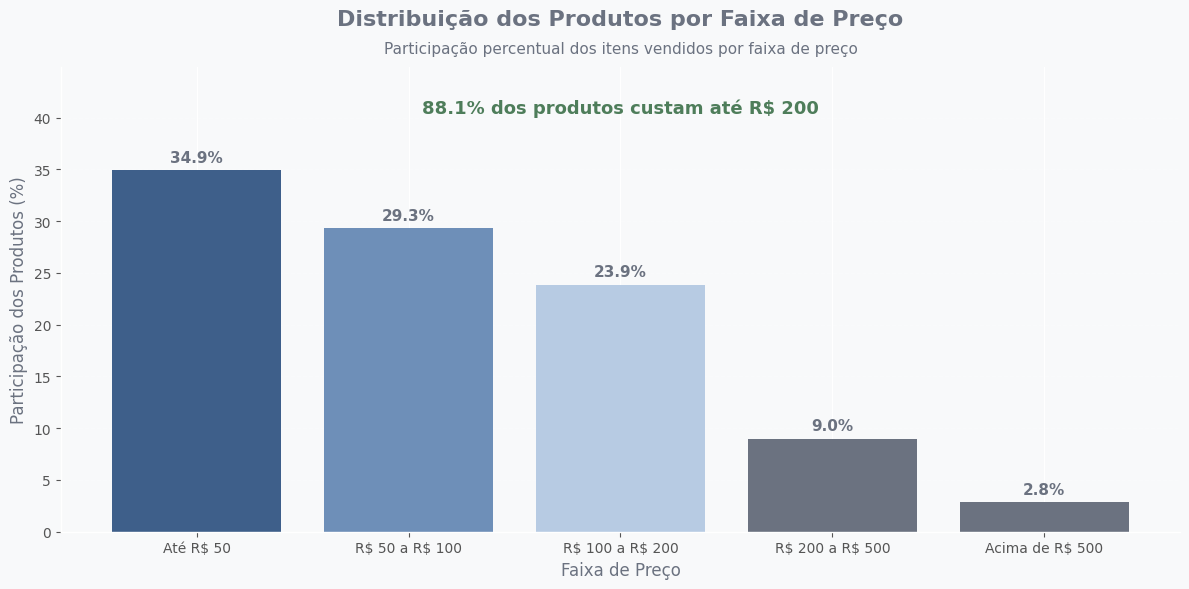

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [153]:
# ============================================================
# 4.2 - Distribuição dos produtos por faixa de preço
# Gráfico executivo com percentuais, insight e download
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Paleta 1 – Executiva Corporativa
AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"

# Cria as faixas de preço dos produtos
base_satisfacao['faixa_preco'] = pd.cut(
    base_satisfacao['price'],
    bins=[0, 50, 100, 200, 500, float('inf')],
    labels=[
        'Até R\$ 50',
        'R\$ 50 a R\$ 100',
        'R\$ 100 a R\$ 200',
        'R\$ 200 a R\$ 500',
        'Acima de R\$ 500'
    ],
    include_lowest=True
)

# Calcula quantidade de itens por faixa
distribuicao_preco = (
    base_satisfacao['faixa_preco']
    .value_counts(sort=False)
    .reset_index()
)

# Renomeia as colunas
distribuicao_preco.columns = ['faixa_preco', 'quantidade']

# Calcula o percentual de itens por faixa
distribuicao_preco['percentual'] = (
    distribuicao_preco['quantidade'] /
    distribuicao_preco['quantidade'].sum() * 100
)

# Calcula o percentual acumulado até R$ 200
percentual_ate_200 = distribuicao_preco.loc[
    distribuicao_preco['faixa_preco'].isin([
        'Até R\$ 50',
        'R\$ 50 a R\$ 100',
        'R\$ 100 a R\$ 200'
    ]),
    'percentual'
].sum()

# Cria figura e eixo
fig, ax = plt.subplots(figsize=(12, 6), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

# Cores com significado:
# Azul para faixas até R$ 200
# Cinza para faixas acima de R$ 200
cores = [
    AZUL_EXECUTIVO,
    AZUL_MEDIO,
    AZUL_CLARO,
    CINZA_EXECUTIVO,
    CINZA_EXECUTIVO
]

# Cria o gráfico de barras
barras = ax.bar(
    distribuicao_preco['faixa_preco'],
    distribuicao_preco['percentual'],
    color=cores
)

# Adiciona os percentuais no topo das barras
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.8,
        f'{altura:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold',
        color=CINZA_EXECUTIVO
    )

# Título principal
ax.set_title(
    'Distribuição dos Produtos por Faixa de Preço',
    fontsize=16,
    fontweight='bold',
    color=CINZA_EXECUTIVO,
    pad=30
)

# Subtítulo
ax.text(
    0.5,
    1.03,
    'Participação percentual dos itens vendidos por faixa de preço',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color=CINZA_EXECUTIVO
)

# Destaque do insight principal
ax.text(
    0.5,
    0.90,
    f'{percentual_ate_200:.1f}% dos produtos custam até R$ 200',
    transform=ax.transAxes,
    ha='center',
    fontsize=13,
    fontweight='bold',
    color=VERDE_SOFISTICADO
)

# Eixos
ax.set_xlabel('Faixa de Preço', fontsize=12, color=CINZA_EXECUTIVO)
ax.set_ylabel('Participação dos Produtos (%)', fontsize=12, color=CINZA_EXECUTIVO)

# Grade leve no eixo Y
ax.grid(axis='y', linestyle='--', alpha=0.25)

# Remove bordas superiores e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajusta limite do eixo Y para dar espaço aos rótulos
ax.set_ylim(0, distribuicao_preco['percentual'].max() + 10)

# Ajusta layout
plt.tight_layout()

# Salva o gráfico como imagem
nome_arquivo = 'grafico_4_2_distribuicao_faixa_preco.png'
plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')

# Exibe o gráfico
plt.show()

# Faz download automático no Google Colab
files.download(nome_arquivo)

### Principais Resultados Gráfico 4.2

A distribuição dos preços mostrou forte concentração nas faixas de menor valor. Aproximadamente 88,1% dos produtos possuem preço inferior a R\$ 200, enquanto apenas 2,8% estão acima de R\$ 500.

Também foi observada uma distribuição assimétrica à direita, caracterizada pela presença de poucos produtos com valores elevados e grande concentração de itens nas faixas de preço mais baixas.

Esse comportamento indica que a maior parte dos produtos comercializados na plataforma está concentrada em categorias de baixo e médio valor.


### 4.3 - Distribuição dos Fretes por Faixa de Valor

Além dos preços dos produtos, os valores de frete representam um componente importante das transações realizadas no marketplace.

Nesta etapa, os fretes são agrupados em faixas de valor para compreender como os custos de entrega se distribuem entre os pedidos e identificar a presença de concentrações ou valores extremos na operação analisada.


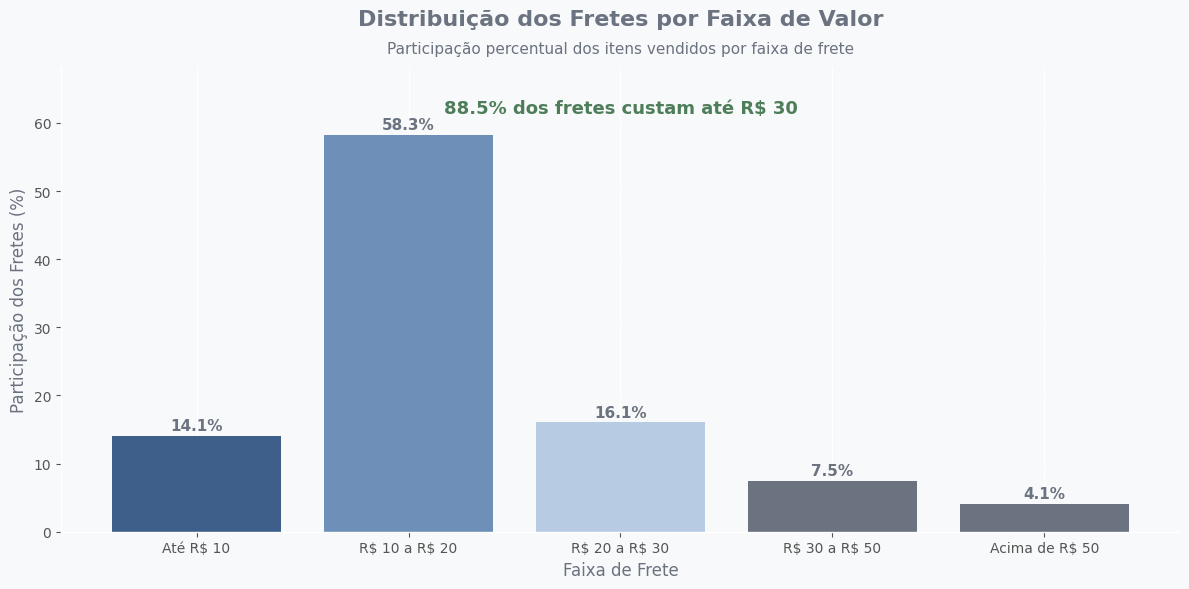

In [154]:
# ============================================================
# 4.3 - Distribuição dos Fretes por Faixa de Valor
# Gráfico executivo com percentuais e download da imagem
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Paleta 1 – Executiva Corporativa
AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"

# ============================================================
# Criação das faixas de frete
# ============================================================

base_satisfacao['faixa_frete'] = pd.cut(
    base_satisfacao['freight_value'],
    bins=[0, 10, 20, 30, 50, float('inf')],
    labels=[
        'Até R\$ 10',
        'R\$ 10 a R\$ 20',
        'R\$ 20 a R\$ 30',
        'R\$ 30 a R\$ 50',
        'Acima de R\$ 50'
    ],
    include_lowest=True
)

# ============================================================
# Quantidade e percentual por faixa
# ============================================================

distribuicao_frete = (
    base_satisfacao['faixa_frete']
    .value_counts(sort=False)
    .reset_index()
)

distribuicao_frete.columns = [
    'faixa_frete',
    'quantidade'
]

distribuicao_frete['percentual'] = (
    distribuicao_frete['quantidade']
    /
    distribuicao_frete['quantidade'].sum()
    * 100
)

# ============================================================
# Percentual acumulado até R$ 30
# ============================================================

percentual_ate_30 = distribuicao_frete.loc[
    distribuicao_frete['faixa_frete'].isin([
        'Até R\$ 10',
        'R\$ 10 a R\$ 20',
        'R\$ 20 a R\$ 30'
    ]),
    'percentual'
].sum()

# ============================================================
# Criação do gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6),
    facecolor=FUNDO_CLARO
)

ax.set_facecolor(FUNDO_CLARO)

# Cores
cores = [
    AZUL_EXECUTIVO,
    AZUL_MEDIO,
    AZUL_CLARO,
    CINZA_EXECUTIVO,
    CINZA_EXECUTIVO
]

barras = ax.bar(
    distribuicao_frete['faixa_frete'],
    distribuicao_frete['percentual'],
    color=cores
)

# ============================================================
# Percentuais nas barras
# ============================================================

for barra in barras:

    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.8,
        f'{altura:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold',
        color=CINZA_EXECUTIVO
    )

# ============================================================
# Título
# ============================================================

ax.set_title(
    'Distribuição dos Fretes por Faixa de Valor',
    fontsize=16,
    fontweight='bold',
    color=CINZA_EXECUTIVO,
    pad=30
)

# Subtítulo

ax.text(
    0.5,
    1.03,
    'Participação percentual dos itens vendidos por faixa de frete',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color=CINZA_EXECUTIVO
)

# ============================================================
# Insight principal
# ============================================================

ax.text(
    0.5,
    0.90,
    f'{percentual_ate_30:.1f}% dos fretes custam até R$ 30',
    transform=ax.transAxes,
    ha='center',
    fontsize=13,
    fontweight='bold',
    color=VERDE_SOFISTICADO
)

# ============================================================
# Eixos
# ============================================================

ax.set_xlabel(
    'Faixa de Frete',
    fontsize=12,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel(
    'Participação dos Fretes (%)',
    fontsize=12,
    color=CINZA_EXECUTIVO
)

# ============================================================
# Aparência
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(
    0,
    distribuicao_frete['percentual'].max() + 10
)

plt.tight_layout()

# ============================================================
# Salvar imagem
# ============================================================

nome_arquivo = 'grafico_4_3_distribuicao_fretes.png'

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches='tight'
)

plt.show()



### Principais Resultados Gráfico 4.3

Os valores de frete apresentaram maior concentração nas faixas mais baixas da distribuição, enquanto os fretes mais elevados representaram uma parcela reduzida dos pedidos analisados.

Assim como observado nos preços dos produtos, a distribuição apresentou assimetria positiva, com poucos casos concentrados nas faixas superiores de valor. No entanto, a dispersão dos fretes mostrou-se menor do que a observada para os preços dos produtos.

Esses resultados indicam que a maior parte dos pedidos está associada a custos de entrega relativamente baixos, embora existam ocorrências pontuais de fretes significativamente mais elevados.


### 4.4 - Perfil dos Pedidos: Quantidade de Itens por Pedido

Nesta etapa foi analisada a quantidade de itens adquiridos em cada pedido, com o objetivo de compreender o padrão de compra observado na plataforma.

A distribuição dos itens por pedido permite identificar se os clientes costumam realizar compras com poucos produtos ou se existe participação relevante de pedidos compostos por múltiplos itens.


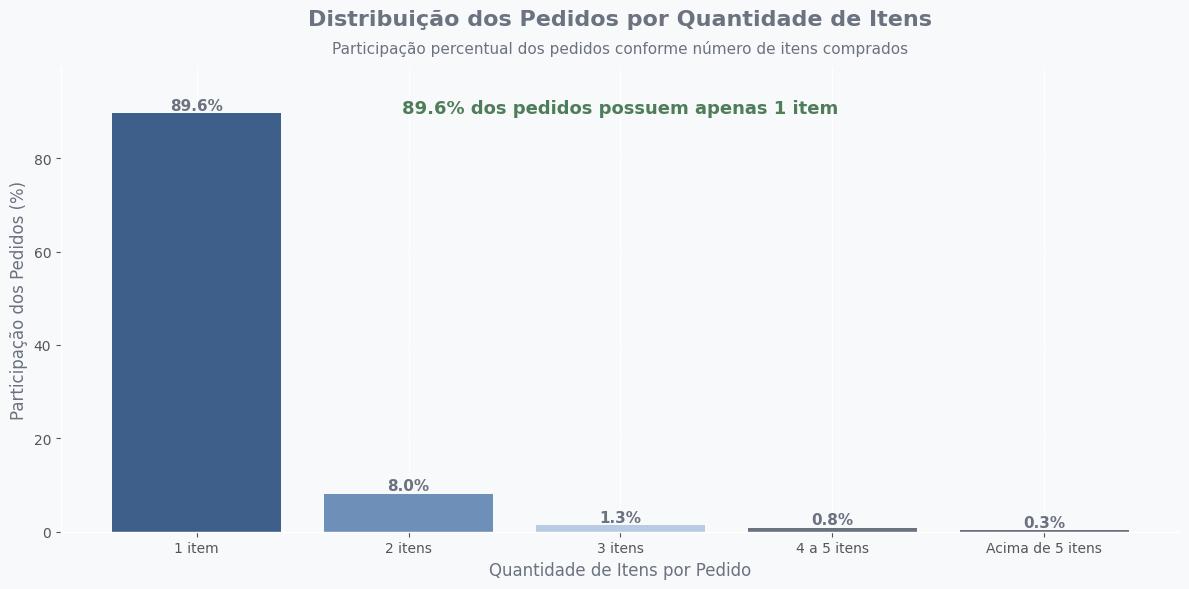

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [155]:
# ============================================================
# 4.4 - Perfil dos Pedidos: Quantidade de Itens por Pedido
# Gráfico executivo com percentuais e download da imagem
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Paleta 1 – Executiva Corporativa
AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"

# Conta quantos itens existem em cada pedido
itens_por_pedido = (
    base_satisfacao
    .groupby('order_id')['order_item_id']
    .count()
    .reset_index()
)

# Renomeia as colunas
itens_por_pedido.columns = ['order_id', 'quantidade_itens']

# Cria faixas de quantidade de itens por pedido
itens_por_pedido['faixa_itens'] = pd.cut(
    itens_por_pedido['quantidade_itens'],
    bins=[0, 1, 2, 3, 5, float('inf')],
    labels=[
        '1 item',
        '2 itens',
        '3 itens',
        '4 a 5 itens',
        'Acima de 5 itens'
    ],
    include_lowest=True
)

# Calcula quantidade e percentual por faixa
distribuicao_itens = (
    itens_por_pedido['faixa_itens']
    .value_counts(sort=False)
    .reset_index()
)

distribuicao_itens.columns = ['faixa_itens', 'quantidade']

distribuicao_itens['percentual'] = (
    distribuicao_itens['quantidade'] /
    distribuicao_itens['quantidade'].sum() * 100
)

# Percentual de pedidos com apenas 1 item
percentual_1_item = distribuicao_itens.loc[
    distribuicao_itens['faixa_itens'] == '1 item',
    'percentual'
].values[0]

# Cria o gráfico
fig, ax = plt.subplots(figsize=(12, 6), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    AZUL_EXECUTIVO,
    AZUL_MEDIO,
    AZUL_CLARO,
    CINZA_EXECUTIVO,
    CINZA_EXECUTIVO
]

barras = ax.bar(
    distribuicao_itens['faixa_itens'],
    distribuicao_itens['percentual'],
    color=cores
)

# Adiciona percentual nas barras
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.8,
        f'{altura:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold',
        color=CINZA_EXECUTIVO
    )

# Título
ax.set_title(
    'Distribuição dos Pedidos por Quantidade de Itens',
    fontsize=16,
    fontweight='bold',
    color=CINZA_EXECUTIVO,
    pad=30
)

# Subtítulo
ax.text(
    0.5,
    1.03,
    'Participação percentual dos pedidos conforme número de itens comprados',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color=CINZA_EXECUTIVO
)

# Insight principal
ax.text(
    0.5,
    0.90,
    f'{percentual_1_item:.1f}% dos pedidos possuem apenas 1 item',
    transform=ax.transAxes,
    ha='center',
    fontsize=13,
    fontweight='bold',
    color=VERDE_SOFISTICADO
)

# Eixos
ax.set_xlabel('Quantidade de Itens por Pedido', fontsize=12, color=CINZA_EXECUTIVO)
ax.set_ylabel('Participação dos Pedidos (%)', fontsize=12, color=CINZA_EXECUTIVO)

# Aparência
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, distribuicao_itens['percentual'].max() + 10)

plt.tight_layout()

# Salva e baixa imagem
nome_arquivo = 'grafico_4_4_itens_por_pedido.png'
plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
plt.show()

files.download(nome_arquivo)

### Principais Resultados Gráfico 4.4

A maior parte dos pedidos é composta por apenas um item, enquanto pedidos com dois ou mais produtos representam uma parcela menor da operação.

A distribuição apresenta forte concentração nos menores volumes de itens por pedido, indicando que compras com muitos produtos ocorrem com menor frequência na base analisada.

Esses resultados mostram que o padrão predominante da plataforma está associado a pedidos com poucos itens por transação.


### 4.5 - Distribuição dos Clientes por Estado

A distribuição geográfica dos clientes permite compreender como a demanda está distribuída entre os estados brasileiros e identificar as regiões com maior participação na base analisada.

Essa análise fornece uma visão inicial da concentração geográfica dos clientes da plataforma e contribui para o entendimento da abrangência da operação da Olist.


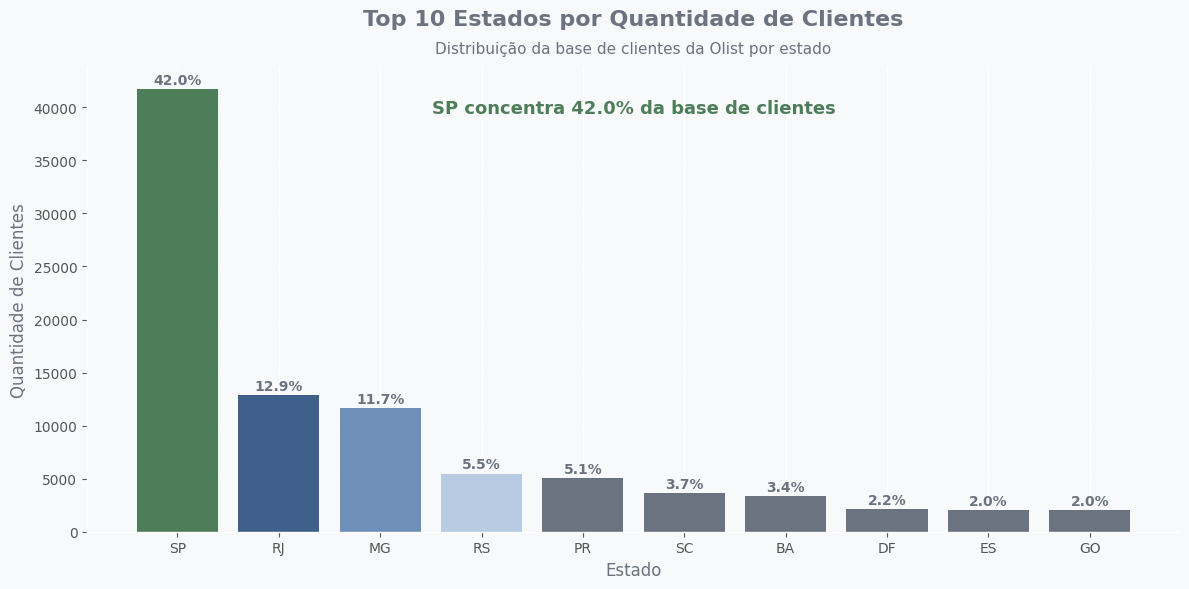

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [156]:
# ============================================================
# 4.5 - Distribuição dos Clientes por Estado
# Gráfico executivo com percentuais e download da imagem
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Paleta 1 – Executiva Corporativa
AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"

# Conta clientes por estado e pega os 10 maiores
clientes_estado = (
    customers_df['customer_state']
    .value_counts()
    .head(10)
    .reset_index()
)

# Renomeia as colunas
clientes_estado.columns = ['estado', 'quantidade_clientes']

# Calcula o percentual sobre a base total de clientes
clientes_estado['percentual'] = (
    clientes_estado['quantidade_clientes'] / customers_df.shape[0] * 100
)

# Identifica o estado líder
estado_lider = clientes_estado.iloc[0]['estado']
percentual_lider = clientes_estado.iloc[0]['percentual']

# Cores dinâmicas: verde para o líder, depois escala de azul e cinza
cores = []

for i in range(len(clientes_estado)):
    if i == 0:
        cores.append(VERDE_SOFISTICADO)
    elif i == 1:
        cores.append(AZUL_EXECUTIVO)
    elif i == 2:
        cores.append(AZUL_MEDIO)
    elif i == 3:
        cores.append(AZUL_CLARO)
    else:
        cores.append(CINZA_EXECUTIVO)

# Cria o gráfico
fig, ax = plt.subplots(figsize=(12, 6), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

barras = ax.bar(
    clientes_estado['estado'],
    clientes_estado['quantidade_clientes'],
    color=cores
)

# Adiciona os percentuais acima das barras
for i, barra in enumerate(barras):
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 500,
        f"{clientes_estado.iloc[i]['percentual']:.1f}%",
        ha='center',
        fontsize=10,
        fontweight='bold',
        color=CINZA_EXECUTIVO
    )

# Título
ax.set_title(
    'Top 10 Estados por Quantidade de Clientes',
    fontsize=16,
    fontweight='bold',
    color=CINZA_EXECUTIVO,
    pad=30
)

# Subtítulo
ax.text(
    0.5,
    1.03,
    'Distribuição da base de clientes da Olist por estado',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color=CINZA_EXECUTIVO
)

# Insight principal
ax.text(
    0.5,
    0.90,
    f'{estado_lider} concentra {percentual_lider:.1f}% da base de clientes',
    transform=ax.transAxes,
    ha='center',
    fontsize=13,
    fontweight='bold',
    color=VERDE_SOFISTICADO
)

# Eixos
ax.set_xlabel('Estado', fontsize=12, color=CINZA_EXECUTIVO)
ax.set_ylabel('Quantidade de Clientes', fontsize=12, color=CINZA_EXECUTIVO)

# Aparência
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Salva imagem
nome_arquivo = 'grafico_4_5_clientes_estado.png'
plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')

# Exibe o gráfico
plt.show()

# Download automático
files.download(nome_arquivo)

### Principais Resultados Gráfico 4.5

São Paulo concentra aproximadamente 42% da base de clientes da Olist, seguido por Rio de Janeiro e Minas Gerais. Em conjunto, os estados da região Sudeste representam a maior parcela dos clientes presentes no dataset.

As regiões Norte e parte do Nordeste apresentam participação menor quando comparadas aos estados mais populosos do país.

Os resultados evidenciam uma concentração relevante da base de clientes na região Sudeste, especialmente no estado de São Paulo.


### 4.6 - Evolução Mensal dos Pedidos

A análise da evolução mensal dos pedidos permite observar como o volume de compras se comporta ao longo do período analisado.

Ao acompanhar a quantidade de pedidos registrados em cada mês, torna-se possível identificar padrões temporais, períodos de maior ou menor atividade e mudanças no comportamento da operação ao longo do tempo.

Essa visão complementa as análises anteriores e contribui para a compreensão da dinâmica do marketplace durante o período coberto pelo dataset.


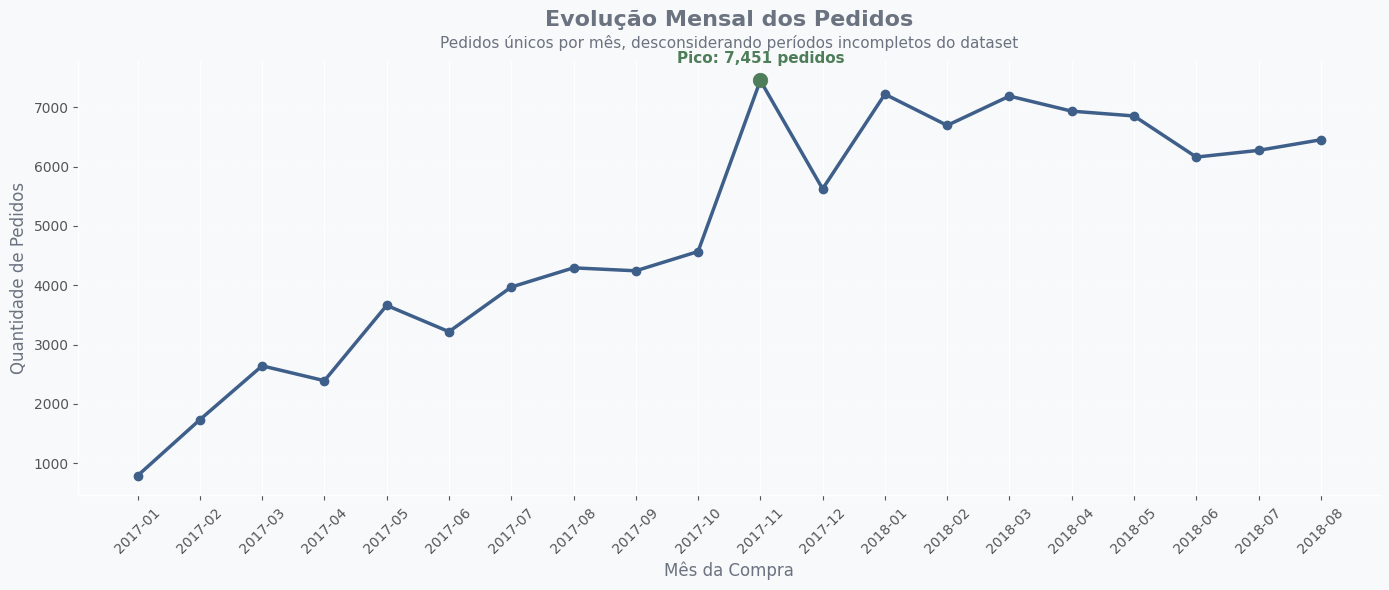

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [157]:
# ============================================================
# 4.6 - Evolução Mensal dos Pedidos
# Gráfico executivo de linha com download da imagem
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Paleta 1 – Executiva Corporativa
AZUL_EXECUTIVO = "#3E5F8A"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"

# Converte a coluna de data da compra para datetime
base_satisfacao['order_purchase_timestamp'] = pd.to_datetime(
    base_satisfacao['order_purchase_timestamp'],
    errors='coerce'
)

# Cria a coluna ano_mes no formato texto
base_satisfacao['ano_mes'] = (
    base_satisfacao['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

# Conta pedidos únicos por mês
pedidos_mes = (
    base_satisfacao
    .groupby('ano_mes')['order_id']
    .nunique()
    .reset_index()
)

pedidos_mes.columns = ['ano_mes', 'quantidade_pedidos']

# Remove meses incompletos ou pouco representativos
pedidos_mes = pedidos_mes[
    (pedidos_mes['ano_mes'] >= '2017-01') &
    (pedidos_mes['ano_mes'] <= '2018-08')
]

# Identifica o mês com maior volume de pedidos
mes_pico = pedidos_mes.loc[
    pedidos_mes['quantidade_pedidos'].idxmax(),
    'ano_mes'
]

qtd_pico = pedidos_mes['quantidade_pedidos'].max()

# Cria o gráfico
fig, ax = plt.subplots(figsize=(14, 6), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

ax.plot(
    pedidos_mes['ano_mes'],
    pedidos_mes['quantidade_pedidos'],
    marker='o',
    linewidth=2.5,
    color=AZUL_EXECUTIVO
)

# Destaca o mês de pico
ax.scatter(
    mes_pico,
    qtd_pico,
    color=VERDE_SOFISTICADO,
    s=110,
    zorder=5
)

# Texto do pico
ax.text(
    mes_pico,
    qtd_pico + 300,
    f'Pico: {qtd_pico:,} pedidos',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color=VERDE_SOFISTICADO
)

# Título
ax.set_title(
    'Evolução Mensal dos Pedidos',
    fontsize=16,
    fontweight='bold',
    color=CINZA_EXECUTIVO,
    pad=25
)

# Subtítulo
ax.text(
    0.5,
    1.03,
    'Pedidos únicos por mês, desconsiderando períodos incompletos do dataset',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color=CINZA_EXECUTIVO
)

# Eixos
ax.set_xlabel('Mês da Compra', fontsize=12, color=CINZA_EXECUTIVO)
ax.set_ylabel('Quantidade de Pedidos', fontsize=12, color=CINZA_EXECUTIVO)

# Aparência
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()

# Salva imagem
nome_arquivo = 'grafico_4_6_evolucao_mensal_pedidos.png'
plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')

plt.show()

# Download automático
files.download(nome_arquivo)

### Conclusão do Gráfico 4.6

A evolução mensal dos pedidos mostrou aumento do volume transacionado ao longo do período analisado. Esse comportamento indica crescimento da atividade observada na plataforma e fornece evidências de expansão operacional durante os anos cobertos pelo dataset.

A análise, entretanto, não permite concluir isoladamente quais fatores contribuíram para esse crescimento, tornando necessária a investigação de aspectos operacionais e de experiência do cliente nas próximas etapas do estudo.
 a expansão da operação não comprometa a qualidade dos serviços prestados.

# Conclusão da Seção 4 – Análise Descritiva do Marketplace

As análises desta seção permitiram caracterizar o comportamento geral da operação da Olist sob diferentes perspectivas, incluindo preços dos produtos, valores de frete, perfil dos pedidos, distribuição geográfica dos clientes e evolução do volume de pedidos ao longo do tempo.

Os resultados mostraram predominância de produtos concentrados nas faixas de menor valor, pedidos compostos principalmente por um único item e forte concentração de clientes nos estados da região Sudeste, especialmente em São Paulo.

Também foi observado crescimento do volume mensal de pedidos durante o período analisado, indicando expansão da atividade registrada na plataforma entre 2016 e 2018.

De forma geral, esta etapa forneceu uma visão inicial da estrutura e do comportamento do marketplace, estabelecendo o contexto necessário para as análises das próximas seções. A partir desse entendimento, o estudo passa a investigar aspectos relacionados ao desempenho logístico e à experiência dos clientes, buscando compreender fatores que podem influenciar a satisfação observada nas avaliações.


# 5 - Análise Operacional e Logística

Esta seção examina o comportamento dos principais indicadores logísticos da Olist, com foco nos prazos de entrega e no cumprimento das datas prometidas aos clientes.

As análises desenvolvidas nesta etapa buscam responder à seguinte pergunta:

**Como a operação logística se comportou durante o período analisado?**

Para isso, serão avaliados indicadores relacionados ao tempo de entrega, antecipações, atrasos e variações observadas nos prazos dos pedidos.

A compreensão desses aspectos é importante para contextualizar as análises de satisfação apresentadas nas próximas seções, uma vez que a experiência de entrega representa uma etapa relevante da jornada de compra no comércio eletrônico.


### 5.1 - Estatísticas Descritivas do Tempo de Entrega

A análise logística inicia pela compreensão do comportamento geral dos prazos de entrega observados na operação da Olist. Antes de investigar possíveis impactos sobre a satisfação dos clientes, é necessário identificar qual é o prazo típico das entregas e avaliar o nível de dispersão existente na operação.

As estatísticas descritivas permitem estabelecer uma visão inicial do desempenho logístico, evidenciando valores centrais, amplitude e possíveis diferenças entre o comportamento médio e os casos extremos. Essa etapa fornece a base necessária para as análises subsequentes, que aprofundam a distribuição dos prazos e a identificação de situações fora do padrão operacional.


In [158]:
# ============================================================
# Criação da variável tempo_entrega
# ============================================================
# Objetivo:
# Criar a coluna tempo_entrega, que representa a quantidade
# de dias entre a compra e a entrega efetiva do pedido.
# ============================================================

# Converte as colunas de data para formato datetime
base_satisfacao["order_purchase_timestamp"] = pd.to_datetime(
    base_satisfacao["order_purchase_timestamp"],
    errors="coerce"
)

base_satisfacao["order_delivered_customer_date"] = pd.to_datetime(
    base_satisfacao["order_delivered_customer_date"],
    errors="coerce"
)

# Calcula o tempo de entrega em dias
base_satisfacao["tempo_entrega"] = (
    base_satisfacao["order_delivered_customer_date"]
    - base_satisfacao["order_purchase_timestamp"]
).dt.days

# Validação rápida da coluna criada
base_satisfacao[["order_id", "order_purchase_timestamp", "order_delivered_customer_date", "tempo_entrega"]].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,tempo_entrega
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,2017-09-20 23:43:48,7.00
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-12 16:04:24,16.00
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-01-22 13:19:16,7.00
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,2018-08-14 13:32:39,6.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,2017-03-01 16:42:31,25.00


In [159]:
estatisticas_tempo_entrega = pd.DataFrame(
    describe_pt(
        base_satisfacao["tempo_entrega"]
    )
)

display(
    tabela_executiva(
        estatisticas_tempo_entrega.reset_index()
    )
)

index,tempo_entrega
quantidade,110839.000000
média,12.012414
desvio_padrão,9.445470
mínimo,0.000000
1_quartil,6.000000
mediana,10.000000
3_quartil,15.000000
máximo,209.000000


### Principais Resultados Gráfico 5.1

- Foram identificadas 110.839 entregas com informação válida de tempo de entrega.
- O tempo médio de entrega foi de 12 dias.
- A mediana foi de 10 dias, indicando que m**etade dos pedidos foi entregue em até 10 dias.**
- **75% das entregas ocorreram em até 15 dias.**
- O maior tempo de entrega identificado foi de 209 dias.

### Insight Executivo

A análise indica que o prazo típico de entrega da Olist é relativamente concentrado: **metade dos pedidos foi entregue em até 10 dias e 75% em até 15 dias. Isso sugere um desempenho logístico consistente para a maior parte da operação.**

Entretanto, **a diferença entre o prazo típico e o valor máximo de 209 dias indica a presença de casos excepcionais muito acima do padrão**. Esses casos **não representam o comportamento geral da operação,** mas podem gerar impactos negativos relevantes na experiência do cliente.

### Recomendação

**Utilizar a mediana e os quartis como principais referências para interpretar o prazo típico de entrega,** evitando depender apenas da média. Prosseguir com a análise da distribuição dos tempos de entrega para compreender melhor a variabilidade dos prazos observados na operação.

### 5.2 - Distribuição do Tempo de Entrega por Faixa

Embora as medidas-resumo forneçam uma visão geral da operação, elas não permitem compreender como os pedidos estão distribuídos entre diferentes intervalos de prazo. Para complementar essa análise, é importante observar a concentração das entregas ao longo das faixas de tempo identificadas na base.

A distribuição dos prazos permite avaliar a previsibilidade da operação logística e identificar os intervalos mais frequentes de entrega. Essa abordagem facilita a compreensão do comportamento predominante da operação, evidenciando se os pedidos estão concentrados em faixas compatíveis com uma experiência de compra satisfatória ou se existe dispersão significativa entre os diferentes prazos observados.



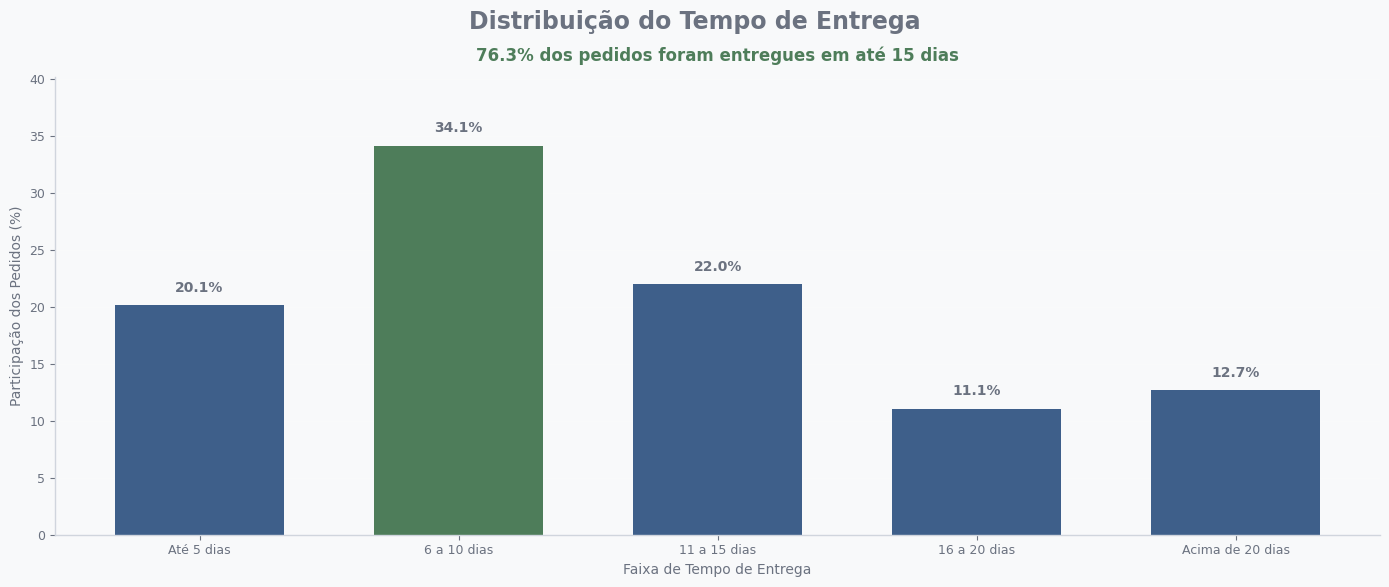

Faixa de Tempo de Entrega,Percentual
Até 5 dias,"20,1%"
6 a 10 dias,"34,1%"
11 a 15 dias,"22,0%"
16 a 20 dias,"11,1%"
Acima de 20 dias,"12,7%"


In [160]:
# ============================================================
# 5.2 - Distribuição do Tempo de Entrega
# Versão executiva revisada
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Preparação da base
# ============================================================

tempo_entrega = (
    base_satisfacao["tempo_entrega"]
    .dropna()
    .copy()
)

# ============================================================
# 2. Criação das faixas de tempo de entrega
# ============================================================

faixas = [0, 5, 10, 15, 20, float("inf")]

rotulos = [
    "Até 5 dias",
    "6 a 10 dias",
    "11 a 15 dias",
    "16 a 20 dias",
    "Acima de 20 dias"
]

base_faixas_entrega = pd.DataFrame({
    "tempo_entrega": tempo_entrega
})

base_faixas_entrega["faixa_tempo_entrega"] = pd.cut(
    base_faixas_entrega["tempo_entrega"],
    bins=faixas,
    labels=rotulos,
    right=True,
    include_lowest=True
)

# ============================================================
# 3. Cálculo da distribuição percentual
# ============================================================

distribuicao_entrega = (
    base_faixas_entrega["faixa_tempo_entrega"]
    .value_counts(normalize=True)
    .reindex(rotulos)
    .reset_index()
)

distribuicao_entrega.columns = [
    "Faixa de Tempo de Entrega",
    "Percentual"
]

distribuicao_entrega["Percentual"] = (
    distribuicao_entrega["Percentual"] * 100
)

pct_ate_15 = (
    distribuicao_entrega.loc[
        distribuicao_entrega["Faixa de Tempo de Entrega"].isin(
            ["Até 5 dias", "6 a 10 dias", "11 a 15 dias"]
        ),
        "Percentual"
    ]
    .sum()
)

faixa_maior = distribuicao_entrega.loc[
    distribuicao_entrega["Percentual"].idxmax()
]

# ============================================================
# 4. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO
    if faixa == faixa_maior["Faixa de Tempo de Entrega"]
    else AZUL_EXECUTIVO
    for faixa in distribuicao_entrega["Faixa de Tempo de Entrega"]
]

barras = ax.bar(
    distribuicao_entrega["Faixa de Tempo de Entrega"],
    distribuicao_entrega["Percentual"],
    color=cores,
    width=0.65
)

# ============================================================
# 5. Título e subtítulo
# ============================================================

fig.suptitle(
    "Distribuição do Tempo de Entrega",
    fontsize=17,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    f"{pct_ate_15:.1f}% dos pedidos foram entregues em até 15 dias",
    fontsize=12,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    pad=12
)

# ============================================================
# 6. Rótulos das barras
# ============================================================

for barra, percentual in zip(
    barras,
    distribuicao_entrega["Percentual"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.9,
        f"{percentual:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

# ============================================================
# 7. Eixos e acabamento visual
# ============================================================

ax.set_xlabel(
    "Faixa de Tempo de Entrega",
    fontsize=10,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel(
    "Participação dos Pedidos (%)",
    fontsize=10,
    color=CINZA_EXECUTIVO
)

ax.set_ylim(
    0,
    distribuicao_entrega["Percentual"].max() + 6
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="x", colors=CINZA_EXECUTIVO, labelsize=9)
ax.tick_params(axis="y", colors=CINZA_EXECUTIVO, labelsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# 8. Tabela executiva de apoio
# ============================================================

tabela_distribuicao_entrega = distribuicao_entrega.copy()

tabela_distribuicao_entrega["Percentual"] = (
    tabela_distribuicao_entrega["Percentual"]
    .round(1)
    .astype(str)
    .str.replace(".", ",", regex=False)
    + "%"
)

display(
    tabela_executiva(
        tabela_distribuicao_entrega
    )
)

### Principais Resultados Gráfico 5.2

- A maior concentração de pedidos ocorreu nas faixas de entrega mais curtas.
- Os volumes diminuem gradualmente à medida que o prazo de entrega aumenta.
- A maior parte da operação está concentrada em intervalos compatíveis com a mediana observada na análise anterior.
- Entregas muito longas representam uma parcela reduzida da operação.

### Insight Executivo

A distribuição dos tempos de entrega demonstra que a operação logística da Olist apresenta **comportamento relativamente previsível** para a maioria dos pedidos. A concentração das entregas em faixas mais curtas sugere capacidade de atender grande parte dos clientes dentro de **prazos competitivos**, contribuindo para uma experiência de compra mais consistente.

### Recomendação

Utilizar a distribuição dos prazos como referência para monitoramento operacional, **acompanhando possíveis deslocamentos da concentração das entregas para faixas mais longas ao longo do tempo**. Alterações nesse comportamento podem indicar degradação da eficiência logística e impactar a satisfação dos clientes.

### 5.3 - Boxplot do Tempo de Entrega

Após analisar as estatísticas descritivas e a distribuição dos prazos, torna-se relevante avaliar a dispersão dos dados sob outra perspectiva, identificando a presença de valores extremos que possam representar situações atípicas dentro da operação.

O boxplot foi utilizado como ferramenta complementar para evidenciar a concentração dos dados, a amplitude dos prazos e a ocorrência de entregas significativamente acima do padrão observado. Embora esses casos representem uma parcela reduzida da operação, sua identificação é importante, pois atrasos extremos possuem potencial para impactar negativamente a experiência dos clientes e influenciar avaliações futuras.

Por se tratar de uma distribuição assimétrica, a interpretação desta análise deve ser realizada em conjunto com os resultados apresentados anteriormente, permitindo uma compreensão mais completa do comportamento logístico da plataforma.





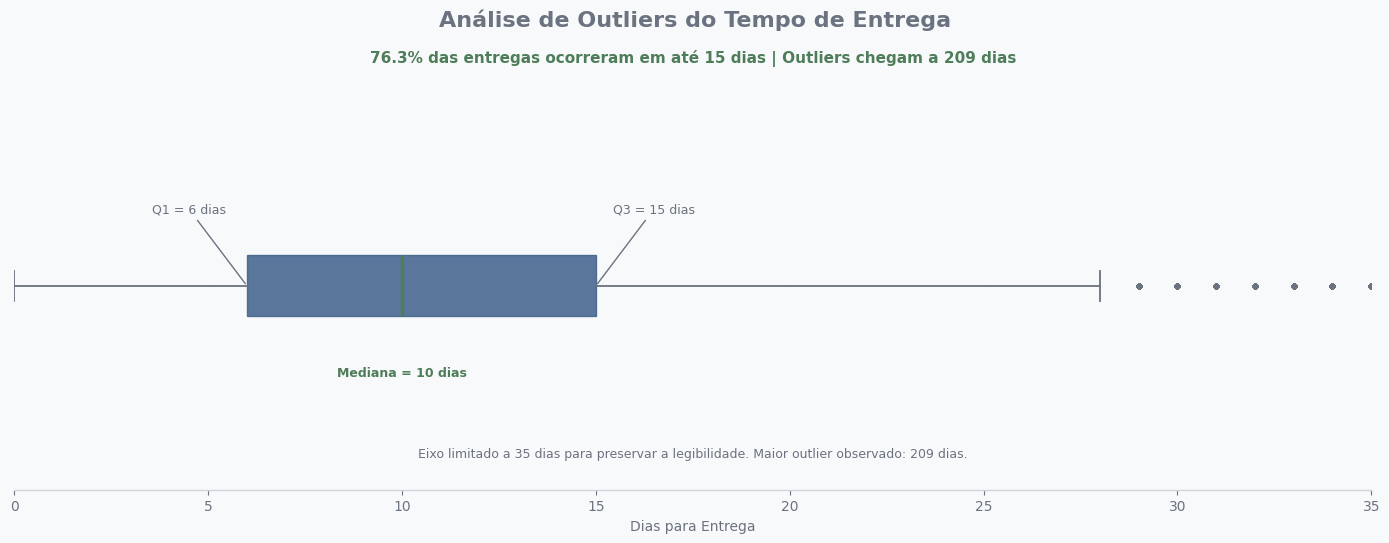

Indicador,Valor
Quantidade de Entregas,110.839
Tempo Médio,"12,0 dias"
Mediana,10 dias
1º Quartil (Q1),6 dias
3º Quartil (Q3),15 dias
Tempo Máximo,209 dias


In [161]:
# ============================================================
# 5.3 - Análise de Outliers do Tempo de Entrega
# Versão executiva revisada
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. Preparação da base
# ============================================================

tempo_entrega = (
    base_satisfacao["tempo_entrega"]
    .dropna()
    .copy()
)

# Estatísticas principais
qtd_entregas = tempo_entrega.count()
media = tempo_entrega.mean()
mediana = tempo_entrega.median()
q1 = tempo_entrega.quantile(0.25)
q3 = tempo_entrega.quantile(0.75)
maximo = tempo_entrega.max()

# Limite visual para preservar legibilidade
limite_visual = 35

# Percentual de entregas até 15 dias
pct_ate_15 = (tempo_entrega <= 15).mean() * 100

# ============================================================
# 2. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5.5), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

# Boxplot horizontal
ax.boxplot(
    tempo_entrega,
    vert=False,
    patch_artist=True,
    showfliers=True,
    boxprops=dict(facecolor=AZUL_EXECUTIVO, color=AZUL_EXECUTIVO, alpha=0.85),
    medianprops=dict(color=VERDE_SOFISTICADO, linewidth=2.5),
    whiskerprops=dict(color=CINZA_EXECUTIVO, linewidth=1.3),
    capprops=dict(color=CINZA_EXECUTIVO, linewidth=1.3),
    flierprops=dict(
        marker="o",
        markerfacecolor=CINZA_EXECUTIVO,
        markeredgecolor=CINZA_EXECUTIVO,
        markersize=3,
        alpha=0.45
    )
)

# Limita visualmente o eixo para focar na distribuição principal
ax.set_xlim(0, limite_visual)

# ============================================================
# 3. Título e subtítulo
# ============================================================

fig.suptitle(
    "Análise de Outliers do Tempo de Entrega",
    fontsize=16,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.98
)

ax.set_title(
    f"{pct_ate_15:.1f}% das entregas ocorreram em até 15 dias | "
    f"Outliers chegam a {maximo:.0f} dias",
    fontsize=11,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    pad=14
)

# ============================================================
# 4. Anotações executivas
# ============================================================

# Q1
ax.annotate(
    f"Q1 = {q1:.0f} dias",
    xy=(q1, 1),
    xytext=(q1 - 1.5, 1.18),
    fontsize=9,
    color=CINZA_EXECUTIVO,
    ha="center",
    arrowprops=dict(arrowstyle="-", color=CINZA_EXECUTIVO, lw=1)
)

# Q3
ax.annotate(
    f"Q3 = {q3:.0f} dias",
    xy=(q3, 1),
    xytext=(q3 + 1.5, 1.18),
    fontsize=9,
    color=CINZA_EXECUTIVO,
    ha="center",
    arrowprops=dict(arrowstyle="-", color=CINZA_EXECUTIVO, lw=1)
)

# Mediana
ax.annotate(
    f"Mediana = {mediana:.0f} dias",
    xy=(mediana, 1),
    xytext=(mediana, 0.78),
    fontsize=9,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    ha="center"
)

# Observação sobre eixo limitado
ax.text(
    0.50,
    0.08,
    f"Eixo limitado a {limite_visual} dias para preservar a legibilidade. "
    f"Maior outlier observado: {maximo:.0f} dias.",
    transform=ax.transAxes,
    fontsize=9,
    color=CINZA_EXECUTIVO,
    ha="center"
)

# ============================================================
# 5. Eixos e acabamento visual
# ============================================================

ax.set_xlabel("Dias para Entrega", fontsize=10, color=CINZA_EXECUTIVO)
ax.set_yticks([])

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#D0D5DD")
ax.tick_params(axis="x", colors=CINZA_EXECUTIVO)

plt.tight_layout()
plt.show()

# ============================================================
# 6. Tabela executiva de apoio
# ============================================================

tabela_outliers_entrega = pd.DataFrame({
    "Indicador": [
        "Quantidade de Entregas",
        "Tempo Médio",
        "Mediana",
        "1º Quartil (Q1)",
        "3º Quartil (Q3)",
        "Tempo Máximo"
    ],
    "Valor": [
        f"{qtd_entregas:,.0f}".replace(",", "."),
        f"{media:.1f} dias".replace(".", ","),
        f"{mediana:.0f} dias",
        f"{q1:.0f} dias",
        f"{q3:.0f} dias",
        f"{maximo:.0f} dias"
    ]
})

display(
    tabela_executiva(
        tabela_outliers_entrega
    )
)

### Principais Resultados Gráfico 5.3

- O tempo mediano de entrega foi de 10 dias.
- Aproximadamente 75% das entregas ocorreram em até 15 dias.
- A maior parte dos pedidos permaneceu concentrada em uma faixa operacional relativamente estável.
- Foram identificados valores extremos significativamente acima do padrão operacional, com entregas que atingiram até 209 dias.

### Insight Executivo

Os resultados demonstram que a operação logística apresenta comportamento consistente para a maioria dos pedidos, concentrando as entregas em até 15 dias. Entretanto, a **presença de casos extremos muito acima do padrão** operacional evidencia ocorrências pontuais que **podem impactar negativamente a experiência do cliente.**

Embora representem uma pequena parcela da operação, **esses casos possuem potencial para influenciar avaliações negativas e aumentar a percepção de risco sobre a qualidade do serviço**. Dessa forma, **os outliers identificados justificam análises complementares para avaliar sua relação com os níveis de satisfação observados na plataforma.**

**O boxplot foi utilizado como visualização complementar** para evidenciar a dispersão dos dados e a presença de valores extremos no tempo de entrega. Entretanto, por se tratar de uma distribuição assimétrica e com cauda longa, ou seja, os atrasos extremos representam exceções na operação, mas possuem potencial de gerar impactos desproporcionais na experiência do cliente, o gráfico não foi adotado como visual principal da análise, pois a concentração dos dados fica comprimida pela influência dos outliers. Assim, a interpretação executiva foi apoiada principalmente pela tabela-resumo e pelo gráfico de distribuição por faixas de prazo, enquanto o boxplot foi mantido como evidência técnica dos casos fora do padrão operacional.

### Recomendação

Investigar separadamente os pedidos com prazos muito elevados para identificar possíveis causas operacionais, regionais ou relacionadas a sellers específicos. A redução desses casos extremos pode gerar ganhos relevantes na experiência do cliente sem exigir mudanças estruturais em toda a operação logística.

### Justificativa Metodológica

O boxplot foi utilizado como **visualização complementar** por permitir identificar mediana, dispersão e valores extremos dos tempos de entrega, características importantes para a análise exploratória dos dados (WILKE, 2019). Entretanto, considerando que o Tech Challenge prioriza a comunicação executiva para investidores e a clareza da mensagem, a interpretação principal foi apoiada pela tabela-resumo e pelo gráfico de distribuição por faixas de prazo, mais intuitivos para esse público (KNAFLIC, 2015; FIAP, 2025).

# Conclusão da Seção 5 – Análise Descritiva da Logística

A análise descritiva da logística permitiu compreender o comportamento geral dos prazos de entrega da Olist e avaliar a consistência operacional da plataforma.

Os resultados demonstraram que a maior parte dos pedidos foi entregue dentro de prazos relativamente curtos e previsíveis, com mediana de 10 dias e concentração significativa das entregas em até 15 dias. Esse comportamento indica que a operação logística atende adequadamente a maioria dos clientes e apresenta estabilidade para grande parte dos pedidos analisados.

Entretanto, também foram identificados casos extremos com tempos de entrega significativamente superiores ao padrão observado. Embora representem uma pequena parcela da operação, esses eventos possuem potencial para impactar negativamente a percepção de qualidade do serviço e a experiência dos consumidores.

Sob a perspectiva de investidores, **os resultados sugerem que a Olist possui uma operação logística consistente e capaz de sustentar o crescimento observado** na seção anterior. No entanto, a presença de entregas fora do padrão evidencia **oportunidades de melhoria operacional que podem gerar ganhos adicionais de satisfação, retenção de clientes e eficiência do marketplace.**

Dessa forma, após compreender o comportamento geral dos prazos de entrega, a próxima etapa da análise busca investigar como o desempenho logístico influencia a experiência do cliente, explorando relações entre lead time, atrasos e níveis de satisfação observados na plataforma.

# 6 - Desempenho Comercial

## Objetivo da Seção

Esta seção analisa o desempenho comercial da Olist por meio da evolução da receita, do ticket médio, da participação das categorias, da distribuição regional do faturamento e do desempenho dos principais sellers.

As análises desenvolvidas possuem caráter predominantemente descritivo e buscam responder à pergunta:

**Como o marketplace gera receita e como esse desempenho evoluiu ao longo do tempo?**

Serão avaliados indicadores financeiros e comerciais que permitem compreender o crescimento da plataforma, a composição do faturamento e os principais fatores associados à geração de receita.

Os resultados desta seção fornecem evidências sobre a capacidade de crescimento do negócio e subsidiam a avaliação de oportunidades e riscos para investidores.

### 6.0 - Construção da Base Comercial

As análises de receita exigem uma base de dados que represente corretamente cada item comercializado na plataforma. Como um mesmo pedido pode conter múltiplos produtos e múltiplas avaliações, torna-se necessário estruturar uma base que preserve a granularidade adequada para os cálculos financeiros.

A construção de uma base no nível item do pedido permite representar com precisão os valores transacionados em cada venda, evitando duplicidades e distorções que poderiam comprometer indicadores como receita, ticket médio e desempenho comercial. Essa etapa garante maior consistência na mensuração dos resultados e na comparação entre diferentes segmentos do negócio.

A base consolidada servirá como fundamento para as análises da Seção 6, permitindo avaliar categorias, estados, sellers e demais indicadores comerciais com uma metodologia padronizada e aderente à estrutura dos dados.


In [162]:
# ============================================================
# 6.0 - Preparação da Base de Receita por Item
# Unidade de análise: item do pedido
# Objetivo: evitar duplicidade de receita por múltiplas avaliações
# ============================================================

import pandas as pd

# ============================================================
# 1. Validação das colunas obrigatórias
# ============================================================

colunas_obrigatorias = [
    "order_id",
    "seller_id",
    "price",
    "order_purchase_timestamp"
]

for coluna in colunas_obrigatorias:
    if coluna not in base_satisfacao.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_satisfacao."
        )

# ============================================================
# 2. Criação da base de receita
# ============================================================

base_receita_item = base_satisfacao.copy()

# Converte data de compra
base_receita_item["order_purchase_timestamp"] = pd.to_datetime(
    base_receita_item["order_purchase_timestamp"],
    errors="coerce"
)

# Cria coluna ano_mes
base_receita_item["ano_mes"] = (
    base_receita_item["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# ============================================================
# 3. Remoção de duplicidades
# ============================================================
# Se existir order_item_id, a granularidade correta é:
# pedido + item + seller.
#
# Se não existir, usa uma chave alternativa mais conservadora.

if "order_item_id" in base_receita_item.columns:
    base_receita_item = base_receita_item.drop_duplicates(
        subset=[
            "order_id",
            "order_item_id",
            "seller_id"
        ]
    ).copy()
else:
    base_receita_item = base_receita_item.drop_duplicates(
        subset=[
            "order_id",
            "seller_id",
            "price"
        ]
    ).copy()

# ============================================================
# 4. Recorte temporal padrão da Seção 6
# ============================================================

base_receita_item = base_receita_item[
    (base_receita_item["ano_mes"] >= "2017-01") &
    (base_receita_item["ano_mes"] <= "2018-07")
].copy()

# ============================================================
# 5. Validação executiva da base criada
# ============================================================

print("============================================================")
print("VALIDAÇÃO DA BASE DE RECEITA POR ITEM")
print("============================================================")
print(f"Linhas na base_satisfacao original : {base_satisfacao.shape[0]:,}")
print(f"Linhas na base_receita_item        : {base_receita_item.shape[0]:,}")
print(f"Pedidos únicos                     : {base_receita_item['order_id'].nunique():,}")
print(f"Sellers únicos                     : {base_receita_item['seller_id'].nunique():,}")
print(f"Receita total analisada            : R$ {base_receita_item['price'].sum():,.2f}")
print(f"Período analisado                  : {base_receita_item['ano_mes'].min()} a {base_receita_item['ano_mes'].max()}")
print("============================================================")

VALIDAÇÃO DA BASE DE RECEITA POR ITEM
Linhas na base_satisfacao original : 113,314
Linhas na base_receita_item        : 105,031
Pedidos únicos                     : 91,901
Sellers únicos                     : 2,913
Receita total analisada            : R$ 12,687,026.45
Período analisado                  : 2017-01 a 2018-07


In [163]:
# ============================================================
# Validação da Base de Receita por Item
# Objetivo:
# Conferir se a base_receita_item está correta para uso na Seção 6,
# garantindo que a granularidade esteja no nível item do pedido.
# ============================================================

import pandas as pd

# ============================================================
# 1. Validação da existência da base
# ============================================================

if "base_receita_item" not in globals():
    raise NameError(
        "A base 'base_receita_item' ainda não foi criada. "
        "Execute primeiro a célula 6.0 - Preparação da Base de Receita por Item."
    )

# ============================================================
# 2. Validação das colunas necessárias para conferência
# ============================================================

colunas_validacao = [
    "order_id",
    "order_item_id",
    "seller_id",
    "price"
]

for coluna in colunas_validacao:
    if coluna not in base_receita_item.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_receita_item."
        )

# ============================================================
# 3. Resumo executivo da base
# ============================================================

resumo_base_receita = pd.DataFrame({
    "indicador": [
        "Linhas na base_receita_item",
        "Quantidade de colunas",
        "Pedidos únicos",
        "Sellers únicos",
        "Receita total analisada"
    ],
    "valor": [
        f"{base_receita_item.shape[0]:,}".replace(",", "."),
        f"{base_receita_item.shape[1]}",
        f"{base_receita_item['order_id'].nunique():,}".replace(",", "."),
        f"{base_receita_item['seller_id'].nunique():,}".replace(",", "."),
        f"R$ {base_receita_item['price'].sum():,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    ]
})

display(
    tabela_executiva(
        resumo_base_receita
    )
)

# ============================================================
# 4. Amostra da base para validar granularidade
# ============================================================
# A visualização abaixo permite confirmar que:
# - cada pedido pode ter mais de um item;
# - o mesmo pedido pode aparecer mais de uma vez quando há itens diferentes;
# - a receita está preservada no nível do item vendido.
# ============================================================

amostra_base_receita_item = (
    base_receita_item[
        [
            "order_id",
            "order_item_id",
            "seller_id",
            "price"
        ]
    ]
    .head(20)
    .copy()
)

display(
    tabela_executiva(
        amostra_base_receita_item
    )
)

indicador,valor
Linhas na base_receita_item,105.031
Quantidade de colunas,39
Pedidos únicos,91.901
Sellers únicos,2.913
Receita total analisada,"R$ 12.687.026,45"


order_id,order_item_id,seller_id,price
00010242fe8c5a6d1ba2dd792cb16214,1,48436dade18ac8b2bce089ec2a041202,58.900000
00018f77f2f0320c557190d7a144bdd3,1,dd7ddc04e1b6c2c614352b383efe2d36,239.900000
000229ec398224ef6ca0657da4fc703e,1,5b51032eddd242adc84c38acab88f23d,199.000000
00042b26cf59d7ce69dfabb4e55b4fd9,1,df560393f3a51e74553ab94004ba5c87,199.900000
00048cc3ae777c65dbb7d2a0634bc1ea,1,6426d21aca402a131fc0a5d0960a3c90,21.900000
00054e8431b9d7675808bcb819fb4a32,1,7040e82f899a04d1b434b795a43b4617,19.900000
000576fe39319847cbb9d288c5617fa6,1,5996cddab893a4652a15592fb58ab8db,810.000000
0005a1a1728c9d785b8e2b08b904576c,1,a416b6a846a11724393025641d4edd5e,145.950000
0005f50442cb953dcd1d21e1fb923495,1,ba143b05f0110f0dc71ad71b4466ce92,53.990000
00061f2a7bc09da83e415a52dc8a4af1,1,cc419e0650a3c5ba77189a1882b7556a,59.990000


### Resultado da Preparação da Base de Receita

A base `base_receita_item` foi criada para sustentar as análises comerciais da Seção 6, considerando a granularidade de item do pedido.

Essa estrutura permite calcular receita, ticket médio, participação por categoria, participação por estado e desempenho de sellers sem duplicar valores por múltiplas avaliações e sem perder itens de pedidos compostos por mais de um produto.

Dessa forma, a Seção 6 passa a utilizar uma base metodologicamente mais adequada para análises de desempenho comercial.

### 6.1 - Evolução Mensal da Receita

Após a construção da base comercial no nível item do pedido, torna-se possível analisar o comportamento da receita gerada pela plataforma ao longo do tempo. A evolução mensal da receita permite compreender a dinâmica de crescimento das vendas e identificar períodos de maior ou menor desempenho comercial.

Essa análise contribui para avaliar a capacidade da Olist de ampliar o volume financeiro transacionado ao longo do período estudado, fornecendo uma visão da trajetória de crescimento do negócio. Além de evidenciar tendências temporais, a análise permite observar possíveis variações associadas à sazonalidade e ao comportamento da demanda.

Os resultados apresentados a seguir demonstram como a receita evoluiu mês a mês, oferecendo subsídios para a avaliação do desempenho comercial da plataforma.


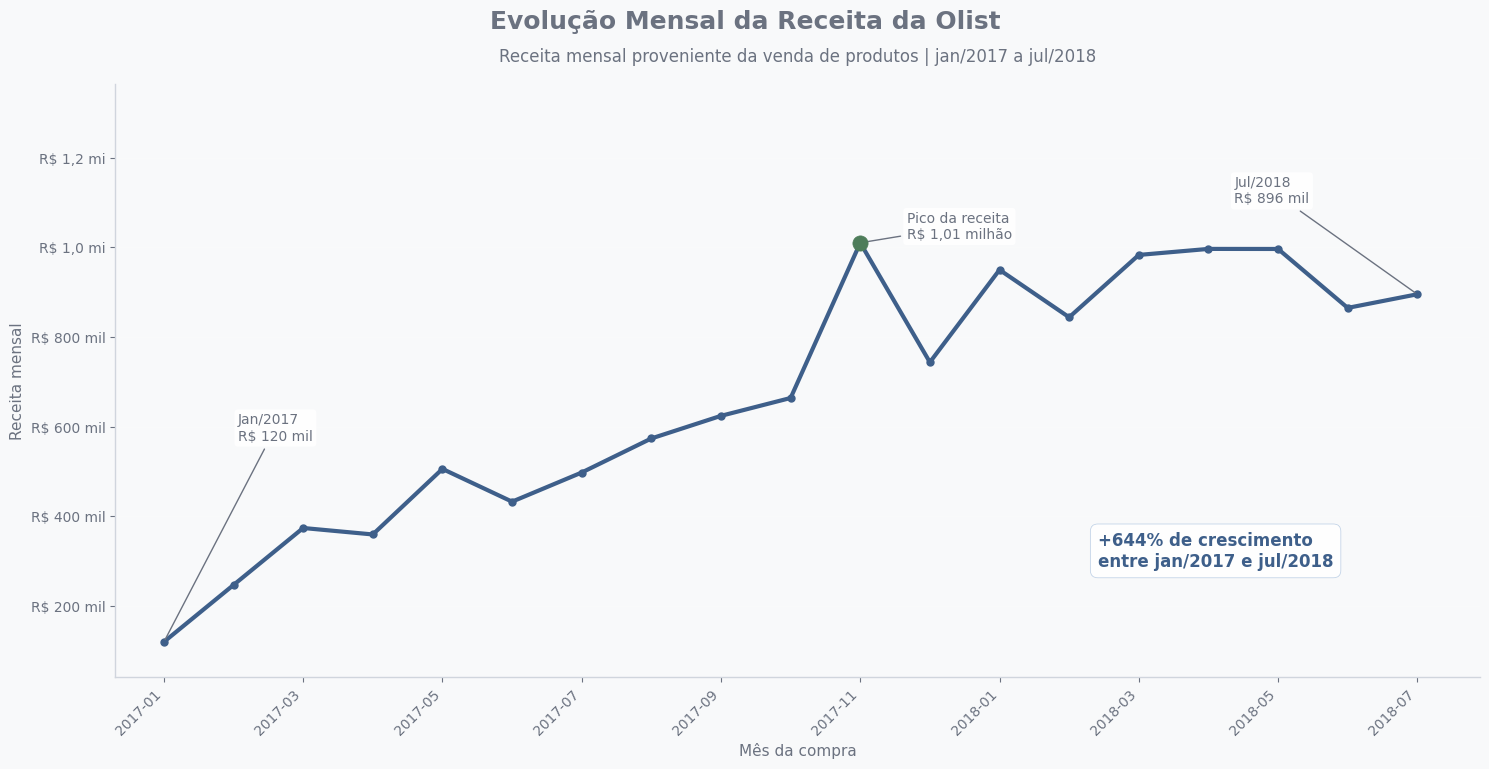

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ano_mes,receita_total,pedidos
2017-01,120312.870000,789
2017-02,247303.020000,1733
2017-03,374344.300000,2641
2017-04,359927.230000,2391
2017-05,506071.140000,3660
2017-06,433038.600000,3217
2017-07,498031.480000,3969
2017-08,573971.680000,4293
2017-09,624401.690000,4243
2017-10,664219.430000,4568


In [164]:
# ============================================================
# 6.1 - Evolução Mensal da Receita
# Base: base_receita_item
# Unidade de análise: item do pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from google.colab import files

# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# 1. Validação da base e colunas necessárias
# ============================================================

if "base_receita_item" not in globals():
    raise NameError(
        "A base 'base_receita_item' não existe. Execute primeiro a célula 6.0."
    )

colunas_necessarias = ["order_id", "price", "ano_mes"]

for coluna in colunas_necessarias:
    if coluna not in base_receita_item.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_receita_item."
        )

# ============================================================
# 2. Cálculo da receita mensal
# ============================================================

receita_mensal = (
    base_receita_item
    .dropna(subset=["ano_mes", "price", "order_id"])
    .groupby("ano_mes", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

receita_mensal = receita_mensal.sort_values("ano_mes").reset_index(drop=True)
receita_mensal["x_pos"] = range(len(receita_mensal))

# ============================================================
# 3. Indicadores principais
# ============================================================

primeiro_mes = receita_mensal.iloc[0]
ultimo_mes = receita_mensal.iloc[-1]

maior_receita = receita_mensal.loc[
    receita_mensal["receita_total"].idxmax()
]

crescimento_receita = (
    (ultimo_mes["receita_total"] / primeiro_mes["receita_total"]) - 1
) * 100

# ============================================================
# 4. Funções de formatação monetária
# ============================================================

def moeda_eixo(x, pos):
    if x >= 1_000_000:
        return f"R$ {x / 1_000_000:.1f} mi".replace(".", ",")
    return f"R$ {x / 1000:.0f} mil"


def moeda_rotulo(valor):
    if valor >= 1_000_000:
        return f"R$ {valor / 1_000_000:.2f} milhão".replace(".", ",")
    return f"R$ {valor / 1000:.0f} mil"

# ============================================================
# 5. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(15, 7.8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

ax.plot(
    receita_mensal["x_pos"],
    receita_mensal["receita_total"],
    color=AZUL_EXECUTIVO,
    linewidth=3,
    marker="o",
    markersize=5
)

ax.scatter(
    maior_receita["x_pos"],
    maior_receita["receita_total"],
    color=VERDE_SOFISTICADO,
    s=120,
    zorder=5
)

# ============================================================
# 6. Títulos
# ============================================================

fig.suptitle(
    "Evolução Mensal da Receita da Olist",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.98
)

ax.set_title(
    "Receita mensal proveniente da venda de produtos | jan/2017 a jul/2018",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=16
)

# ============================================================
# 7. Caixa executiva
# ============================================================

ax.text(
    0.72,
    0.18,
    f"+{crescimento_receita:.0f}% de crescimento\nentre jan/2017 e jul/2018",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 8. Rótulos estratégicos
# ============================================================

ax.annotate(
    f"Jan/2017\n{moeda_rotulo(primeiro_mes['receita_total'])}",
    xy=(primeiro_mes["x_pos"], primeiro_mes["receita_total"]),
    xytext=(0.09, 0.42),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.25", facecolor=BRANCO, edgecolor="none", alpha=0.92),
    arrowprops=dict(arrowstyle="-", color=CINZA_EXECUTIVO, lw=1)
)

ax.annotate(
    f"Pico da receita\n{moeda_rotulo(maior_receita['receita_total'])}",
    xy=(maior_receita["x_pos"], maior_receita["receita_total"]),
    xytext=(0.58, 0.76),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.25", facecolor=BRANCO, edgecolor="none", alpha=0.92),
    arrowprops=dict(arrowstyle="-", color=CINZA_EXECUTIVO, lw=1)
)

ax.annotate(
    f"Jul/2018\n{moeda_rotulo(ultimo_mes['receita_total'])}",
    xy=(ultimo_mes["x_pos"], ultimo_mes["receita_total"]),
    xytext=(0.82, 0.82),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.25", facecolor=BRANCO, edgecolor="none", alpha=0.92),
    arrowprops=dict(arrowstyle="-", color=CINZA_EXECUTIVO, lw=1)
)

# ============================================================
# 9. Eixos e acabamento
# ============================================================

ax.set_ylabel("Receita mensal", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_xlabel("Mês da compra", fontsize=11, color=CINZA_EXECUTIVO)

ax.yaxis.set_major_formatter(FuncFormatter(moeda_eixo))

ax.set_xticks(receita_mensal["x_pos"][::2])
ax.set_xticklabels(
    receita_mensal["ano_mes"][::2],
    rotation=45,
    ha="right"
)

ax.set_xlim(-0.7, len(receita_mensal) - 0.1)

ax.set_ylim(
    receita_mensal["receita_total"].min() * 0.35,
    receita_mensal["receita_total"].max() * 1.35
)

ax.grid(axis="y", alpha=0.20)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

# ============================================================
# 10. Exportação
# ============================================================

nome_arquivo = "grafico_6_1_evolucao_mensal_receita_base_receita_item.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# 11. Tabela executiva
# ============================================================

tabela_receita = receita_mensal[
    ["ano_mes", "receita_total", "pedidos"]
].copy()

tabela_receita["receita_total"] = tabela_receita["receita_total"].round(2)

display(
    tabela_executiva(tabela_receita)
)

### Principais Resultados Gráfico 6.1

- A **receita mensal apresentou crescimento expressivo** entre jan/2017 e jul/2018.
- O faturamento evoluiu de aproximadamente **R\$ 120 mil em jan/2017 para R\$ 896 mil em jul/2018**.
- O **pico de receita ocorreu em nov/2017**, atingindo aproximadamente **R\$ 1,01 milhão**.
- A receita acumulou **crescimento de aproximadamente 644%** no período analisado.
- Apesar de oscilações pontuais, a trajetória geral demonstra **forte expansão comercial da plataforma**.

### Insight Executivo

A evolução da receita demonstra que a Olist passou por uma fase de forte expansão comercial, ampliando significativamente sua capacidade de geração de valor. O comportamento da série sugere crescimento sustentado do marketplace, com aumento relevante do volume financeiro transacionado ao longo do tempo.

### Recomendação

Analisar em conjunto o comportamento do ticket médio e do volume de pedidos para identificar os principais fatores responsáveis pelo crescimento da receita. Essa avaliação permitirá verificar se a expansão ocorreu principalmente por ganho de escala operacional, aumento do valor médio das compras ou pela combinação de ambos.


### 6.2 - Evolução Mensal do Ticket Médio

Além do crescimento da receita, é importante compreender como o valor médio das compras se comportou ao longo do período analisado. O ticket médio representa o valor médio gasto pelos clientes em cada pedido e permite avaliar se a expansão do negócio ocorreu por compras de maior valor ou pelo aumento da quantidade de pedidos realizados.

A análise da evolução mensal do ticket médio complementa a avaliação financeira da plataforma, fornecendo uma visão mais detalhada dos fatores que contribuíram para o desempenho comercial observado. Ao comparar seu comportamento com a evolução da receita, torna-se possível identificar se o crescimento foi impulsionado por mudanças no padrão de consumo dos clientes ou pelo ganho de escala da operação.

Os resultados apresentados a seguir demonstram a evolução do ticket médio ao longo do período estudado, contribuindo para a compreensão da dinâmica de crescimento da Olist.


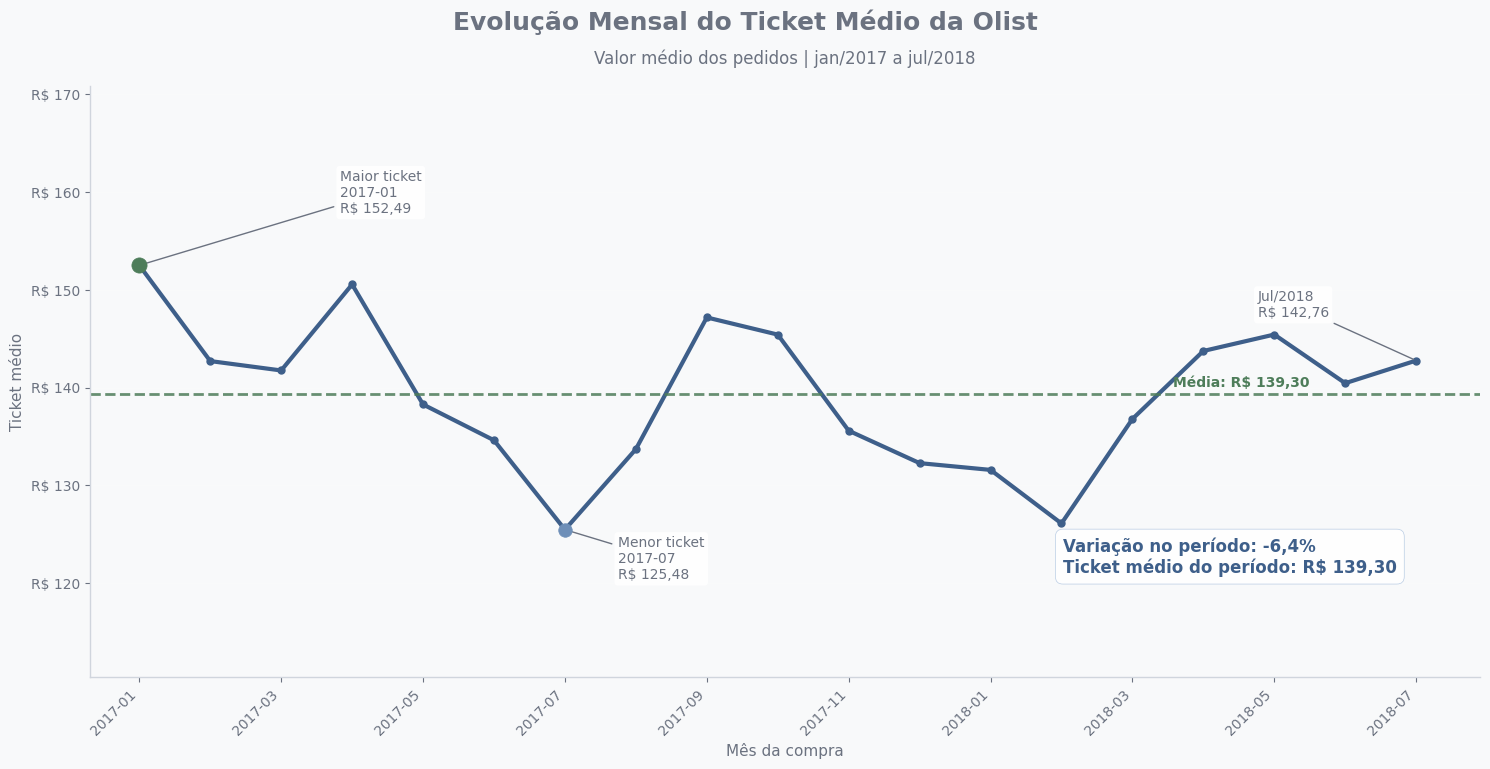

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ano_mes,receita_total,pedidos,ticket_medio
2017-01,120312.870000,789,152.490000
2017-02,247303.020000,1733,142.700000
2017-03,374344.300000,2641,141.740000
2017-04,359927.230000,2391,150.530000
2017-05,506071.140000,3660,138.270000
2017-06,433038.600000,3217,134.610000
2017-07,498031.480000,3969,125.480000
2017-08,573971.680000,4293,133.700000
2017-09,624401.690000,4243,147.160000
2017-10,664219.430000,4568,145.410000


In [165]:
# ============================================================
# 6.2 - Evolução Mensal do Ticket Médio
# Base: base_receita_item
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from google.colab import files

# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# 1. Validação da base e colunas necessárias
# ============================================================

if "base_receita_item" not in globals():
    raise NameError(
        "A base 'base_receita_item' não existe. Execute primeiro a célula 6.0."
    )

colunas_necessarias = ["order_id", "price", "ano_mes"]

for coluna in colunas_necessarias:
    if coluna not in base_receita_item.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_receita_item."
        )

# ============================================================
# 2. Cálculo mensal da receita, pedidos e ticket médio
# ============================================================

ticket_mensal = (
    base_receita_item
    .dropna(subset=["ano_mes", "price", "order_id"])
    .groupby("ano_mes", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

ticket_mensal = ticket_mensal.sort_values("ano_mes").reset_index(drop=True)

ticket_mensal["ticket_medio"] = (
    ticket_mensal["receita_total"] / ticket_mensal["pedidos"]
)

ticket_mensal["x_pos"] = range(len(ticket_mensal))

# ============================================================
# 3. Indicadores principais
# ============================================================

primeiro_mes = ticket_mensal.iloc[0]
ultimo_mes = ticket_mensal.iloc[-1]

maior_ticket = ticket_mensal.loc[
    ticket_mensal["ticket_medio"].idxmax()
]

menor_ticket = ticket_mensal.loc[
    ticket_mensal["ticket_medio"].idxmin()
]

media_ticket = ticket_mensal["ticket_medio"].mean()

variacao_ticket = (
    (ultimo_mes["ticket_medio"] / primeiro_mes["ticket_medio"]) - 1
) * 100

# ============================================================
# 4. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(15, 7.8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

ax.plot(
    ticket_mensal["x_pos"],
    ticket_mensal["ticket_medio"],
    color=AZUL_EXECUTIVO,
    linewidth=3,
    marker="o",
    markersize=5
)

# Linha de média do período
ax.axhline(
    media_ticket,
    color=VERDE_SOFISTICADO,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

# Destaque do maior ticket
ax.scatter(
    maior_ticket["x_pos"],
    maior_ticket["ticket_medio"],
    color=VERDE_SOFISTICADO,
    s=120,
    zorder=5
)

# Destaque do menor ticket
ax.scatter(
    menor_ticket["x_pos"],
    menor_ticket["ticket_medio"],
    color=AZUL_MEDIO,
    s=95,
    zorder=5
)

# ============================================================
# 5. Título e subtítulo
# ============================================================

fig.suptitle(
    "Evolução Mensal do Ticket Médio da Olist",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.98
)

ax.set_title(
    "Valor médio dos pedidos | jan/2017 a jul/2018",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=16
)

# ============================================================
# 6. Caixa executiva
# ============================================================

ax.text(
    0.70,
    0.17,
    (
        f"Variação no período: {variacao_ticket:+.1f}%\n"
        f"Ticket médio do período: R$ {media_ticket:.2f}"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 7. Rótulos estratégicos
# ============================================================

ax.annotate(
    f"Maior ticket\n{maior_ticket['ano_mes']}\nR$ {maior_ticket['ticket_medio']:.2f}".replace(".", ","),
    xy=(maior_ticket["x_pos"], maior_ticket["ticket_medio"]),
    xytext=(0.18, 0.82),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=BRANCO,
        edgecolor="none",
        alpha=0.92
    ),
    arrowprops=dict(
        arrowstyle="-",
        color=CINZA_EXECUTIVO,
        lw=1
    )
)

ax.annotate(
    f"Menor ticket\n{menor_ticket['ano_mes']}\nR$ {menor_ticket['ticket_medio']:.2f}".replace(".", ","),
    xy=(menor_ticket["x_pos"], menor_ticket["ticket_medio"]),
    xytext=(0.38, 0.20),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=BRANCO,
        edgecolor="none",
        alpha=0.92
    ),
    arrowprops=dict(
        arrowstyle="-",
        color=CINZA_EXECUTIVO,
        lw=1
    )
)

ax.annotate(
    f"Jul/2018\nR$ {ultimo_mes['ticket_medio']:.2f}".replace(".", ","),
    xy=(ultimo_mes["x_pos"], ultimo_mes["ticket_medio"]),
    xytext=(0.84, 0.63),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=BRANCO,
        edgecolor="none",
        alpha=0.92
    ),
    arrowprops=dict(
        arrowstyle="-",
        color=CINZA_EXECUTIVO,
        lw=1
    )
)

ax.text(
    ticket_mensal["x_pos"].max() - 1.5,
    media_ticket + 0.8,
    f"Média: R$ {media_ticket:.2f}".replace(".", ","),
    fontsize=10,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    ha="right"
)

# ============================================================
# 8. Eixos e acabamento visual
# ============================================================

ax.set_ylabel("Ticket médio", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_xlabel("Mês da compra", fontsize=11, color=CINZA_EXECUTIVO)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"R$ {x:.0f}".replace(".", ","))
)

ax.set_xticks(ticket_mensal["x_pos"][::2])
ax.set_xticklabels(
    ticket_mensal["ano_mes"][::2],
    rotation=45,
    ha="right"
)

ax.set_xlim(-0.7, len(ticket_mensal) - 0.1)

ax.set_ylim(
    ticket_mensal["ticket_medio"].min() * 0.88,
    ticket_mensal["ticket_medio"].max() * 1.12
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

# ============================================================
# 9. Exportação da imagem
# ============================================================

nome_arquivo = "grafico_6_2_evolucao_ticket_medio_base_receita_item.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# 10. Tabela executiva
# ============================================================

tabela_ticket = ticket_mensal[
    ["ano_mes", "receita_total", "pedidos", "ticket_medio"]
].copy()

tabela_ticket["receita_total"] = tabela_ticket["receita_total"].round(2)
tabela_ticket["ticket_medio"] = tabela_ticket["ticket_medio"].round(2)

display(
    tabela_executiva(tabela_ticket)
)

### Principais Resultados Gráfico 6.2

- O **ticket médio apresentou relativa estabilidade ao longo do período analisado**.
- O **maior ticket médio ocorreu em jan/2017**, atingindo aproximadamente **R\$ 152,49 por pedido**.
- O **menor ticket médio foi observado em jul/2017**, com aproximadamente **R\$ 125,48 por pedido**.
- Em jul/2018, o ticket médio atingiu **R\$ 142,76**, representando uma variação de aproximadamente **-6,4%** em relação ao início da série.
- O ticket médio médio do período foi de aproximadamente **R\$ 139,30**.

### Insight Executivo

Apesar do forte crescimento da receita observado no gráfico anterior, o ticket médio permaneceu relativamente estável durante o período analisado. Esse comportamento sugere que o crescimento da Olist foi impulsionado principalmente pelo aumento do volume de pedidos e da base de clientes, e não pelo aumento do valor médio gasto em cada compra.

### Recomendação

Monitorar conjuntamente receita, volume de pedidos e ticket médio para diferenciar crescimento por escala de crescimento por valor transacionado. Os resultados indicam que a estratégia de expansão da Olist esteve fortemente associada ao ganho de escala operacional, característica típica de marketplaces em fase de crescimento.

### 6.3 - Participação da Receita por Categoria

A distribuição da receita entre as categorias de produtos permite compreender quais segmentos possuem maior contribuição para o desempenho financeiro da plataforma. Em marketplaces com portfólio diversificado, é comum que parte relevante da receita esteja concentrada em um grupo específico de categorias, tornando importante identificar quais delas exercem maior influência sobre os resultados do negócio.

A análise da participação da receita por categoria contribui para a compreensão da composição comercial da Olist, evidenciando os segmentos que apresentam maior representatividade no faturamento total. Essa visão permite avaliar o grau de concentração da receita e identificar categorias com potencial estratégico para a sustentação do crescimento da plataforma.

Os resultados apresentados a seguir demonstram a participação das principais categorias na receita total da Olist, permitindo identificar os segmentos mais relevantes para o desempenho comercial do marketplace.


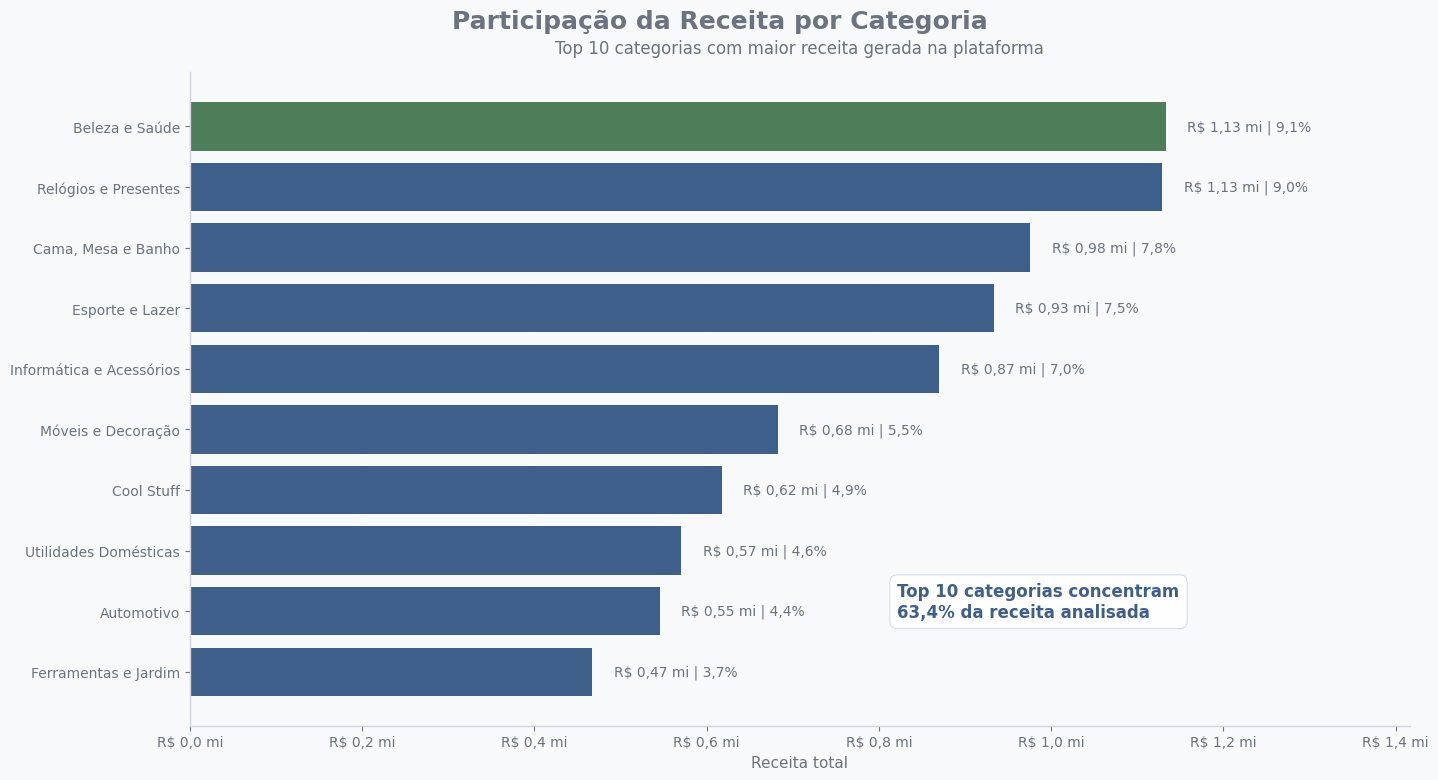

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

categoria_executiva,receita_total,participacao_receita,pedidos
Beleza e Saúde,1133189.920000,9.100000,8013
Relógios e Presentes,1129368.380000,9.000000,5227
"Cama, Mesa e Banho",975473.810000,7.800000,8854
Esporte e Lazer,933215.170000,7.500000,7265
Informática e Acessórios,870261.070000,7.000000,6287
Móveis e Decoração,682501.560000,5.500000,6053
Cool Stuff,617825.270000,4.900000,3504
Utilidades Domésticas,570758.920000,4.600000,5313
Automotivo,545505.970000,4.400000,3534
Ferramentas e Jardim,467464.240000,3.700000,3391


In [166]:
# ============================================================
# 6.3 - Participação da Receita por Categoria
# Versão executiva
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from google.colab import files

# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Função para formatar categorias
# ============================================================

def formatar_categoria(nome):
    nome_formatado = (
        str(nome)
        .replace("_", " ")
        .replace("-", " ")
        .strip()
        .title()
    )

    ajustes = {
        "Beleza Saude": "Beleza e Saúde",
        "Relogios Presentes": "Relógios e Presentes",
        "Cama Mesa Banho": "Cama, Mesa e Banho",
        "Esporte Lazer": "Esporte e Lazer",
        "Informatica Acessorios": "Informática e Acessórios",
        "Moveis Decoracao": "Móveis e Decoração",
        "Utilidades Domesticas": "Utilidades Domésticas",
        "Ferramentas Jardim": "Ferramentas e Jardim",
        "Moveis Escritorio": "Móveis de Escritório",
        "Construcao Ferramentas Construcao": "Construção e Ferramentas",
        "Casa Construcao": "Casa e Construção",
        "Telefonia": "Telefonia",
        "Automotivo": "Automotivo",
        "Brinquedos": "Brinquedos"
    }

    return ajustes.get(nome_formatado, nome_formatado)

# ============================================================
# Função de formatação monetária
# ============================================================

def moeda_milhoes(x, pos):
    return f"R$ {x / 1_000_000:.1f} mi".replace(".", ",")

# ============================================================
# 1. Validação das colunas necessárias
# ============================================================

colunas_necessarias = ["order_id", "price"]

for coluna in colunas_necessarias:
    if coluna not in base_satisfacao.columns:
        raise KeyError(f"A coluna obrigatória '{coluna}' não existe em base_satisfacao.")

if "categoria_produto" in base_satisfacao.columns:
    coluna_categoria = "categoria_produto"
elif "product_category_name" in base_satisfacao.columns:
    coluna_categoria = "product_category_name"
elif "product_category_name_english" in base_satisfacao.columns:
    coluna_categoria = "product_category_name_english"
else:
    raise KeyError(
        "Não foi encontrada coluna de categoria em base_satisfacao."
    )

# ============================================================
# 2. Preparação da base
# ============================================================

df_categoria = base_receita_item.copy()

df_categoria = df_categoria.dropna(
    subset=[coluna_categoria, "price", "order_id"]
).copy()

df_categoria["categoria_executiva"] = (
    df_categoria[coluna_categoria]
    .apply(formatar_categoria)
)

# ============================================================
# 3. Cálculo da receita por categoria
# ============================================================

receita_total = df_categoria["price"].sum()

receita_categoria = (
    df_categoria
    .groupby("categoria_executiva", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

receita_categoria["participacao_receita"] = (
    receita_categoria["receita_total"] / receita_total
) * 100

top10_categoria = (
    receita_categoria
    .sort_values("receita_total", ascending=False)
    .head(10)
    .copy()
)

top10_categoria = top10_categoria.sort_values(
    "receita_total",
    ascending=True
)

participacao_top10 = top10_categoria["participacao_receita"].sum()
categoria_lider = top10_categoria.iloc[-1]

# ============================================================
# 4. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(14.5, 8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if categoria == categoria_lider["categoria_executiva"]
    else AZUL_EXECUTIVO
    for categoria in top10_categoria["categoria_executiva"]
]

barras = ax.barh(
    top10_categoria["categoria_executiva"],
    top10_categoria["receita_total"],
    color=cores
)

# ============================================================
# 5. Título e subtítulo
# ============================================================

fig.suptitle(
    "Participação da Receita por Categoria",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Top 10 categorias com maior receita gerada na plataforma",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# 6. Rótulos das barras
# ============================================================

for barra, valor, participacao in zip(
    barras,
    top10_categoria["receita_total"],
    top10_categoria["participacao_receita"]
):
    ax.text(
        barra.get_width() + receita_total * 0.002,
        barra.get_y() + barra.get_height() / 2,
        f"R$ {valor / 1_000_000:.2f} mi | {participacao:.1f}%".replace(".", ","),
        va="center",
        ha="left",
        fontsize=10,
        color=CINZA_EXECUTIVO
    )

# ============================================================
# 7. Caixa executiva
# ============================================================

ax.text(
    0.58,
    0.16,
    (
        f"Top 10 categorias concentram\n"
        f"{participacao_top10:.1f}% da receita analisada"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 8. Eixos e acabamento visual
# ============================================================

ax.set_xlabel("Receita total", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("")

ax.xaxis.set_major_formatter(FuncFormatter(moeda_milhoes))

ax.set_xlim(
    0,
    top10_categoria["receita_total"].max() * 1.25
)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO, labelsize=10)

plt.tight_layout()

# ============================================================
# 9. Exportação da imagem
# ============================================================

nome_arquivo = "grafico_6_3_receita_por_categoria.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# 10. Tabela executiva
# ============================================================

tabela_categoria = top10_categoria.sort_values(
    "receita_total",
    ascending=False
).copy()

tabela_categoria["receita_total"] = tabela_categoria["receita_total"].round(2)
tabela_categoria["participacao_receita"] = tabela_categoria["participacao_receita"].round(1)

display(
    tabela_executiva(
        tabela_categoria[
            [
                "categoria_executiva",
                "receita_total",
                "participacao_receita",
                "pedidos"
            ]
        ]
    )
)

### Principais Resultados Gráfico 6.3

- As **10 categorias com maior faturamento concentraram 63,4% da receita analisada**.
- **Beleza e Saúde** foi a categoria líder, representando aproximadamente **9,1% da receita total**.
- Relógios e Presentes e Cama, Mesa e Banho aparecem na sequência, com participações de **9,0%** e **7,8%**, respectivamente.
- Nenhuma categoria individual ultrapassou **10% da receita total da plataforma**.
- A distribuição da receita demonstra **concentração moderada**, porém sem dependência excessiva de uma única categoria.

### Insight Executivo

A geração de receita da Olist está distribuída entre diversas categorias relevantes, com destaque para **Beleza e Saúde**, **Relógios e Presentes** e **Cama, Mesa e Banho**. Embora as dez principais categorias concentrem aproximadamente dois terços da receita, nenhuma domina isoladamente o faturamento da plataforma, indicando um portfólio relativamente diversificado e menos exposto ao risco de concentração em um único segmento.

### Recomendação

Priorizar ações comerciais e de expansão nas categorias líderes, aproveitando segmentos já consolidados para acelerar o crescimento da receita. Paralelamente, monitorar categorias intermediárias para ampliar a diversificação do faturamento e reduzir riscos de concentração no longo prazo.

### 6.4 - Participação da Receita por Estado

Além da análise por categoria, é importante compreender como a receita da plataforma está distribuída geograficamente. A identificação dos estados com maior participação no faturamento permite avaliar a relevância dos diferentes mercados regionais para o desempenho comercial da Olist.

A análise da participação da receita por estado contribui para o entendimento da concentração geográfica das vendas, evidenciando quais regiões possuem maior representatividade na geração de receita. Essa visão auxilia na compreensão da distribuição do mercado consumidor e da importância relativa de cada estado para os resultados da plataforma.

Os resultados apresentados a seguir demonstram a participação dos principais estados na receita total da Olist, permitindo identificar os mercados com maior contribuição para o faturamento do marketplace.


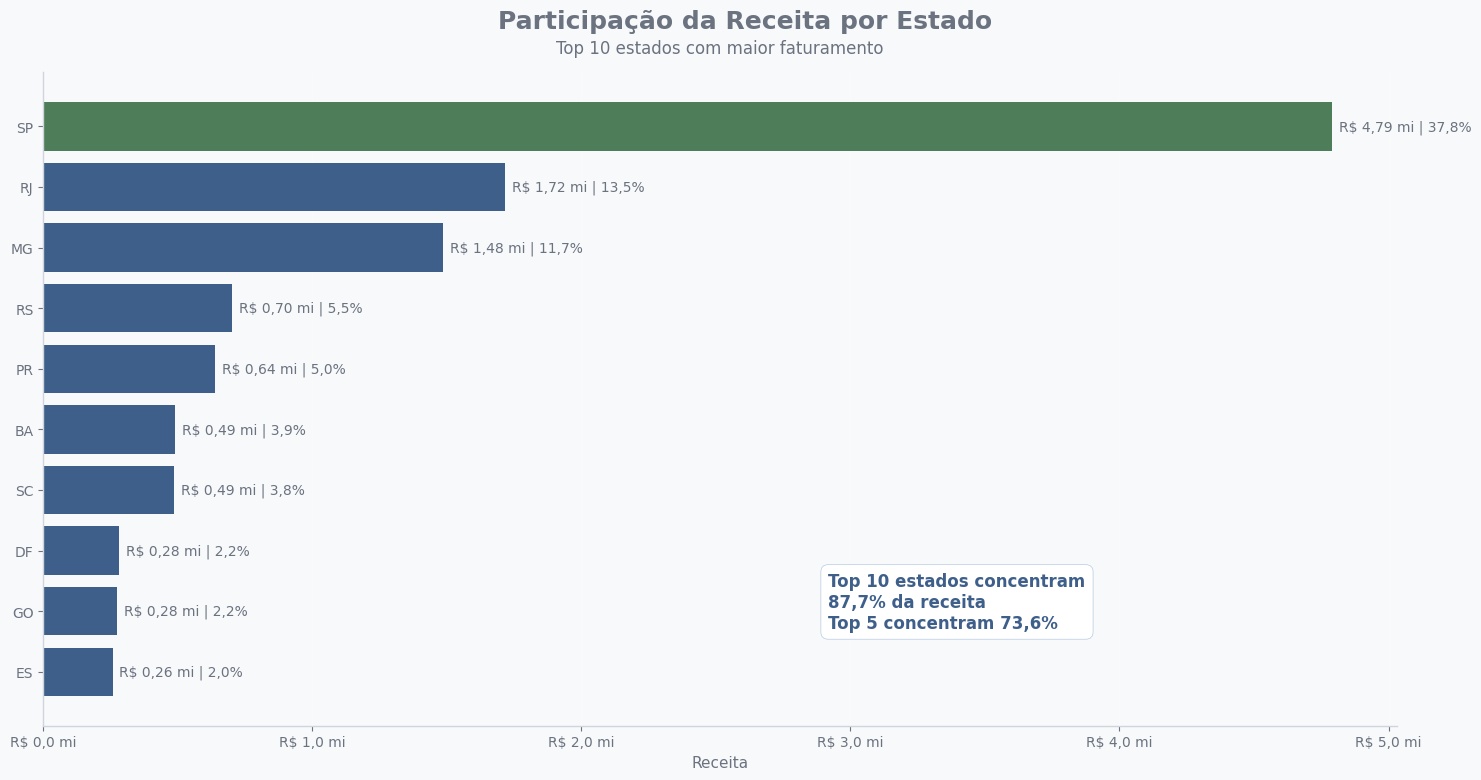

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

customer_state,receita_total,participacao,pedidos
SP,4791485.740000,37.800000,38046
RJ,1717083.240000,13.500000,11971
MG,1484760.400000,11.700000,10800
RS,703020.800000,5.500000,5112
PR,639763.040000,5.000000,4647
BA,488609.100000,3.900000,3190
SC,485824.450000,3.800000,3399
DF,281618.540000,2.200000,1975
GO,275543.670000,2.200000,1881
ES,257509.480000,2.000000,1916


In [167]:
# ============================================================
# 6.4 - Participação da Receita por Estado
# Base: base_receita_item
# Unidade de análise: item vendido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from google.colab import files

# ============================================================
# Paleta oficial
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Identificação da coluna de estado
# ============================================================

if "customer_state" in base_receita_item.columns:
    coluna_estado = "customer_state"
elif "estado_cliente" in base_receita_item.columns:
    coluna_estado = "estado_cliente"
else:
    raise KeyError(
        "Não foi encontrada coluna de estado do cliente."
    )

# ============================================================
# Preparação da base
# ============================================================

df_estado = base_receita_item.copy()

df_estado = df_estado.dropna(
    subset=[coluna_estado, "price", "order_id"]
).copy()

df_estado[coluna_estado] = (
    df_estado[coluna_estado]
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# Receita por estado
# ============================================================

receita_estado = (
    df_estado
    .groupby(coluna_estado, as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

receita_total = receita_estado["receita_total"].sum()

receita_estado["participacao"] = (
    receita_estado["receita_total"]
    / receita_total
) * 100

top10 = (
    receita_estado
    .sort_values(
        "receita_total",
        ascending=False
    )
    .head(10)
    .copy()
)

participacao_top10 = (
    top10["participacao"]
    .sum()
)

participacao_top5 = (
    top10.head(5)["participacao"]
    .sum()
)

top10_plot = (
    top10
    .sort_values(
        "receita_total",
        ascending=True
    )
)

estado_lider = (
    top10.iloc[0][coluna_estado]
)

# ============================================================
# Formatação monetária
# ============================================================

def moeda_milhoes(x, pos):

    return (
        f"R$ {x / 1_000_000:.1f} mi"
        .replace(".", ",")
    )

# ============================================================
# Construção do gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 8),
    facecolor=FUNDO_CLARO
)

ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO
    if estado == estado_lider
    else AZUL_EXECUTIVO
    for estado in top10_plot[coluna_estado]
]

barras = ax.barh(
    top10_plot[coluna_estado],
    top10_plot["receita_total"],
    color=cores
)

# ============================================================
# Títulos
# ============================================================

fig.suptitle(
    "Participação da Receita por Estado",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Top 10 estados com maior faturamento",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# Rótulos
# ============================================================

for barra, receita, perc in zip(
    barras,
    top10_plot["receita_total"],
    top10_plot["participacao"]
):

    ax.text(
        barra.get_width()
        + receita_total * 0.002,

        barra.get_y()
        + barra.get_height() / 2,

        (
            f"R$ {receita / 1_000_000:.2f} mi | "
            f"{perc:.1f}%"
        ).replace(".", ","),

        va="center",
        fontsize=10,
        color=CINZA_EXECUTIVO
    )

# ============================================================
# Caixa executiva
# ============================================================

ax.text(
    0.58,
    0.15,

    (
        f"Top 10 estados concentram\n"
        f"{participacao_top10:.1f}% da receita\n"
        f"Top 5 concentram {participacao_top5:.1f}%"
    ).replace(".", ","),

    transform=ax.transAxes,

    fontsize=12,
    fontweight="bold",

    color=AZUL_EXECUTIVO,

    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO
    )
)

# ============================================================
# Eixos
# ============================================================

ax.set_xlabel(
    "Receita",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(moeda_milhoes)
)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(
    axis="both",
    colors=CINZA_EXECUTIVO
)

plt.tight_layout()

# ============================================================
# Exportação
# ============================================================

nome_arquivo = (
    "grafico_6_4_receita_estado.png"
)

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()

files.download(nome_arquivo)

# ============================================================
# Tabela executiva
# ============================================================

tabela_estado = (
    top10[
        [
            coluna_estado,
            "receita_total",
            "participacao",
            "pedidos"
        ]
    ]
    .copy()
)

tabela_estado["receita_total"] = (
    tabela_estado["receita_total"]
    .round(2)
)

tabela_estado["participacao"] = (
    tabela_estado["participacao"]
    .round(1)
)

display(
    tabela_executiva(
        tabela_estado
    )
)

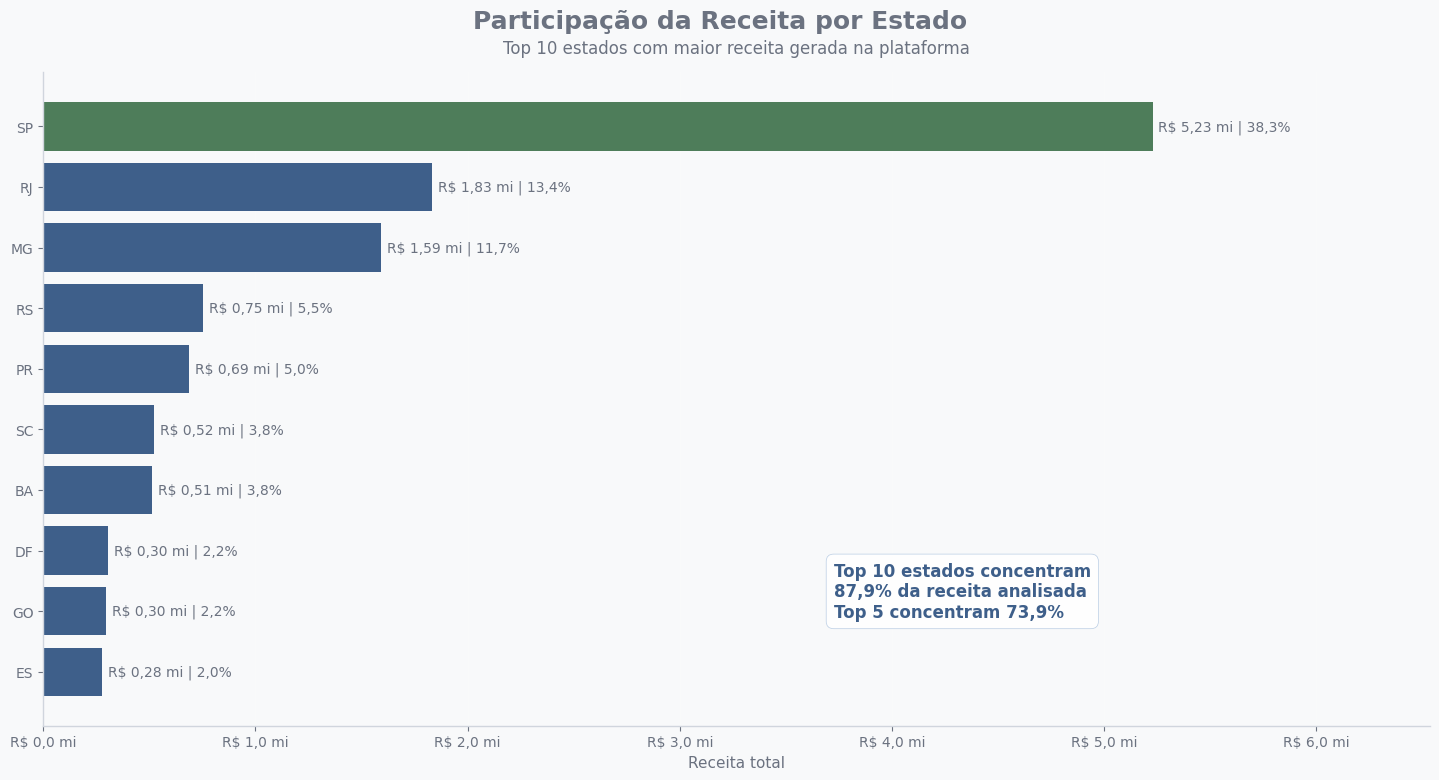

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

customer_state,receita_total,participacao_receita,pedidos
SP,5228869.170000,38.300000,41375
RJ,1831678.850000,13.400000,12762
MG,1591518.470000,11.700000,11544
RS,754250.330000,5.500000,5432
PR,685911.510000,5.000000,4998
SC,522120.110000,3.800000,3612
BA,513182.780000,3.800000,3358
DF,304658.170000,2.200000,2125
GO,297535.490000,2.200000,2007
ES,275910.680000,2.000000,2025


In [168]:
# ============================================================
# 6.4 - Participação da Receita por Estado
# Versão executiva
# Unidade de análise: receita por UF do cliente
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from google.colab import files

# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# 1. Validação das colunas necessárias
# ============================================================

colunas_necessarias = ["order_id", "price"]

for coluna in colunas_necessarias:
    if coluna not in base_satisfacao.columns:
        raise KeyError(
            f"A coluna obrigatória '{coluna}' não existe em base_satisfacao."
        )

# Identificação automática da coluna de estado do cliente
if "customer_state" in base_satisfacao.columns:
    coluna_estado = "customer_state"
elif "estado_cliente" in base_satisfacao.columns:
    coluna_estado = "estado_cliente"
elif "estado" in base_satisfacao.columns:
    coluna_estado = "estado"
else:
    raise KeyError(
        "Não foi encontrada coluna de estado do cliente em base_satisfacao. "
        "Verifique se existe 'customer_state', 'estado_cliente' ou 'estado'."
    )

# ============================================================
# 2. Preparação da base
# ============================================================

df_estado = base_satisfacao.copy()

df_estado = df_estado.dropna(
    subset=["order_id", "price", coluna_estado]
).copy()

df_estado[coluna_estado] = (
    df_estado[coluna_estado]
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# 3. Cálculo da receita por estado
# ============================================================

receita_total = df_estado["price"].sum()

receita_estado = (
    df_estado
    .groupby(coluna_estado, as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

receita_estado["participacao_receita"] = (
    receita_estado["receita_total"] / receita_total
) * 100

top10_estado = (
    receita_estado
    .sort_values("receita_total", ascending=False)
    .head(10)
    .copy()
)

top10_estado_plot = top10_estado.sort_values(
    "receita_total",
    ascending=True
).copy()

estado_lider = top10_estado.iloc[0]
participacao_top10 = top10_estado["participacao_receita"].sum()
participacao_top5 = top10_estado.head(5)["participacao_receita"].sum()

# ============================================================
# 4. Função de formatação monetária
# ============================================================

def moeda_milhoes(x, pos):
    return f"R$ {x / 1_000_000:.1f} mi".replace(".", ",")

# ============================================================
# 5. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(14.5, 8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if estado == estado_lider[coluna_estado]
    else AZUL_EXECUTIVO
    for estado in top10_estado_plot[coluna_estado]
]

barras = ax.barh(
    top10_estado_plot[coluna_estado],
    top10_estado_plot["receita_total"],
    color=cores
)

# ============================================================
# 6. Título e subtítulo
# ============================================================

fig.suptitle(
    "Participação da Receita por Estado",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Top 10 estados com maior receita gerada na plataforma",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# 7. Rótulos das barras
# ============================================================

for barra, valor, participacao in zip(
    barras,
    top10_estado_plot["receita_total"],
    top10_estado_plot["participacao_receita"]
):
    ax.text(
        barra.get_width() + receita_total * 0.002,
        barra.get_y() + barra.get_height() / 2,
        f"R$ {valor / 1_000_000:.2f} mi | {participacao:.1f}%".replace(".", ","),
        va="center",
        ha="left",
        fontsize=10,
        color=CINZA_EXECUTIVO
    )

# ============================================================
# 8. Caixa executiva
# ============================================================

ax.text(
    0.57,
    0.16,
    (
        f"Top 10 estados concentram\n"
        f"{participacao_top10:.1f}% da receita analisada\n"
        f"Top 5 concentram {participacao_top5:.1f}%"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 9. Eixos e acabamento visual
# ============================================================

ax.set_xlabel("Receita total", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("")

ax.xaxis.set_major_formatter(FuncFormatter(moeda_milhoes))

ax.set_xlim(
    0,
    top10_estado_plot["receita_total"].max() * 1.25
)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO, labelsize=10)

plt.tight_layout()

# ============================================================
# 10. Exportação da imagem
# ============================================================

nome_arquivo = "grafico_6_4_receita_por_estado.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# 11. Tabela executiva
# ============================================================

tabela_estado = top10_estado.copy()

tabela_estado["receita_total"] = tabela_estado["receita_total"].round(2)
tabela_estado["participacao_receita"] = (
    tabela_estado["participacao_receita"]
    .round(1)
)

display(
    tabela_executiva(
        tabela_estado[
            [
                coluna_estado,
                "receita_total",
                "participacao_receita",
                "pedidos"
            ]
        ]
    )
)

### Principais Resultados Gráfico 6.4

- **São Paulo concentra 37,8% da receita total analisada**, consolidando-se como o principal mercado da plataforma.
- Rio de Janeiro (13,5%) e Minas Gerais (11,7%) aparecem na sequência, formando com São Paulo os três estados mais relevantes em geração de receita.
- **Os 5 principais estados concentram 73,6% da receita**, enquanto os 10 principais concentram 87,7%.
- Observa-se forte concentração do faturamento na região Sudeste, especialmente em São Paulo.
- A distribuição da receita demonstra dependência relevante de poucos mercados regionais.

### Insight Executivo

A geração de receita da Olist apresenta elevada concentração geográfica, com destaque para São Paulo, responsável por mais de um terço do faturamento analisado. Embora essa concentração reflita a relevância econômica da região Sudeste, ela também evidencia uma dependência significativa de poucos mercados. Para investidores, esse comportamento sugere oportunidades de expansão em regiões com menor participação relativa, reduzindo riscos de concentração e ampliando o potencial de crescimento da plataforma.

### Recomendação

Priorizar estratégias de expansão comercial e aquisição de sellers em estados fora do eixo principal de faturamento, buscando ampliar a presença regional da plataforma. Paralelamente, manter investimentos nos mercados líderes para preservar a geração de receita enquanto se reduz gradualmente a dependência de poucos estados.

### 6.5 - Top Sellers por Receita

Os sellers desempenham papel fundamental no desempenho de um marketplace, uma vez que são responsáveis pela oferta de produtos e pela geração de vendas na plataforma. Compreender como a receita está distribuída entre os vendedores permite avaliar o nível de concentração do faturamento e identificar os participantes com maior relevância para o negócio.

A análise dos sellers com maior geração de receita contribui para o entendimento da estrutura comercial da Olist, evidenciando se o faturamento está amplamente distribuído entre diversos vendedores ou concentrado em um grupo mais restrito. Essa visão auxilia na avaliação da robustez do ecossistema da plataforma e da importância relativa dos principais sellers para os resultados financeiros.

Os resultados apresentados a seguir demonstram os sellers com maior participação na receita da Olist, permitindo identificar o grau de concentração do faturamento entre os principais vendedores do marketplace.


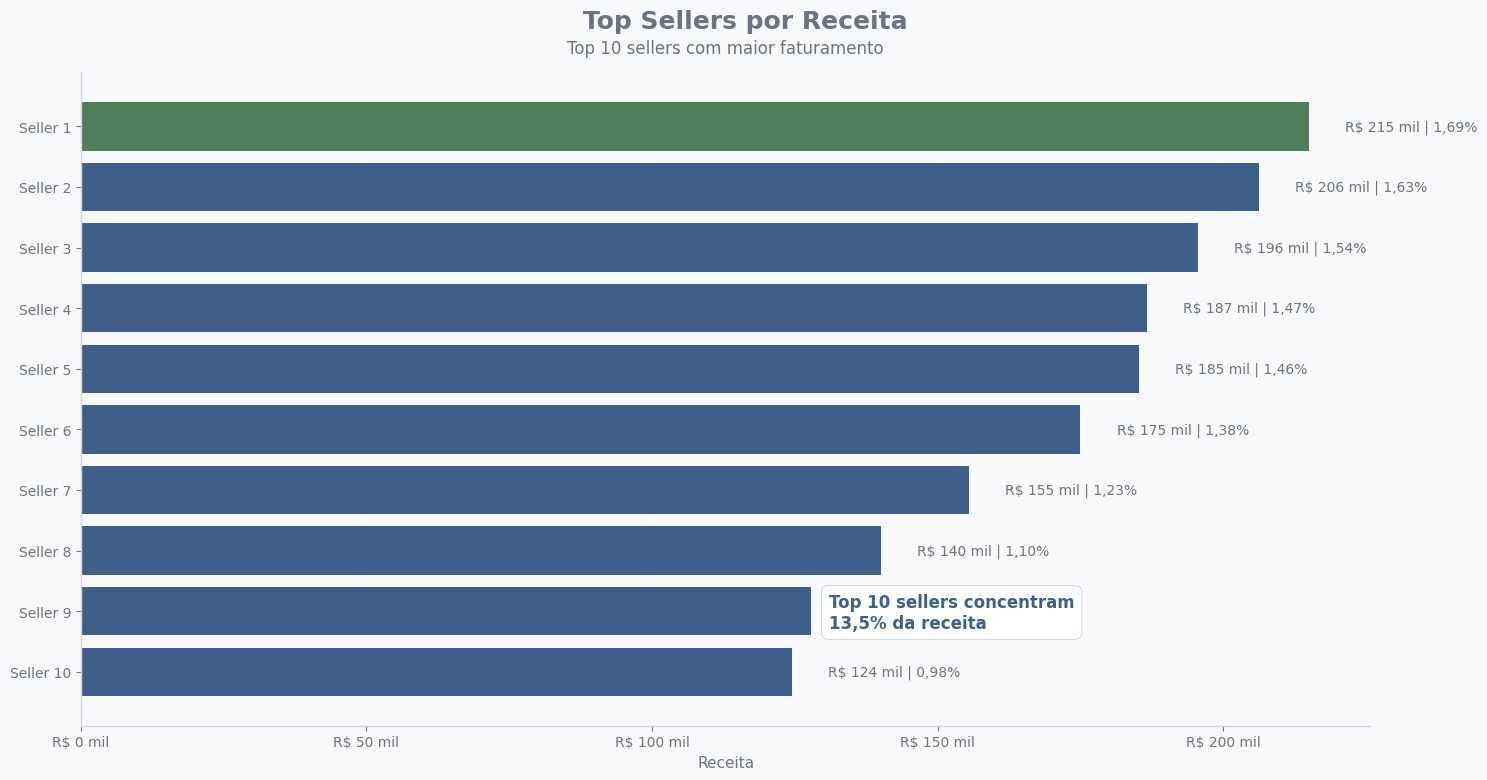

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

seller_label,receita_total,participacao,pedidos
Seller 1,215043.230000,1.694985,1049
Seller 2,206338.050000,1.626370,304
Seller 3,195542.520000,1.541279,1757
Seller 4,186624.120000,1.470984,973
Seller 5,185327.230000,1.460762,553
Seller 6,175032.870000,1.379621,335
Seller 7,155437.590000,1.225170,1256
Seller 8,140092.710000,1.104220,1142
Seller 9,127867.130000,1.007857,1220
Seller 10,124496.360000,0.981289,505


In [169]:
# ============================================================
# 6.5 - Top Sellers por Receita
# Base: base_receita_item
# Unidade de análise: seller
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from google.colab import files

# ============================================================
# Paleta oficial
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Preparação da base
# ============================================================

df_seller = base_receita_item.copy()

df_seller = df_seller.dropna(
    subset=["seller_id", "price", "order_id"]
).copy()

# ============================================================
# Receita por seller
# ============================================================

receita_seller = (
    df_seller
    .groupby("seller_id", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
)

receita_total = receita_seller["receita_total"].sum()

receita_seller["participacao"] = (
    receita_seller["receita_total"]
    / receita_total
) * 100

top10 = (
    receita_seller
    .sort_values(
        "receita_total",
        ascending=False
    )
    .head(10)
    .copy()
)

participacao_top10 = (
    top10["participacao"]
    .sum()
)

top10["seller_label"] = [
    f"Seller {i}"
    for i in range(1, len(top10) + 1)
]

top10_plot = (
    top10
    .sort_values(
        "receita_total",
        ascending=True
    )
)

seller_lider = (
    top10.iloc[0]["seller_label"]
)

# ============================================================
# Formatação monetária
# ============================================================

def moeda_mil(x, pos):

    return (
        f"R$ {x / 1000:.0f} mil"
        .replace(".", ",")
    )

# ============================================================
# Construção do gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 8),
    facecolor=FUNDO_CLARO
)

ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO
    if seller == seller_lider
    else AZUL_EXECUTIVO
    for seller in top10_plot["seller_label"]
]

barras = ax.barh(
    top10_plot["seller_label"],
    top10_plot["receita_total"],
    color=cores
)

# ============================================================
# Títulos
# ============================================================

fig.suptitle(
    "Top Sellers por Receita",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Top 10 sellers com maior faturamento",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# Rótulos
# ============================================================

for barra, receita, perc in zip(
    barras,
    top10_plot["receita_total"],
    top10_plot["participacao"]
):

    ax.text(
        barra.get_width()
        + receita_total * 0.0005,

        barra.get_y()
        + barra.get_height() / 2,

        (
            f"R$ {receita / 1000:.0f} mil | "
            f"{perc:.2f}%"
        ).replace(".", ","),

        va="center",
        fontsize=10,
        color=CINZA_EXECUTIVO
    )

# ============================================================
# Caixa executiva
# ============================================================

ax.text(
    0.58,
    0.15,

    (
        f"Top 10 sellers concentram\n"
        f"{participacao_top10:.1f}% da receita"
    ).replace(".", ","),

    transform=ax.transAxes,

    fontsize=12,
    fontweight="bold",

    color=AZUL_EXECUTIVO,

    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO
    )
)

# ============================================================
# Eixos
# ============================================================

ax.set_xlabel(
    "Receita",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(moeda_mil)
)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(
    axis="both",
    colors=CINZA_EXECUTIVO
)

plt.tight_layout()

# ============================================================
# Exportação
# ============================================================

nome_arquivo = "grafico_6_5_top_sellers_receita.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()

files.download(nome_arquivo)

# ============================================================
# Tabela executiva
# ============================================================

tabela_seller = (
    top10[
        [
            "seller_label",
            "receita_total",
            "participacao",
            "pedidos"
        ]
    ]
    .copy()
)

display(
    tabela_executiva(
        tabela_seller
    )
)

### Principais Resultados Gráfico 6.5

- O seller com maior faturamento representa aproximadamente **1,69% da receita total analisada**.
- Os **10 maiores sellers concentram apenas 13,5% da receita da plataforma**.
- Nenhum seller individual possui participação superior a 2% do faturamento total.
- A distribuição da receita entre sellers é altamente pulverizada.
- Os resultados indicam baixa dependência comercial de vendedores específicos.

### Insight Executivo

Diferentemente da concentração observada em alguns estados e categorias, a receita da Olist apresenta forte diversificação entre sellers. A baixa participação individual dos maiores vendedores demonstra que o marketplace possui um ecossistema distribuído, reduzindo riscos operacionais e comerciais associados à perda de sellers estratégicos.

### Recomendação

Manter estratégias de aquisição e retenção de sellers, preservando o elevado nível de diversificação observado. A continuidade desse modelo reduz riscos de concentração e fortalece a sustentabilidade do crescimento da plataforma no longo prazo.

### 6.6 - Crescimento Comparado: Receita, Pedidos e Ticket Médio

Após analisar individualmente a evolução da receita e do ticket médio, torna-se importante avaliar esses indicadores em conjunto com o volume de pedidos. A comparação simultânea dessas métricas permite compreender quais fatores exerceram maior influência sobre o crescimento comercial observado ao longo do período analisado.

A utilização de um índice base 100 possibilita comparar variáveis com escalas diferentes em uma mesma visualização, evidenciando a intensidade e a velocidade de crescimento de cada indicador ao longo do tempo. Essa abordagem contribui para identificar se a expansão da receita ocorreu principalmente pelo aumento da quantidade de pedidos realizados ou por mudanças no valor médio das compras.

Os resultados apresentados a seguir demonstram a evolução comparada da receita, dos pedidos e do ticket médio, permitindo uma compreensão mais abrangente dos fatores que impulsionaram o crescimento da Olist durante o período estudado.


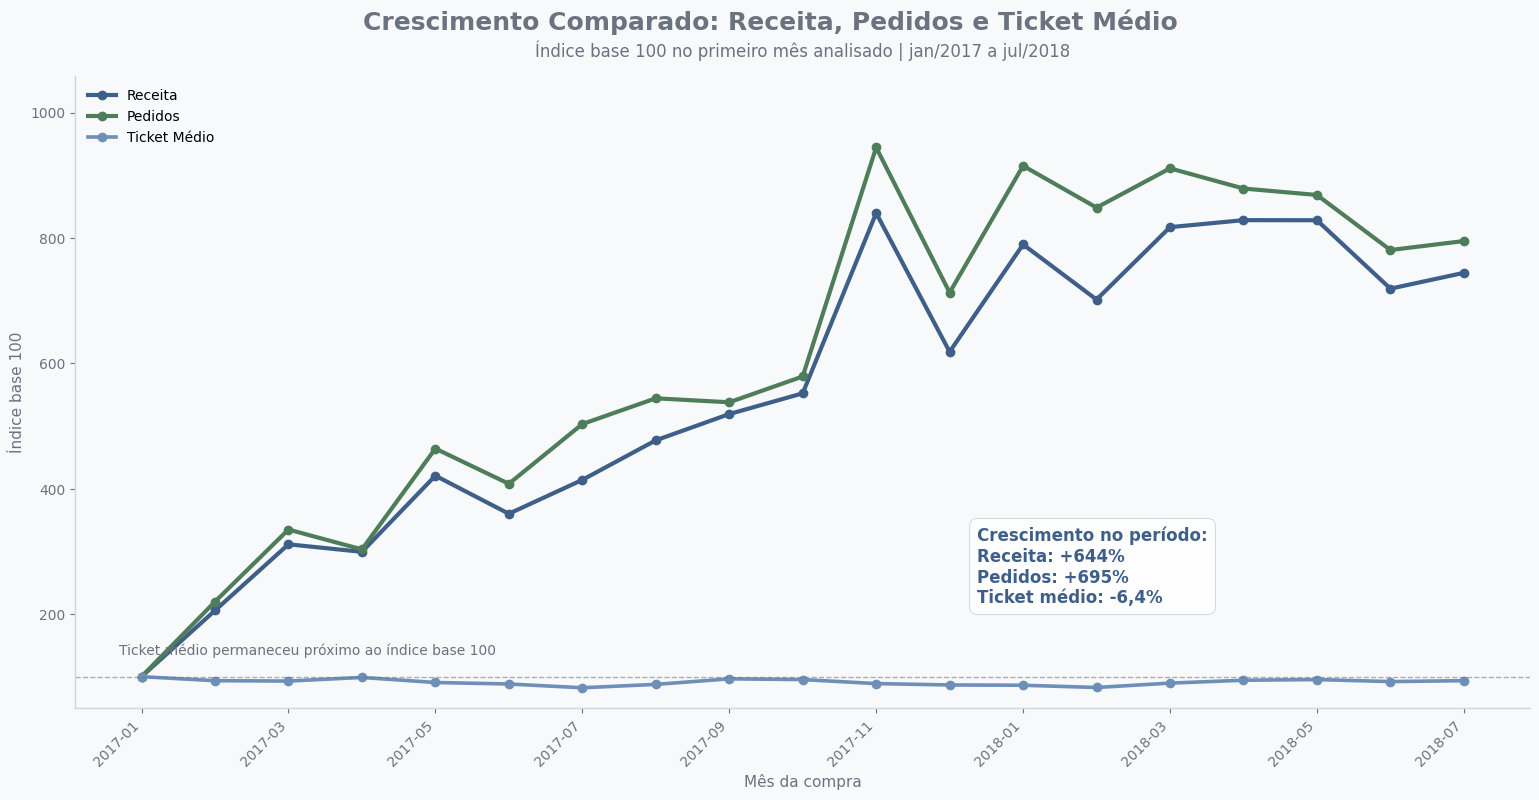

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ano_mes,receita_total,pedidos,ticket_medio,indice_receita,indice_pedidos,indice_ticket
2017-01,120312.870000,789,152.490000,100.000000,100.000000,100.000000
2017-02,247303.020000,1733,142.700000,205.550000,219.650000,93.580000
2017-03,374344.300000,2641,141.740000,311.140000,334.730000,92.950000
2017-04,359927.230000,2391,150.530000,299.160000,303.040000,98.720000
2017-05,506071.140000,3660,138.270000,420.630000,463.880000,90.680000
2017-06,433038.600000,3217,134.610000,359.930000,407.730000,88.280000
2017-07,498031.480000,3969,125.480000,413.950000,503.040000,82.290000
2017-08,573971.680000,4293,133.700000,477.070000,544.110000,87.680000
2017-09,624401.690000,4243,147.160000,518.980000,537.770000,96.510000
2017-10,664219.430000,4568,145.410000,552.080000,578.960000,95.360000


In [170]:
# ============================================================
# 6.6 - Crescimento Comparado: Receita, Pedidos e Ticket Médio
# Versão ajustada
# Base: base_receita_item
# Unidade de análise: mês
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Validação
# ============================================================

colunas_necessarias = ["order_id", "price", "ano_mes"]

for coluna in colunas_necessarias:
    if coluna not in base_receita_item.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_receita_item.")

# ============================================================
# Preparação dos indicadores
# ============================================================

df = (
    base_receita_item
    .dropna(subset=colunas_necessarias)
    .copy()
)

indicadores = (
    df.groupby("ano_mes", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
    .sort_values("ano_mes")
)

indicadores["ticket_medio"] = (
    indicadores["receita_total"] / indicadores["pedidos"]
)

indicadores["indice_receita"] = (
    indicadores["receita_total"] / indicadores["receita_total"].iloc[0] * 100
)

indicadores["indice_pedidos"] = (
    indicadores["pedidos"] / indicadores["pedidos"].iloc[0] * 100
)

indicadores["indice_ticket"] = (
    indicadores["ticket_medio"] / indicadores["ticket_medio"].iloc[0] * 100
)

indicadores["x_pos"] = range(len(indicadores))

crescimento_receita = indicadores["indice_receita"].iloc[-1] - 100
crescimento_pedidos = indicadores["indice_pedidos"].iloc[-1] - 100
crescimento_ticket = indicadores["indice_ticket"].iloc[-1] - 100

# ============================================================
# Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(15.5, 8.2), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

ax.plot(
    indicadores["x_pos"],
    indicadores["indice_receita"],
    marker="o",
    linewidth=3,
    color=AZUL_EXECUTIVO,
    label="Receita"
)

ax.plot(
    indicadores["x_pos"],
    indicadores["indice_pedidos"],
    marker="o",
    linewidth=3,
    color=VERDE_SOFISTICADO,
    label="Pedidos"
)

ax.plot(
    indicadores["x_pos"],
    indicadores["indice_ticket"],
    marker="o",
    linewidth=2.6,
    color=AZUL_MEDIO,
    label="Ticket Médio"
)

ax.axhline(
    100,
    color=CINZA_EXECUTIVO,
    linestyle="--",
    linewidth=1,
    alpha=0.55
)

# ============================================================
# Títulos
# ============================================================

fig.suptitle(
    "Crescimento Comparado: Receita, Pedidos e Ticket Médio",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Índice base 100 no primeiro mês analisado | jan/2017 a jul/2018",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# Caixa executiva
# ============================================================

ax.text(
    0.62,
    0.16,
    (
        f"Crescimento no período:\n"
        f"Receita: +{crescimento_receita:.0f}%\n"
        f"Pedidos: +{crescimento_pedidos:.0f}%\n"
        f"Ticket médio: {crescimento_ticket:+.1f}%"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# Destaque visual do ticket médio
# ============================================================

ax.text(
    0.03,
    0.08,
    "Ticket médio permaneceu próximo ao índice base 100",
    transform=ax.transAxes,
    fontsize=10,
    color=CINZA_EXECUTIVO,
    ha="left",
    va="bottom"
)

# ============================================================
# Eixos e acabamento
# ============================================================

ax.set_xlabel("Mês da compra", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("Índice base 100", fontsize=11, color=CINZA_EXECUTIVO)

ax.set_xticks(indicadores["x_pos"][::2])
ax.set_xticklabels(
    indicadores["ano_mes"][::2],
    rotation=45,
    ha="right"
)

ax.set_ylim(
    min(indicadores["indice_ticket"].min() * 0.85, 50),
    max(indicadores["indice_pedidos"].max(), indicadores["indice_receita"].max()) * 1.12
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=10
)

plt.tight_layout()

# ============================================================
# Exportação
# ============================================================

nome_arquivo = "grafico_6_6_crescimento_comparado_ajustado.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# Tabela executiva
# ============================================================

tabela_crescimento = indicadores[
    [
        "ano_mes",
        "receita_total",
        "pedidos",
        "ticket_medio",
        "indice_receita",
        "indice_pedidos",
        "indice_ticket"
    ]
].copy()

display(
    tabela_executiva(
        tabela_crescimento.round(2)
    )
)

### Principais Resultados Gráfico 6.6

- A **receita apresentou crescimento de aproximadamente 644%** entre jan/2017 e jul/2018.
- O **volume de pedidos cresceu cerca de 695%**, superando o crescimento da receita.
- O **ticket médio permaneceu relativamente estável**, encerrando o período com variação aproximada de **-6,4%**.
- A trajetória da receita acompanhou de forma próxima a evolução do volume de pedidos.
- Os resultados indicam que o crescimento comercial foi impulsionado principalmente pelo ganho de escala operacional.

### Insight Executivo

A expansão da Olist ocorreu principalmente por meio do aumento da quantidade de pedidos processados na plataforma e não pelo aumento do valor médio das compras. Esse comportamento é típico de marketplaces em fase de crescimento, que ampliam sua base de clientes, sellers e transações para sustentar a expansão da receita.

### Recomendação

Continuar monitorando conjuntamente receita, pedidos e ticket médio para diferenciar crescimento por escala de crescimento por valor. Os resultados sugerem que futuras iniciativas de expansão devem focar na ampliação da base transacional e na eficiência operacional, mantendo o ticket médio em níveis sustentáveis.

#  Conclusão da Seção 6 – Desempenho Comercial

### Principais Resultados

- A Olist apresentou **crescimento expressivo da receita**, que evoluiu aproximadamente **644% entre jan/2017 e jul/2018**.
- O crescimento observado foi impulsionado principalmente pelo **aumento do volume de pedidos**, uma vez que o ticket médio permaneceu relativamente estável ao longo do período.
- As **10 principais categorias concentraram 63,4% da receita**, indicando concentração moderada, porém sem dependência excessiva de um único segmento.
- Os **10 principais estados concentraram 87,7% da receita**, evidenciando forte concentração geográfica, especialmente na região Sudeste.
- Os **10 maiores sellers responderam por apenas 13,5% da receita total**, demonstrando elevada pulverização da base de vendedores.
- Nenhum seller individual representou mais de 2% do faturamento da plataforma, reduzindo riscos de dependência comercial.

### Insight Executivo

Os resultados demonstram que a Olist opera como um marketplace escalável e diversificado. O crescimento da receita foi sustentado principalmente pela expansão da operação e do volume transacionado, e não pelo aumento do valor médio gasto por pedido. Embora exista concentração relevante em determinadas regiões e categorias, a plataforma apresenta baixa dependência de sellers específicos, característica que aumenta a resiliência do modelo de negócio e reduz riscos operacionais para investidores.

### Recomendação

Para sustentar o crescimento no longo prazo, recomenda-se:

- Expandir a atuação em estados com menor participação relativa na receita, reduzindo a concentração geográfica observada.
- Fortalecer as categorias líderes, mantendo o foco nos segmentos que já demonstram elevada capacidade de geração de receita.
- Continuar ampliando a base de sellers, preservando o elevado nível de diversificação identificado.
- Monitorar continuamente receita, volume de pedidos e ticket médio para avaliar a sustentabilidade do crescimento e identificar novas oportunidades de expansão comercial.

# 7 - Perfil da Satisfação dos Clientes

## Objetivo da Seção

Após compreender o comportamento operacional e comercial da Olist, esta seção apresenta uma visão geral da satisfação dos clientes a partir das avaliações registradas na plataforma.

As análises desenvolvidas possuem caráter predominantemente descritivo e buscam responder à pergunta:

**Como os clientes avaliam a experiência de compra na Olist?**

Serão exploradas a distribuição das avaliações e as diferenças observadas entre categorias e regiões, permitindo compreender o perfil geral da satisfação antes da investigação dos fatores que a influenciam.

Os resultados desta seção servirão de base para a análise dos drivers de satisfação apresentada na seção seguinte.

In [171]:
# ============================================================
# Preparação da base para o gráfico:
# Evolução da Satisfação Média e Volume de Avaliações
# ============================================================

import pandas as pd

# Use a base que já contém pedido + avaliação
# No seu projeto, normalmente é base_driver ou base_satisfacao
df = base_driver.copy()

# Validação das colunas necessárias
colunas_necessarias = ["order_id", "review_score", "order_purchase_timestamp"]

for coluna in colunas_necessarias:
    if coluna not in df.columns:
        raise KeyError(f"A coluna '{coluna}' não existe na base utilizada.")

# Garante que a data está em formato datetime
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"
)

# Remove registros sem data ou sem avaliação
df = df.dropna(subset=["order_purchase_timestamp", "review_score"])

# Remove duplicidade de pedidos, se existir
df = df.drop_duplicates(subset=["order_id"])

# Cria ano/mês
df["ano_mes"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Calcula satisfação média e volume de avaliações por mês
satisfacao_mensal = (
    df.groupby("ano_mes")
    .agg(
        satisfacao_media=("review_score", "mean"),
        total_avaliacoes=("review_score", "count")
    )
    .reset_index()
)

# Ordena corretamente por mês
satisfacao_mensal["ano_mes_ordem"] = pd.to_datetime(satisfacao_mensal["ano_mes"])
satisfacao_mensal = (
    satisfacao_mensal
    .sort_values("ano_mes_ordem")
    .drop(columns="ano_mes_ordem")
    .reset_index(drop=True)
)

satisfacao_mensal.head()

,ano_mes,satisfacao_media,total_avaliacoes
0,2016-09,1.00,3
1,2016-10,3.69,303
2,2016-12,5.00,1
3,2017-01,4.09,779
4,2017-02,4.08,1722


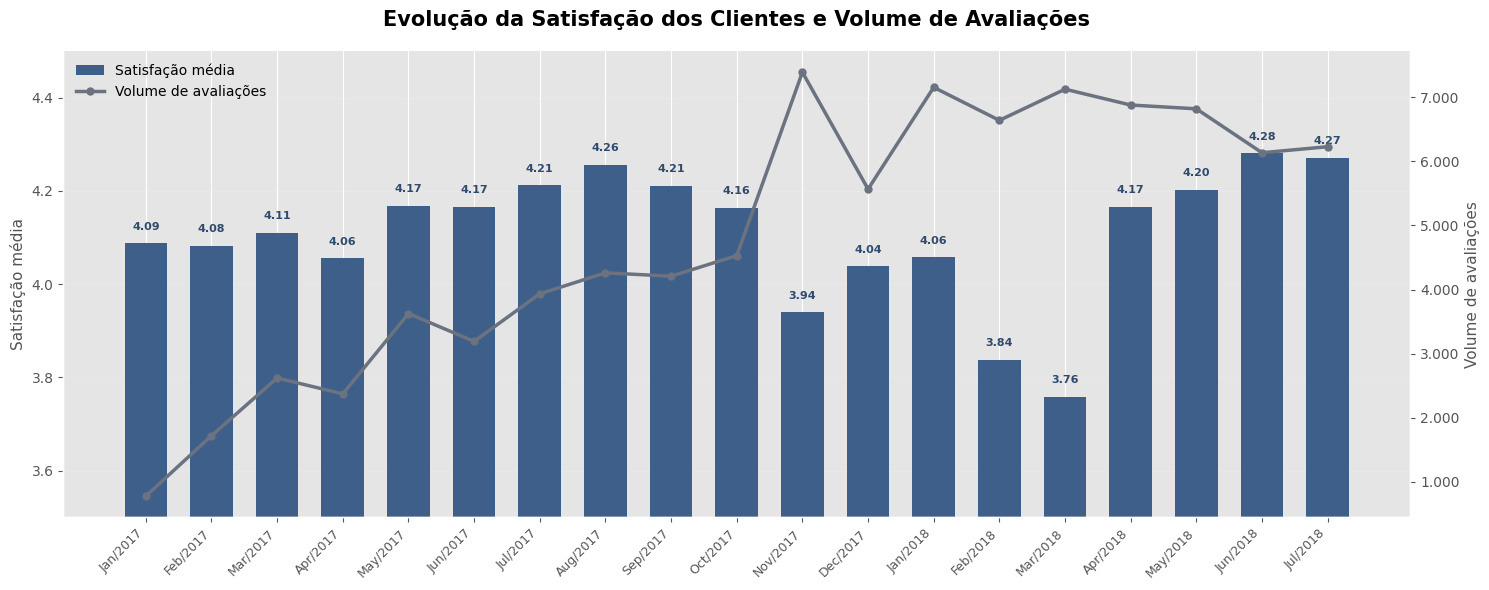

In [172]:
# ============================================================
# Evolução da Satisfação dos Clientes e Volume de Avaliações
# Período analisado: jan/2017 a jul/2018
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ============================================================
# 1. Validação das colunas necessárias
# ============================================================

colunas_necessarias = [
    "order_id",
    "review_score",
    "order_purchase_timestamp"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

# ============================================================
# 2. Preparação da base
# ============================================================

df_satisfacao = base_driver[
    [
        "order_id",
        "review_score",
        "order_purchase_timestamp"
    ]
].copy()

df_satisfacao["order_purchase_timestamp"] = pd.to_datetime(
    df_satisfacao["order_purchase_timestamp"],
    errors="coerce"
)

df_satisfacao = df_satisfacao.dropna(
    subset=[
        "order_id",
        "review_score",
        "order_purchase_timestamp"
    ]
)

# Evita duplicidade de pedido
df_satisfacao = df_satisfacao.drop_duplicates(subset=["order_id"])

# Recorte temporal consistente
df_satisfacao = df_satisfacao[
    (df_satisfacao["order_purchase_timestamp"] >= "2017-01-01") &
    (df_satisfacao["order_purchase_timestamp"] < "2018-08-01")
].copy()

# Cria ano/mês
df_satisfacao["ano_mes"] = (
    df_satisfacao["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# ============================================================
# 3. Consolidação mensal
# ============================================================

satisfacao_mensal = (
    df_satisfacao
    .groupby("ano_mes")
    .agg(
        satisfacao_media=("review_score", "mean"),
        total_avaliacoes=("review_score", "count")
    )
    .reset_index()
)

satisfacao_mensal["ano_mes_data"] = pd.to_datetime(
    satisfacao_mensal["ano_mes"]
)

satisfacao_mensal = satisfacao_mensal.sort_values("ano_mes_data")

satisfacao_mensal["ano_mes_formatado"] = (
    satisfacao_mensal["ano_mes_data"]
    .dt.strftime("%b/%Y")
)

# ============================================================
# 4. Gráfico
# ============================================================

fig, ax1 = plt.subplots(figsize=(15, 6))

x = range(len(satisfacao_mensal))

# Barras - satisfação média
barras = ax1.bar(
    x,
    satisfacao_mensal["satisfacao_media"],
    color="#3E5F8A",
    width=0.65,
    label="Satisfação média"
)

# Rótulos das barras
for barra in barras:
    altura = barra.get_height()
    ax1.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.025,
        f"{altura:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#2F4A6D",
        fontweight="bold"
    )

ax1.set_ylabel("Satisfação média", fontsize=11)
ax1.set_ylim(3.5, 4.5)

# Linha - volume de avaliações
ax2 = ax1.twinx()

ax2.plot(
    x,
    satisfacao_mensal["total_avaliacoes"],
    color="#6B7280",
    marker="o",
    linewidth=2.5,
    markersize=5,
    label="Volume de avaliações"
)

ax2.set_ylabel("Volume de avaliações", fontsize=11)

ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"{int(valor):,}".replace(",", "."))
)

# Eixo X
ax1.set_xticks(x)
ax1.set_xticklabels(
    satisfacao_mensal["ano_mes_formatado"],
    rotation=45,
    ha="right",
    fontsize=9
)

# Título
ax1.set_title(
    "Evolução da Satisfação dos Clientes e Volume de Avaliações",
    fontsize=15,
    fontweight="bold",
    pad=18
)

# Legenda
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    frameon=False,
    fontsize=10
)

# Limpeza visual
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.grid(axis="y", alpha=0.15)
ax2.grid(False)

plt.tight_layout()

# Exporta em alta qualidade
plt.savefig(
    "grafico_evolucao_satisfacao_volume_avaliacoes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [173]:
[col for col in base_driver.columns if "state" in col.lower()]

['customer_state']

In [174]:
[col for col in base_driver.columns if "customer" in col.lower()]

['customer_id',
 'order_delivered_customer_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [175]:
base_driver.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'tempo_entrega',
 'dias_atraso',
 'dias_atraso_real',
 'dias_antecipacao',
 'ano_mes']

In [176]:
# ============================================================
# Criação da coluna região
# ============================================================

mapa_regioes = {
    "AC":"Norte","AP":"Norte","AM":"Norte","PA":"Norte","RO":"Norte","RR":"Norte","TO":"Norte",

    "AL":"Nordeste","BA":"Nordeste","CE":"Nordeste","MA":"Nordeste",
    "PB":"Nordeste","PE":"Nordeste","PI":"Nordeste","RN":"Nordeste","SE":"Nordeste",

    "DF":"Centro-Oeste","GO":"Centro-Oeste","MT":"Centro-Oeste","MS":"Centro-Oeste",

    "ES":"Sudeste","MG":"Sudeste","RJ":"Sudeste","SP":"Sudeste",

    "PR":"Sul","RS":"Sul","SC":"Sul"
}

base_driver["regiao"] = (
    base_driver["customer_state"]
    .map(mapa_regioes)
)

In [177]:
# ============================================================
# Prazo médio de entrega por mês
# ============================================================

base_driver["ano_mes"] = (
    pd.to_datetime(
        base_driver["order_purchase_timestamp"]
    )
    .dt.to_period("M")
    .astype(str)
)

prazo_mensal = (
    base_driver
    .drop_duplicates(subset=["order_id"])
    .groupby("ano_mes")
    ["tempo_entrega"]
    .mean()
    .reset_index()
)

prazo_mensal

,ano_mes,tempo_entrega
0,2016-09,54.00
1,2016-10,19.11
2,2016-12,4.00
3,2017-01,12.09
4,2017-02,12.61
5,2017-03,12.40
6,2017-04,14.35
7,2017-05,10.76
8,2017-06,11.51
9,2017-07,11.13


In [178]:
mes_problema = "2018-03"

(
    base_driver[
        base_driver["ano_mes"] == mes_problema
    ]
    .groupby("product_category_name")
    ["review_score"]
    .mean()
    .sort_values()
    .head(10)
)

,review_score
product_category_name,
fraldas_higiene,2.00
cine_foto,2.50
audio,2.94
artigos_de_natal,3.00
fashion_underwear_e_moda_praia,3.00
fashion_calcados,3.25
casa_conforto,3.25
telefonia_fixa,3.33
construcao_ferramentas_iluminacao,3.42


In [179]:
# ============================================================
# % de pedidos atrasados por mês
# Base: base_driver
# Unidade: pedido
# ============================================================

import pandas as pd

df_atrasos = base_driver.copy()

# Validação das colunas necessárias
colunas_necessarias = [
    "order_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for coluna in colunas_necessarias:
    if coluna not in df_atrasos.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

# Conversão das datas
df_atrasos["order_purchase_timestamp"] = pd.to_datetime(
    df_atrasos["order_purchase_timestamp"],
    errors="coerce"
)

df_atrasos["order_delivered_customer_date"] = pd.to_datetime(
    df_atrasos["order_delivered_customer_date"],
    errors="coerce"
)

df_atrasos["order_estimated_delivery_date"] = pd.to_datetime(
    df_atrasos["order_estimated_delivery_date"],
    errors="coerce"
)

# Remove duplicidade por pedido
df_atrasos = df_atrasos.drop_duplicates(subset=["order_id"])

# Remove registros sem datas necessárias
df_atrasos = df_atrasos.dropna(
    subset=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

# Recorte temporal consistente
df_atrasos = df_atrasos[
    (df_atrasos["order_purchase_timestamp"] >= "2017-01-01") &
    (df_atrasos["order_purchase_timestamp"] < "2018-08-01")
].copy()

# Cria ano/mês
df_atrasos["ano_mes"] = (
    df_atrasos["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Cria coluna de atraso:
# atraso > 0 significa que entregou depois da data estimada
df_atrasos["dias_atraso"] = (
    df_atrasos["order_delivered_customer_date"] -
    df_atrasos["order_estimated_delivery_date"]
).dt.days

df_atrasos["pedido_atrasado"] = df_atrasos["dias_atraso"] > 0

# Consolidação mensal
atrasos_mes = (
    df_atrasos
    .groupby("ano_mes")
    .agg(
        pedidos=("order_id", "count"),
        pedidos_atrasados=("pedido_atrasado", "sum"),
        taxa_atraso=("pedido_atrasado", "mean"),
        atraso_medio=("dias_atraso", "mean")
    )
    .reset_index()
)

atrasos_mes["taxa_atraso"] = atrasos_mes["taxa_atraso"] * 100

atrasos_mes

,ano_mes,pedidos,pedidos_atrasados,taxa_atraso,atraso_medio
0,2017-01,750,22,2.93,-27.41
1,2017-02,1653,49,2.96,-19.20
2,2017-03,2546,116,4.56,-12.33
3,2017-04,2303,151,6.56,-12.97
4,2017-05,3545,106,2.99,-13.50
5,2017-06,3135,95,3.03,-12.64
6,2017-07,3872,108,2.79,-12.47
7,2017-08,4193,122,2.91,-13.10
8,2017-09,4150,182,4.39,-11.35
9,2017-10,4478,187,4.18,-11.92


In [180]:
(
    base_driver[
        base_driver["ano_mes"] == "2018-03"
    ]
    .groupby("regiao")
    ["review_score"]
    .mean()
    .sort_values()
)

,review_score
regiao,
Norte,2.94
Nordeste,3.42
Centro-Oeste,3.65
Sul,3.81
Sudeste,3.82


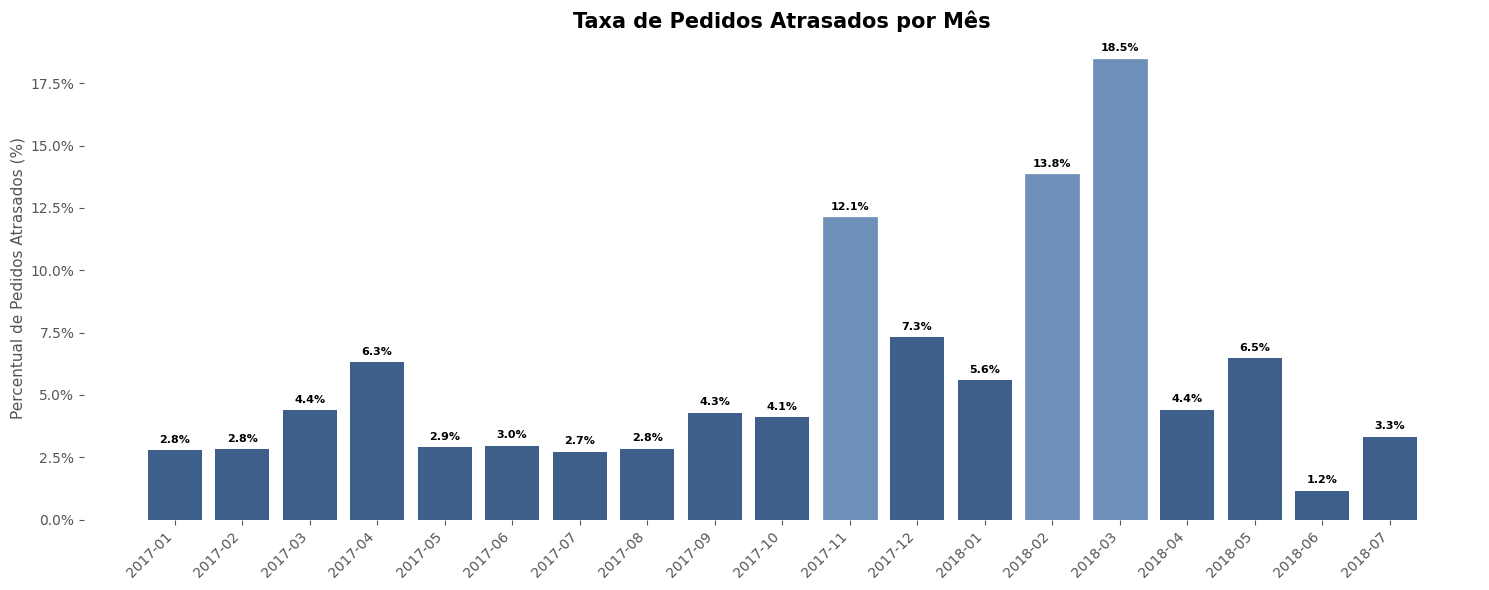

In [181]:
# ============================================================
# Taxa de Pedidos Atrasados por Mês
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ============================================================
# Validação das colunas necessárias
# ============================================================

colunas_necessarias = [
    "order_id",
    "ano_mes",
    "dias_atraso_real"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(
            f"A coluna '{coluna}' não existe em base_driver."
        )

# ============================================================
# Preparação da base
# ============================================================

df = (
    base_driver[
        [
            "order_id",
            "ano_mes",
            "dias_atraso_real"
        ]
    ]
    .drop_duplicates(subset=["order_id"])
    .copy()
)

# Mantém período consistente com o restante do projeto
df = df[
    (df["ano_mes"] >= "2017-01") &
    (df["ano_mes"] <= "2018-07")
]

# Pedido atrasado
df["pedido_atrasado"] = (
    df["dias_atraso_real"] > 0
)

# ============================================================
# Consolidação
# ============================================================

atrasos_mes = (
    df.groupby("ano_mes")
    .agg(
        pedidos=("order_id", "count"),
        pedidos_atrasados=("pedido_atrasado", "sum"),
        taxa_atraso=("pedido_atrasado", "mean")
    )
    .reset_index()
)

atrasos_mes["taxa_atraso"] = (
    atrasos_mes["taxa_atraso"] * 100
)

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(15, 6))

barras = plt.bar(
    atrasos_mes["ano_mes"],
    atrasos_mes["taxa_atraso"],
    color="#3E5F8A"
)

# Destaca os 3 piores meses
piores = ["2017-11", "2018-02", "2018-03"]

for barra, mes in zip(barras, atrasos_mes["ano_mes"]):

    if mes in piores:
        barra.set_color("#6E8FB8")

# Valores nas barras
for barra in barras:

    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.3,
        f"{altura:.1f}%",
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

# ============================================================
# Formatação
# ============================================================

plt.title(
    "Taxa de Pedidos Atrasados por Mês",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel(
    "Percentual de Pedidos Atrasados (%)",
    fontsize=11
)

plt.xlabel("")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter()
)

plt.grid(
    axis="y",
    alpha=0.20
)

plt.box(False)

plt.tight_layout()

plt.savefig(
    "grafico_taxa_atrasos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.1 - Distribuição das Avaliações dos Clientes

A satisfação dos clientes representa um dos principais indicadores da qualidade da experiência oferecida por uma plataforma de e-commerce. A análise das avaliações permite compreender como os consumidores percebem suas compras e identificar padrões de satisfação e insatisfação ao longo da base de pedidos.

A distribuição das notas atribuídas pelos clientes fornece uma visão geral da experiência de compra na Olist, evidenciando a frequência com que avaliações positivas, neutras e negativas ocorrem. Essa análise contribui para avaliar a percepção dos consumidores sobre a plataforma e identificar possíveis oportunidades de melhoria na jornada de compra.

Os resultados apresentados a seguir demonstram a distribuição das avaliações registradas pelos clientes, permitindo compreender o nível geral de satisfação observado na operação da Olist.


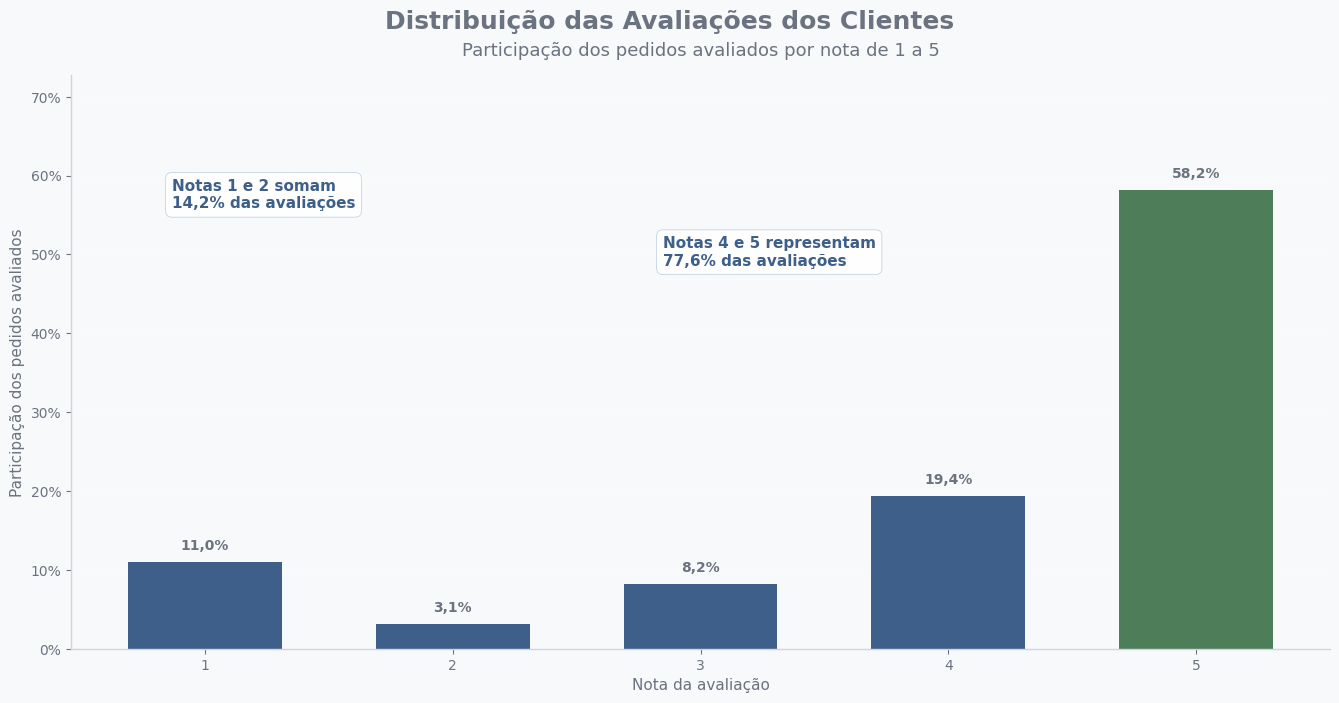

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

nota,percentual
1,11.000000
2,3.100000
3,8.200000
4,19.400000
5,58.200000


In [182]:
# ============================================================
# 7.1 - Distribuição das Avaliações dos Clientes
# Versão executiva revisada
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from google.colab import files

# ============================================================
# 1. Validação das colunas necessárias
# ============================================================

colunas_necessarias = ["order_id", "review_score"]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna obrigatória '{coluna}' não existe em base_driver.")

# ============================================================
# 2. Preparação da base
# ============================================================

df_review = (
    base_driver[["order_id", "review_score"]]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_review["review_score"] = df_review["review_score"].astype(int)

# ============================================================
# 3. Distribuição das avaliações
# ============================================================

dist_review = (
    df_review["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .reset_index()
)

dist_review.columns = ["nota", "percentual"]

avaliacoes_positivas = dist_review.loc[
    dist_review["nota"].isin([4, 5]), "percentual"
].sum()

avaliacoes_negativas = dist_review.loc[
    dist_review["nota"].isin([1, 2]), "percentual"
].sum()

# ============================================================
# 4. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(13.5, 7.2), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if nota == 5 else AZUL_EXECUTIVO
    for nota in dist_review["nota"]
]

barras = ax.bar(
    dist_review["nota"].astype(str),
    dist_review["percentual"],
    color=cores,
    width=0.62
)

# ============================================================
# 5. Título e subtítulo
# ============================================================

fig.suptitle(
    "Distribuição das Avaliações dos Clientes",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Participação dos pedidos avaliados por nota de 1 a 5",
    fontsize=13,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# 6. Rótulos das barras
# ============================================================

for barra, valor in zip(barras, dist_review["percentual"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1.2,
        f"{valor:.1f}%".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

# ============================================================
# 7. Caixas executivas
# ============================================================

ax.text(
    0.08,
    0.82,
    f"Notas 1 e 2 somam\n{avaliacoes_negativas:.1f}% das avaliações".replace(".", ","),
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.40",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

ax.text(
    0.47,
    0.72,
    f"Notas 4 e 5 representam\n{avaliacoes_positivas:.1f}% das avaliações".replace(".", ","),
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.40",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 8. Eixos e acabamento visual
# ============================================================

ax.set_xlabel("Nota da avaliação", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("Participação dos pedidos avaliados", fontsize=11, color=CINZA_EXECUTIVO)

ax.set_ylim(0, max(dist_review["percentual"]) * 1.25)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}%")
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO, labelsize=10)

plt.tight_layout()

# ============================================================
# 9. Exportação da imagem
# ============================================================

nome_arquivo = "grafico_7_1_distribuicao_avaliacoes.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# 10. Tabela executiva
# ============================================================

tabela_7_1 = dist_review.copy()
tabela_7_1["percentual"] = tabela_7_1["percentual"].round(1)

display(
    tabela_executiva(tabela_7_1)
)

### Principais Resultados Gráfico 7.1

- **58,2% das avaliações receberam nota 5**, representando a maior concentração de respostas dos clientes.
- As notas **4 e 5 somam 77,6% das avaliações**, indicando predominância de experiências positivas na plataforma.
- As avaliações negativas (notas 1 e 2) representam apenas **14,2% do total**.
- A nota 4 corresponde a **19,4% das avaliações**, reforçando a concentração de percepções favoráveis.
- A distribuição das notas apresenta forte assimetria positiva, com predominância das avaliações mais altas.

### Insight Executivo

A distribuição das avaliações demonstra que a Olist manteve um elevado nível de satisfação dos clientes durante o período analisado. A forte concentração de notas 4 e 5 sugere que a experiência de compra atendeu ou superou as expectativas da maioria dos consumidores, constituindo um ativo importante para a retenção de clientes e para a reputação do marketplace.

### Recomendação

Manter o monitoramento contínuo das avaliações e aprofundar a investigação dos fatores que diferenciam pedidos com notas altas e baixas. A próxima etapa da análise deve identificar os principais drivers de satisfação, avaliando a influência de fatores como prazo de entrega, antecipação da entrega, valor do frete e características dos pedidos.

### 7.2 - Avaliação Média por Estado

Além da distribuição geral das avaliações, é importante compreender como a percepção dos clientes varia entre os diferentes estados brasileiros. Diferenças regionais podem refletir características específicas da operação, como prazos de entrega, cobertura logística e condições de atendimento em cada mercado.

A análise da avaliação média por estado permite identificar padrões geográficos de satisfação, evidenciando regiões que apresentam melhor ou pior percepção da experiência de compra. Essa visão contribui para a compreensão das variações regionais observadas na base de clientes e auxilia na identificação de mercados que merecem atenção específica.

Os resultados apresentados a seguir demonstram a avaliação média dos clientes por estado, permitindo analisar como a satisfação se distribui geograficamente ao longo da operação da Olist.


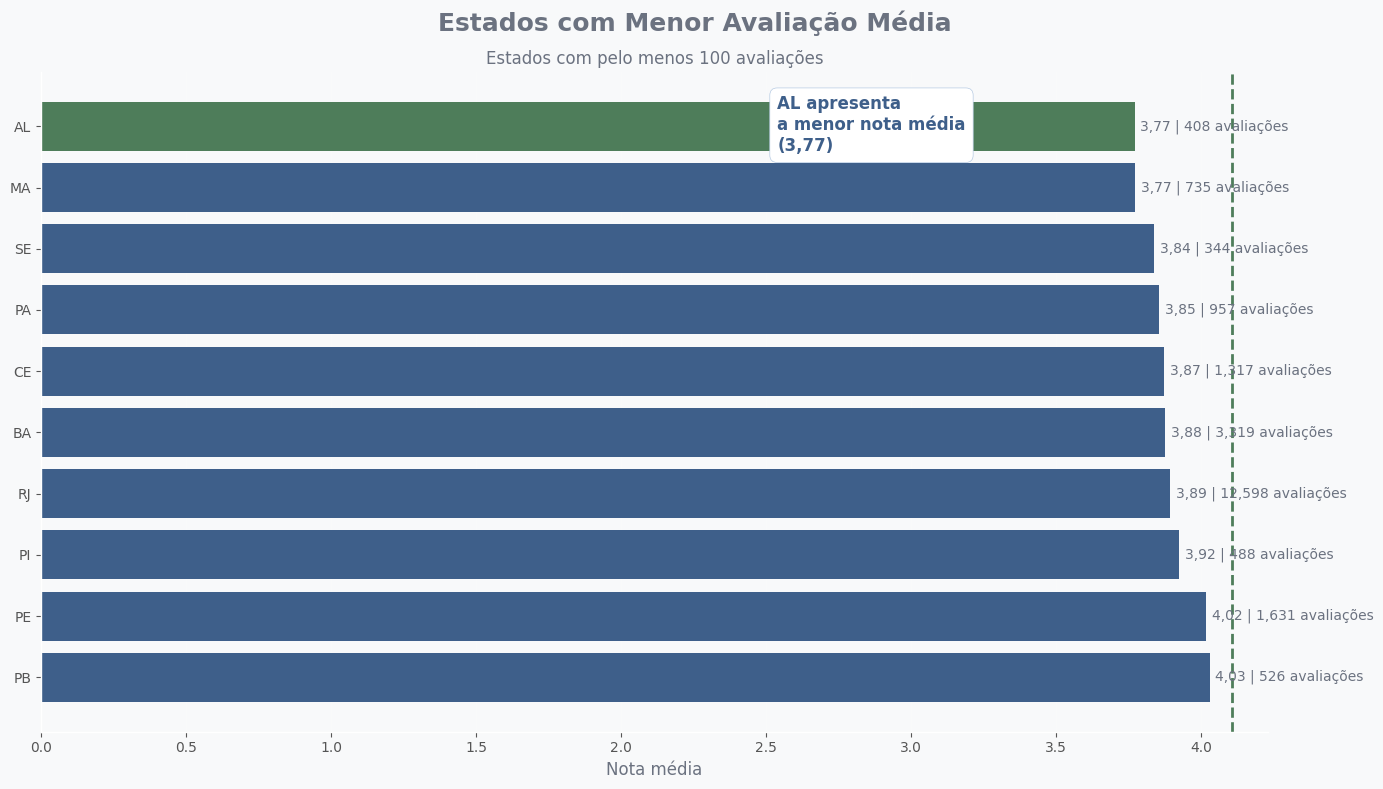

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [183]:
# ============================================================
# 7.2 - Avaliação Média por Estado
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Paleta oficial
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Validação
# ============================================================

colunas_necessarias = ["review_score", "customer_state", "order_id"]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"Coluna '{coluna}' não encontrada em base_driver.")

# ============================================================
# Preparação da base
# ============================================================

df = (
    base_driver[
        ["order_id", "customer_state", "review_score"]
    ]
    .dropna()
    .copy()
)

# Filtro mínimo para evitar estados com poucas avaliações
MIN_AVALIACOES = 100

avaliacao_estado = (
    df.groupby("customer_state", as_index=False)
      .agg(
          nota_media=("review_score", "mean"),
          qtd_avaliacoes=("order_id", "nunique")
      )
)

avaliacao_estado = (
    avaliacao_estado[
        avaliacao_estado["qtd_avaliacoes"] >= MIN_AVALIACOES
    ]
    .copy()
)

# Top 10 estados com menor avaliação média
top10 = (
    avaliacao_estado
    .sort_values("nota_media")
    .head(10)
    .copy()
)

top10_plot = top10.sort_values("nota_media")

estado_pior = top10_plot.iloc[0]["customer_state"]
nota_pior = top10_plot.iloc[0]["nota_media"]

# ============================================================
# Gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 8),
    facecolor=FUNDO_CLARO
)

ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if uf == estado_pior
    else AZUL_EXECUTIVO
    for uf in top10_plot["customer_state"]
]

barras = ax.barh(
    top10_plot["customer_state"],
    top10_plot["nota_media"],
    color=cores
)

ax.invert_yaxis()

media_geral = df["review_score"].mean()

ax.axvline(
    media_geral,
    color=VERDE_SOFISTICADO,
    linestyle="--",
    linewidth=2
)

# Rótulos

for barra, nota, qtd in zip(
    barras,
    top10_plot["nota_media"],
    top10_plot["qtd_avaliacoes"]
):
    ax.text(
        barra.get_width() + 0.02,
        barra.get_y() + barra.get_height()/2,
        f"{nota:.2f} | {qtd:,} avaliações".replace(".", ","),
        va="center",
        fontsize=10,
        color=CINZA_EXECUTIVO
    )

# Títulos

fig.suptitle(
    "Estados com Menor Avaliação Média",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO
)

ax.set_title(
    f"Estados com pelo menos {MIN_AVALIACOES} avaliações",
    fontsize=12,
    color=CINZA_EXECUTIVO
)

# Caixa executiva

ax.text(
    0.60,
    0.88,
    (
        f"{estado_pior} apresenta\n"
        f"a menor nota média\n"
        f"({nota_pior:.2f})"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO
    )
)

# Layout

ax.set_xlabel(
    "Nota média",
    color=CINZA_EXECUTIVO
)

ax.set_ylabel("")

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Exportação

nome_arquivo = "grafico_7_2_avaliacao_estado.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()

files.download(nome_arquivo)

### Principais Resultados Gráfico 7.2

- **Alagoas (AL) apresentou a menor avaliação média entre os estados analisados, com nota de 3,77**, considerando apenas estados com pelo menos 100 avaliações.
- Maranhão (MA) também registrou nota média de **3,77**, seguido por Sergipe (SE), com **3,84**.
- Estados com grande volume de avaliações, como **Rio de Janeiro (RJ)**, aparecem entre os menores desempenhos, registrando nota média de **3,89** em mais de **12 mil avaliações**.
- A diferença entre o pior estado (AL) e o melhor estado dentro deste grupo (PB) foi de aproximadamente **0,26 ponto**.
- Os resultados indicam que a satisfação dos clientes apresenta variações regionais relevantes, embora nenhuma região apresente desempenho extremamente distante das demais.

### Insight Executivo

As diferenças observadas entre os estados sugerem que a experiência do cliente não é homogênea em todo o território nacional. A presença de estados com elevado volume de avaliações entre os menores desempenhos, como o Rio de Janeiro, indica que fatores operacionais, logísticos ou estruturais podem estar influenciando a percepção dos clientes em determinadas regiões. Entretanto, a amplitude relativamente pequena entre as notas demonstra que a satisfação geral da plataforma permanece consistente.

### Recomendação

Investigar indicadores operacionais nos estados com menor avaliação média, especialmente prazo de entrega, atrasos logísticos e perfil dos pedidos, para identificar possíveis fatores associados à redução da satisfação. Essa análise servirá de base para os próximos drivers de satisfação da Seção 7.

### 7.3 - Avaliação Média por Categoria

A experiência do cliente pode variar significativamente entre diferentes categorias de produtos, uma vez que cada segmento possui características próprias relacionadas ao processo de compra, transporte, entrega e expectativas dos consumidores. Compreender essas diferenças é fundamental para identificar possíveis oportunidades de melhoria e segmentos que merecem atenção específica.

A análise da avaliação média por categoria permite comparar a percepção dos clientes entre os diversos grupos de produtos comercializados na plataforma. Essa visão contribui para identificar categorias que apresentam melhor desempenho em termos de satisfação, bem como segmentos que podem estar associados a maiores desafios operacionais ou de experiência do cliente.

Os resultados apresentados a seguir demonstram a avaliação média das categorias de produtos da Olist, permitindo identificar os segmentos mais e menos bem avaliados pelos consumidores.


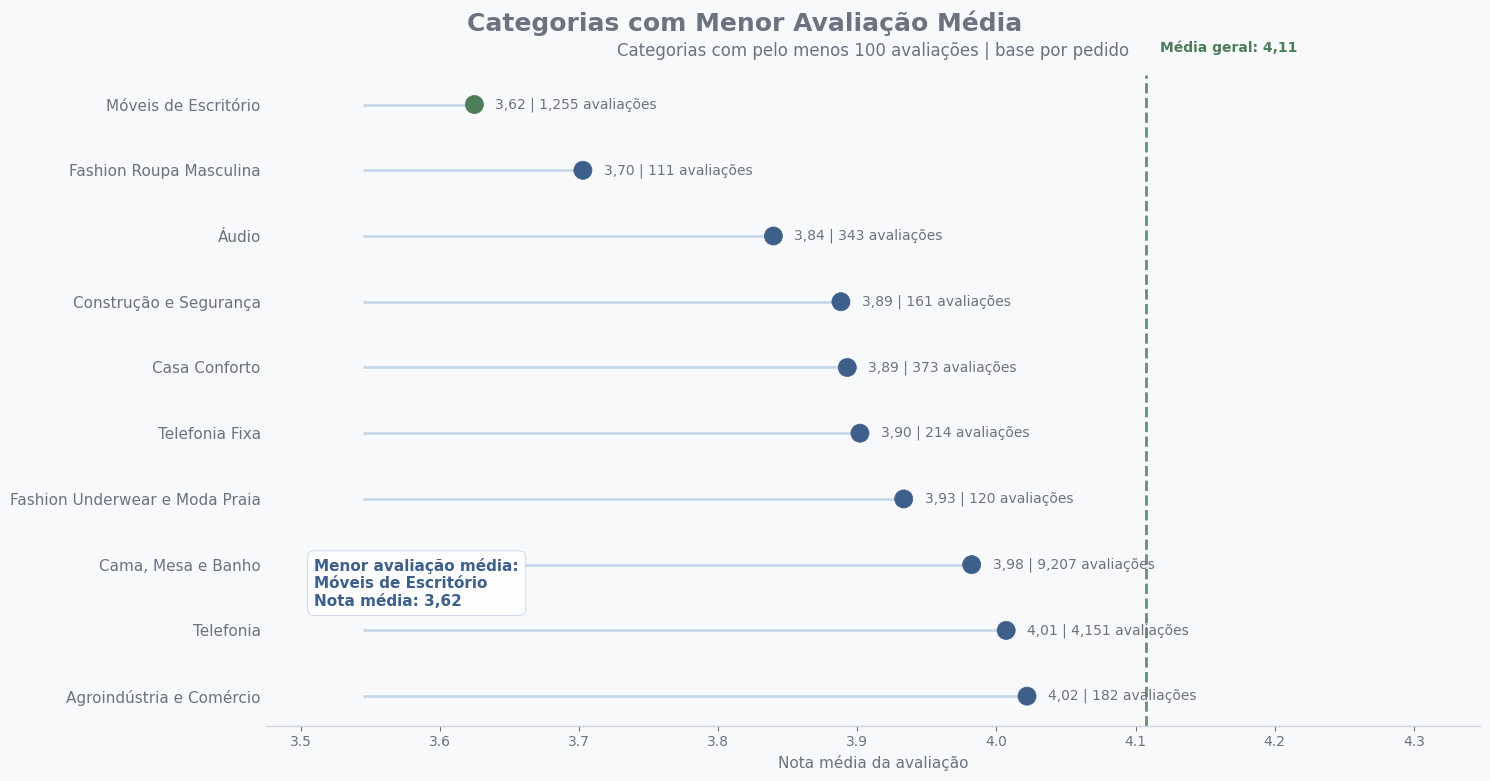

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

categoria,nota_media,qtd_avaliacoes
Móveis de Escritório,3.620000,1255
Fashion Roupa Masculina,3.700000,111
Áudio,3.840000,343
Construção e Segurança,3.890000,161
Casa Conforto,3.890000,373
Telefonia Fixa,3.900000,214
Fashion Underwear e Moda Praia,3.930000,120
"Cama, Mesa e Banho",3.980000,9207
Telefonia,4.010000,4151
Agroindústria e Comércio,4.020000,182


In [184]:
# ============================================================
# 7.3 - Avaliação Média por Categoria
# Versão final revisada em Dot Plot
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

def formatar_categoria(nome):
    nome = str(nome).replace("_", " ").replace("-", " ").strip().title()

    ajustes = {
        "Moveis Escritorio": "Móveis de Escritório",
        "Fashion Roupa Masculina": "Fashion Roupa Masculina",
        "Audio": "Áudio",
        "Construcao Ferramentas Seguranca": "Construção e Segurança",
        "Casa Conforto": "Casa Conforto",
        "Telefonia Fixa": "Telefonia Fixa",
        "Fashion Underwear E Moda Praia": "Fashion Underwear e Moda Praia",
        "Cama Mesa Banho": "Cama, Mesa e Banho",
        "Telefonia": "Telefonia",
        "Agro Industria E Comercio": "Agroindústria e Comércio"
    }

    return ajustes.get(nome, nome)

colunas_necessarias = ["product_category_name", "review_score", "order_id"]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

df_categoria = (
    base_driver[["product_category_name", "review_score", "order_id"]]
    .dropna()
    .copy()
)

df_categoria["review_score"] = df_categoria["review_score"].astype(float)

MIN_AVALIACOES = 100

avaliacao_categoria = (
    df_categoria
    .groupby("product_category_name", as_index=False)
    .agg(
        nota_media=("review_score", "mean"),
        qtd_avaliacoes=("order_id", "nunique")
    )
)

avaliacao_categoria = (
    avaliacao_categoria[
        avaliacao_categoria["qtd_avaliacoes"] >= MIN_AVALIACOES
    ]
    .copy()
)

avaliacao_categoria["categoria_formatada"] = (
    avaliacao_categoria["product_category_name"].apply(formatar_categoria)
)

top10 = (
    avaliacao_categoria
    .sort_values("nota_media", ascending=True)
    .head(10)
    .copy()
)

top10_plot = (
    top10
    .sort_values("nota_media", ascending=False)
    .reset_index(drop=True)
)

media_geral = df_categoria["review_score"].mean()
categoria_pior = top10.loc[top10["nota_media"].idxmin()]

fig, ax = plt.subplots(figsize=(15, 8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

x_inicio = top10_plot["nota_media"].min() - 0.08

for i, row in top10_plot.iterrows():
    ax.hlines(
        y=i,
        xmin=x_inicio,
        xmax=row["nota_media"],
        color=AZUL_CLARO,
        linewidth=2,
        alpha=0.75
    )

cores = [
    VERDE_SOFISTICADO if categoria == categoria_pior["categoria_formatada"]
    else AZUL_EXECUTIVO
    for categoria in top10_plot["categoria_formatada"]
]

ax.scatter(
    top10_plot["nota_media"],
    range(len(top10_plot)),
    s=170,
    color=cores,
    zorder=3
)

ax.axvline(
    media_geral,
    color=VERDE_SOFISTICADO,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

for i, row in top10_plot.iterrows():
    ax.text(
        row["nota_media"] + 0.015,
        i,
        f"{row['nota_media']:.2f} | {row['qtd_avaliacoes']:,} avaliações".replace(".", ","),
        va="center",
        ha="left",
        fontsize=10,
        color=CINZA_EXECUTIVO
    )

ax.text(
    media_geral + 0.01,
    len(top10_plot) - 0.25,
    f"Média geral: {media_geral:.2f}".replace(".", ","),
    fontsize=10,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    ha="left",
    va="bottom"
)

fig.suptitle(
    "Categorias com Menor Avaliação Média",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    f"Categorias com pelo menos {MIN_AVALIACOES} avaliações | base por pedido",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

ax.text(
    0.04,
    0.18,
    (
        f"Menor avaliação média:\n"
        f"{categoria_pior['categoria_formatada']}\n"
        f"Nota média: {categoria_pior['nota_media']:.2f}"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

ax.set_yticks(range(len(top10_plot)))
ax.set_yticklabels(
    top10_plot["categoria_formatada"],
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_xlabel("Nota média da avaliação", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("")

ax.set_xlim(
    top10_plot["nota_media"].min() - 0.15,
    max(media_geral, top10_plot["nota_media"].max()) + 0.24
)

ax.grid(axis="x", alpha=0.16)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="x", colors=CINZA_EXECUTIVO)
ax.tick_params(axis="y", colors=CINZA_EXECUTIVO, length=0)

plt.tight_layout()

nome_arquivo = "grafico_7_3_avaliacao_media_categoria_final.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

tabela_categoria = top10.copy()
tabela_categoria["nota_media"] = tabela_categoria["nota_media"].round(2)

tabela_categoria = tabela_categoria.rename(columns={
    "categoria_formatada": "categoria",
    "qtd_avaliacoes": "qtd_avaliacoes"
})

display(
    tabela_executiva(
        tabela_categoria[
            ["categoria", "nota_media", "qtd_avaliacoes"]
        ]
    )
)

### Principais Resultados Gráfico 7.3

- As categorias analisadas apresentaram notas médias entre **3,62 e 4,02**, todas abaixo da média geral da plataforma (**4,11**).
- **Móveis de Escritório** apresentou a menor avaliação média (**3,62**) entre as categorias com pelo menos 100 avaliações.
- Categorias como **Fashion Roupa Masculina**, **Áudio** e **Construção e Segurança** também apresentaram níveis de satisfação inferiores à média geral.
- Algumas categorias com elevado volume de avaliações, como **Cama, Mesa e Banho** e **Telefonia**, apresentaram notas abaixo da média da plataforma, indicando oportunidades de melhoria em segmentos relevantes para o negócio.
- As diferenças observadas sugerem que a experiência dos clientes não é uniforme entre os diferentes segmentos de produtos.

### Insight Executivo

A satisfação dos clientes varia entre categorias, indicando que determinados segmentos enfrentam desafios específicos relacionados à experiência de compra. Embora a média geral da plataforma seja elevada, algumas categorias apresentam avaliações consistentemente inferiores, o que pode representar riscos reputacionais e oportunidades de melhoria operacional.

### Recomendação

Monitorar continuamente as categorias com menor satisfação e aprofundar a investigação dos fatores associados às avaliações recebidas. A análise dos drivers de satisfação permitirá identificar se aspectos como prazo de entrega, pontualidade, frete ou valor das compras estão relacionados às diferenças observadas entre categorias.

### 7.4 - Categorias com Maior Avaliação Média

Após analisar a satisfação média entre todas as categorias de produtos, torna-se relevante destacar os segmentos que apresentaram os melhores resultados na percepção dos clientes. A identificação dessas categorias permite compreender quais experiências de compra foram mais bem avaliadas ao longo do período analisado.

As categorias com maior avaliação média representam referências positivas dentro da plataforma, evidenciando segmentos que conseguiram atender ou superar as expectativas dos consumidores. A análise desses resultados contribui para a identificação de características associadas a experiências mais satisfatórias, oferecendo uma visão complementar à análise das categorias com desempenho inferior.

Os resultados apresentados a seguir destacam as categorias com as maiores avaliações médias registradas na Olist, permitindo identificar os segmentos que mais se destacaram na percepção dos clientes.


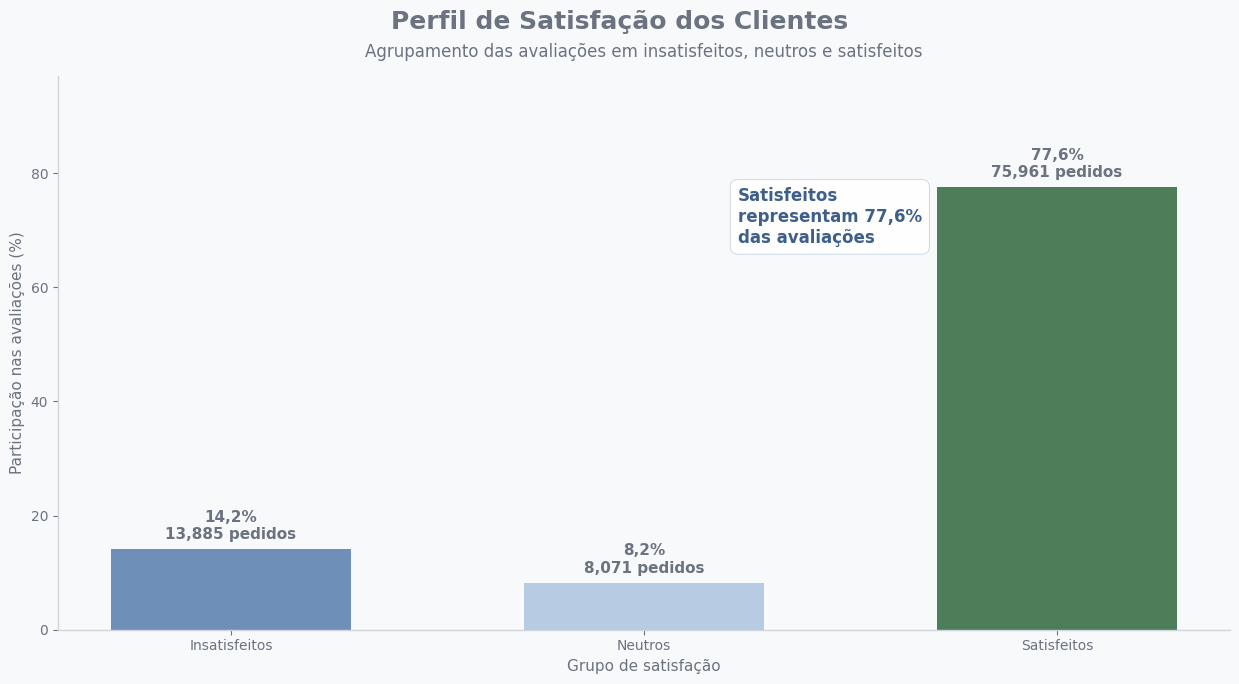

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

grupo_satisfacao,pedidos,participacao
Insatisfeitos,13885,14.200000
Neutros,8071,8.200000
Satisfeitos,75961,77.600000


In [185]:
# ============================================================
# 7.4 - Perfil de Satisfação dos Clientes
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

colunas_necessarias = ["order_id", "review_score"]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

df_satisfacao = (
    base_driver[["order_id", "review_score"]]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_satisfacao["review_score"] = df_satisfacao["review_score"].astype(int)

df_satisfacao["grupo_satisfacao"] = np.select(
    [
        df_satisfacao["review_score"].isin([1, 2]),
        df_satisfacao["review_score"].eq(3),
        df_satisfacao["review_score"].isin([4, 5])
    ],
    [
        "Insatisfeitos",
        "Neutros",
        "Satisfeitos"
    ],
    default="Não classificado"
)

perfil_satisfacao = (
    df_satisfacao
    .groupby("grupo_satisfacao", as_index=False)
    .agg(
        pedidos=("order_id", "nunique")
    )
)

perfil_satisfacao["participacao"] = (
    perfil_satisfacao["pedidos"] /
    perfil_satisfacao["pedidos"].sum()
) * 100

ordem = ["Insatisfeitos", "Neutros", "Satisfeitos"]

perfil_satisfacao["grupo_satisfacao"] = pd.Categorical(
    perfil_satisfacao["grupo_satisfacao"],
    categories=ordem,
    ordered=True
)

perfil_satisfacao = (
    perfil_satisfacao
    .sort_values("grupo_satisfacao")
    .reset_index(drop=True)
)

grupo_lider = perfil_satisfacao.loc[
    perfil_satisfacao["participacao"].idxmax()
]

cores = [
    AZUL_MEDIO if grupo == "Insatisfeitos"
    else AZUL_CLARO if grupo == "Neutros"
    else VERDE_SOFISTICADO
    for grupo in perfil_satisfacao["grupo_satisfacao"]
]

fig, ax = plt.subplots(figsize=(12.5, 7), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

barras = ax.bar(
    perfil_satisfacao["grupo_satisfacao"].astype(str),
    perfil_satisfacao["participacao"],
    color=cores,
    width=0.58
)

fig.suptitle(
    "Perfil de Satisfação dos Clientes",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Agrupamento das avaliações em insatisfeitos, neutros e satisfeitos",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

for barra, percentual, pedidos in zip(
    barras,
    perfil_satisfacao["participacao"],
    perfil_satisfacao["pedidos"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1.2,
        f"{percentual:.1f}%\n{pedidos:,} pedidos".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

ax.text(
    0.58,
    0.80,
    (
        f"{grupo_lider['grupo_satisfacao']}\n"
        f"representam {grupo_lider['participacao']:.1f}%\n"
        f"das avaliações"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

ax.set_ylabel("Participação nas avaliações (%)", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_xlabel("Grupo de satisfação", fontsize=11, color=CINZA_EXECUTIVO)

ax.set_ylim(0, perfil_satisfacao["participacao"].max() * 1.25)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

nome_arquivo = "grafico_7_4_perfil_satisfacao_clientes.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

tabela_perfil = perfil_satisfacao.copy()

tabela_perfil["participacao"] = tabela_perfil["participacao"].round(1)

display(
    tabela_executiva(
        tabela_perfil[
            ["grupo_satisfacao", "pedidos", "participacao"]
        ]
    )
)

### Principais Resultados Gráfico 7.4

- A maior parte das avaliações está concentrada no grupo de **clientes satisfeitos**, formado por notas 4 e 5.
- O grupo de **clientes insatisfeitos**, composto por notas 1 e 2, representa a parcela de maior atenção para a gestão da experiência.
- As avaliações neutras, representadas pela nota 3, indicam clientes com percepção intermediária da experiência de compra.
- A segmentação por grupos facilita a leitura executiva da satisfação em comparação à análise isolada das notas de 1 a 5.

### Insight Executivo

O agrupamento das avaliações mostra que a plataforma possui uma base relevante de clientes satisfeitos, mas também evidencia a existência de um grupo de clientes em risco. Essa leitura é importante porque transforma as notas individuais em grupos de decisão, permitindo compreender melhor o tamanho da satisfação e da insatisfação dentro da base.

### Recomendação

Utilizar o perfil de satisfação como indicador executivo de acompanhamento da experiência do cliente. A partir dessa visão, a próxima etapa deve investigar os fatores associados à insatisfação, especialmente prazo de entrega, pontualidade, frete e valor do pedido.

### 7.5 - Evolução Mensal da Avaliação Média

Além de compreender a distribuição geral das avaliações, é importante analisar como a satisfação dos clientes evoluiu ao longo do tempo. Em plataformas digitais em crescimento, acompanhar a percepção dos consumidores permite avaliar se a expansão da operação foi acompanhada pela manutenção da qualidade da experiência oferecida.

A análise da evolução mensal da avaliação média contribui para identificar tendências de melhoria, estabilidade ou redução da satisfação dos clientes durante o período analisado. Essa perspectiva temporal complementa as análises anteriores, permitindo observar como a percepção dos consumidores se comportou diante das mudanças ocorridas na operação e no volume de pedidos da plataforma.

Os resultados apresentados a seguir demonstram a evolução da avaliação média ao longo dos meses, permitindo avaliar a consistência da experiência oferecida pela Olist durante seu processo de crescimento.


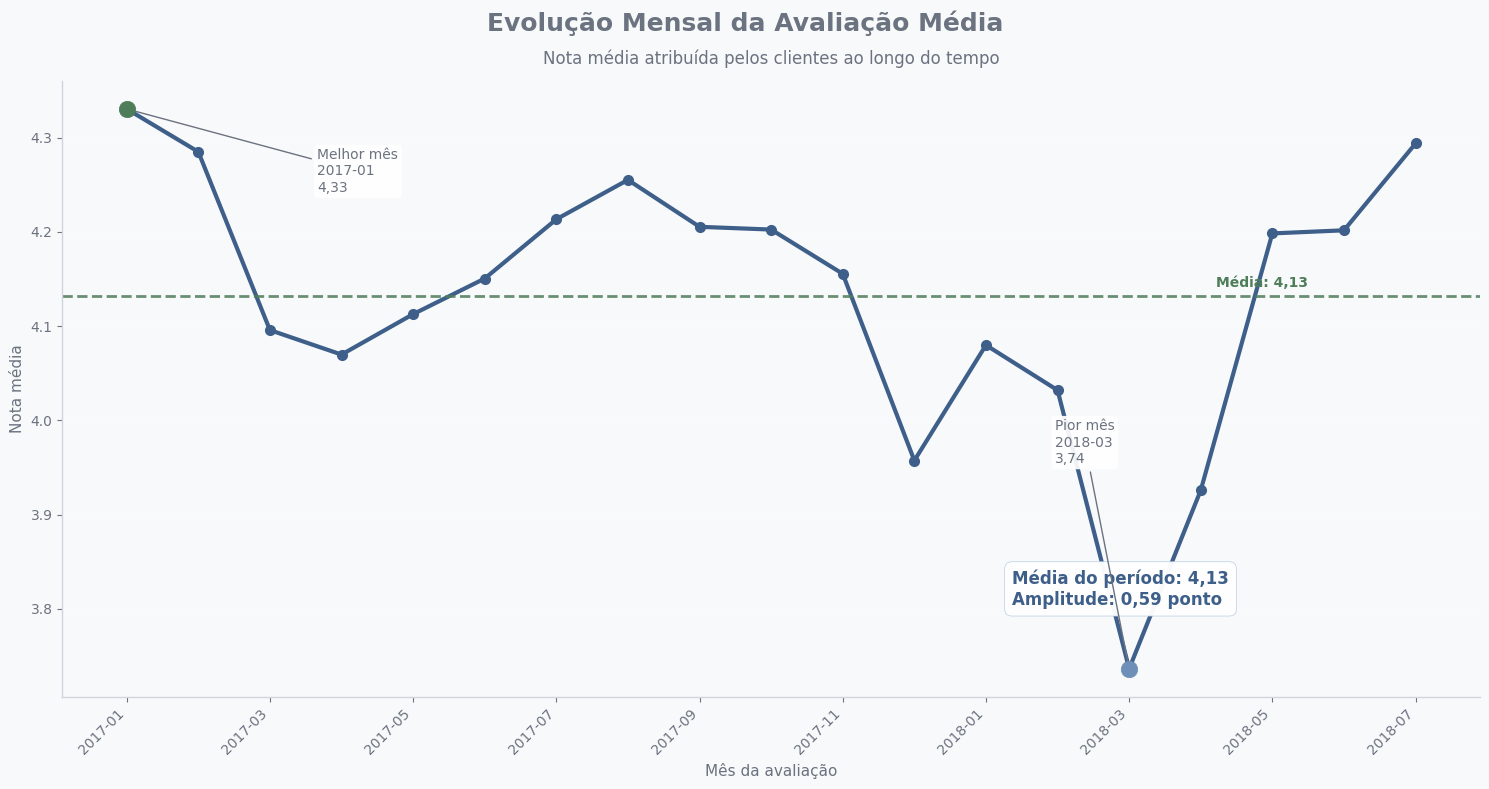

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ano_mes,nota_media,pedidos
2017-01,4.330000,236
2017-02,4.280000,1400
2017-03,4.100000,2402
2017-04,4.070000,2021
2017-05,4.110000,3665
2017-06,4.150000,3362
2017-07,4.210000,3435
2017-08,4.260000,4412
2017-09,4.210000,4124
2017-10,4.200000,4361


In [186]:
# ============================================================
# 7.5 - Evolução Mensal da Avaliação Média
# Base: base_driver
# Unidade de análise: pedido
# Versão Executiva Ajustada
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Paleta Oficial
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Validação
# ============================================================

colunas_necessarias = [
    "review_score",
    "review_creation_date",
    "order_id"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(
            f"A coluna '{coluna}' não existe em base_driver."
        )

# ============================================================
# Preparação
# ============================================================

df = (
    base_driver[
        [
            "order_id",
            "review_score",
            "review_creation_date"
        ]
    ]
    .dropna()
    .copy()
)

df["review_creation_date"] = pd.to_datetime(
    df["review_creation_date"],
    errors="coerce"
)

df["ano_mes"] = (
    df["review_creation_date"]
    .dt.to_period("M")
    .astype(str)
)

df = df.dropna(subset=["ano_mes"])

# ============================================================
# Recorte temporal oficial
# ============================================================

df = df[
    (df["ano_mes"] >= "2017-01") &
    (df["ano_mes"] <= "2018-07")
].copy()

# ============================================================
# Avaliação média mensal
# ============================================================

avaliacao_mensal = (
    df.groupby("ano_mes", as_index=False)
      .agg(
          nota_media=("review_score", "mean"),
          pedidos=("order_id", "nunique")
      )
      .sort_values("ano_mes")
)

avaliacao_mensal["x_pos"] = range(len(avaliacao_mensal))

# ============================================================
# Indicadores executivos
# ============================================================

media_periodo = (
    avaliacao_mensal["nota_media"]
    .mean()
)

melhor_mes = avaliacao_mensal.loc[
    avaliacao_mensal["nota_media"].idxmax()
]

pior_mes = avaliacao_mensal.loc[
    avaliacao_mensal["nota_media"].idxmin()
]

amplitude = (
    melhor_mes["nota_media"] -
    pior_mes["nota_media"]
)

# ============================================================
# Construção do gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 8),
    facecolor=FUNDO_CLARO
)

ax.set_facecolor(FUNDO_CLARO)

ax.plot(
    avaliacao_mensal["x_pos"],
    avaliacao_mensal["nota_media"],
    color=AZUL_EXECUTIVO,
    linewidth=3,
    marker="o",
    markersize=7
)

# ============================================================
# Linha média
# ============================================================

ax.axhline(
    media_periodo,
    color=VERDE_SOFISTICADO,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

# ============================================================
# Destaques
# ============================================================

ax.scatter(
    melhor_mes["x_pos"],
    melhor_mes["nota_media"],
    color=VERDE_SOFISTICADO,
    s=140,
    zorder=5
)

ax.scatter(
    pior_mes["x_pos"],
    pior_mes["nota_media"],
    color=AZUL_MEDIO,
    s=140,
    zorder=5
)

# ============================================================
# Títulos
# ============================================================

fig.suptitle(
    "Evolução Mensal da Avaliação Média",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO
)

ax.set_title(
    "Nota média atribuída pelos clientes ao longo do tempo",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=12
)

# ============================================================
# Caixa executiva
# ============================================================

ax.text(
    0.67,
    0.15,
    (
        f"Média do período: {media_periodo:.2f}\n"
        f"Amplitude: {amplitude:.2f} ponto"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# Melhor mês
# ============================================================

ax.annotate(
    (
        f"Melhor mês\n"
        f"{melhor_mes['ano_mes']}\n"
        f"{melhor_mes['nota_media']:.2f}"
    ).replace(".", ","),
    xy=(
        melhor_mes["x_pos"],
        melhor_mes["nota_media"]
    ),
    xytext=(0.18, 0.82),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=BRANCO,
        edgecolor="none",
        alpha=0.92
    ),
    arrowprops=dict(
        arrowstyle="-",
        color=CINZA_EXECUTIVO,
        lw=1
    )
)

# ============================================================
# Pior mês
# ============================================================

ax.annotate(
    (
        f"Pior mês\n"
        f"{pior_mes['ano_mes']}\n"
        f"{pior_mes['nota_media']:.2f}"
    ).replace(".", ","),
    xy=(
        pior_mes["x_pos"],
        pior_mes["nota_media"]
    ),
    xytext=(0.70, 0.38),
    textcoords="axes fraction",
    fontsize=10,
    color=CINZA_EXECUTIVO,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=BRANCO,
        edgecolor="none",
        alpha=0.92
    ),
    arrowprops=dict(
        arrowstyle="-",
        color=CINZA_EXECUTIVO,
        lw=1
    )
)

# ============================================================
# Média
# ============================================================

ax.text(
    avaliacao_mensal["x_pos"].max() - 1.5,
    media_periodo + 0.01,
    f"Média: {media_periodo:.2f}".replace(".", ","),
    fontsize=10,
    fontweight="bold",
    color=VERDE_SOFISTICADO,
    ha="right"
)

# ============================================================
# Layout
# ============================================================

ax.set_ylabel(
    "Nota média",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_xlabel(
    "Mês da avaliação",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_xticks(
    avaliacao_mensal["x_pos"][::2]
)

ax.set_xticklabels(
    avaliacao_mensal["ano_mes"][::2],
    rotation=45,
    ha="right"
)

ax.set_ylim(
    avaliacao_mensal["nota_media"].min() - 0.03,
    avaliacao_mensal["nota_media"].max() + 0.03
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(
    axis="both",
    colors=CINZA_EXECUTIVO
)

plt.tight_layout()

# ============================================================
# Exportação
# ============================================================

nome_arquivo = "grafico_7_5_evolucao_avaliacao_media.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()

files.download(nome_arquivo)

# ============================================================
# Tabela executiva
# ============================================================

tabela_resultado = avaliacao_mensal.copy()

tabela_resultado["nota_media"] = (
    tabela_resultado["nota_media"]
    .round(2)
)

display(
    tabela_executiva(
        tabela_resultado[
            [
                "ano_mes",
                "nota_media",
                "pedidos"
            ]
        ]
    )
)

### Principais Resultados Gráfico 7.5

- A avaliação média dos clientes permaneceu relativamente estável ao longo do período analisado.
- A satisfação oscilou entre **3,74 e 4,33**, mantendo-se próxima da média geral de **4,13**.
- O melhor resultado ocorreu em **jan/2017**, com nota média de **4,33**.
- O menor resultado foi observado em **mar/2018**, com nota média de **3,74**.
- Mesmo durante o forte crescimento operacional da plataforma, a satisfação dos clientes permaneceu em níveis elevados.

### Insight Executivo

Os resultados indicam que a Olist conseguiu sustentar níveis elevados de satisfação mesmo diante do crescimento expressivo da operação. A estabilidade observada ao longo do período sugere que a expansão da plataforma não comprometeu significativamente a experiência percebida pelos clientes, fator relevante para a sustentabilidade do crescimento no longo prazo.

### Recomendação

Monitorar continuamente a evolução da satisfação dos clientes em conjunto com indicadores de crescimento, logística e desempenho operacional. A manutenção de avaliações médias superiores a 4 pontos representa uma vantagem competitiva importante para a retenção de clientes e para a atratividade do marketplace perante investidores.


### 7.6 - Promotores, Neutros e Detratores por Região

Além da análise da avaliação média, é importante compreender como os diferentes perfis de satisfação estão distribuídos entre as regiões do país. A segmentação dos clientes em promotores, neutros e detratores permite uma visão mais detalhada da experiência percebida, evidenciando diferenças que podem não ser totalmente capturadas pela nota média isoladamente.

A análise da distribuição desses grupos por região contribui para identificar padrões geográficos de satisfação, destacando mercados com maior concentração de clientes engajados e regiões que apresentam maior risco de insatisfação. Essa abordagem amplia a compreensão das diferenças regionais observadas na operação e auxilia na identificação de oportunidades de melhoria da experiência do cliente.

Os resultados apresentados a seguir demonstram a composição de promotores, neutros e detratores nas diferentes regiões brasileiras, permitindo avaliar como a satisfação dos clientes se distribui geograficamente na plataforma.


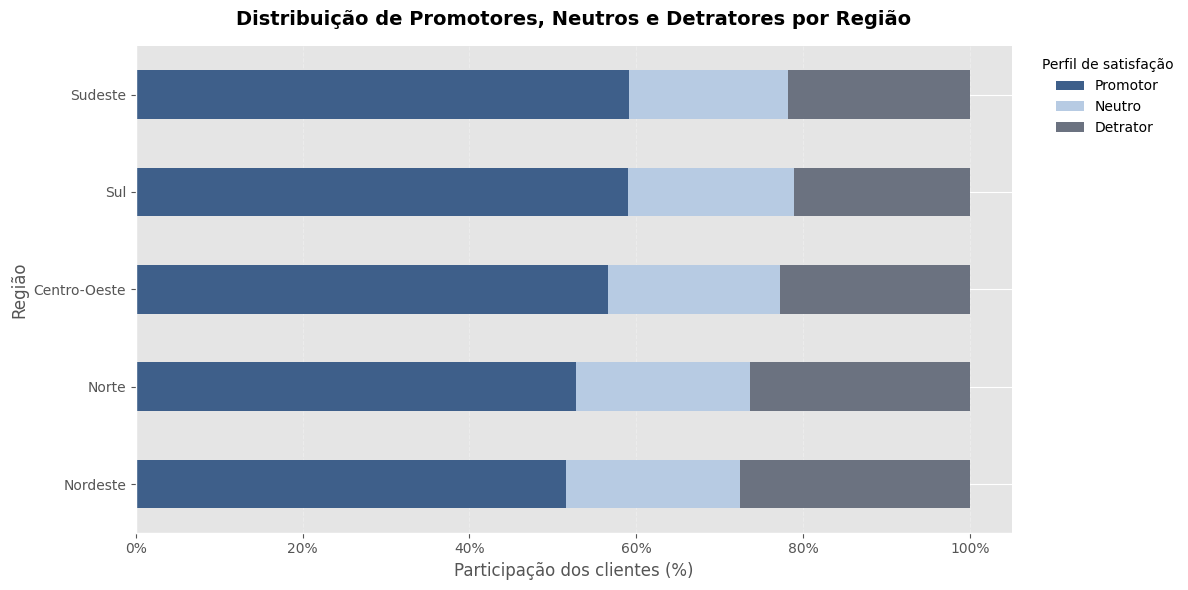

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [187]:
# ============================================================
# 7.6 - Promotores, Neutros e Detratores por Região
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ============================================================
# Validação das colunas necessárias
# ============================================================

colunas_necessarias = [
    "order_id",
    "customer_state",
    "review_score"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(
            f"A coluna '{coluna}' não existe em base_driver."
        )

# ============================================================
# Mapeamento dos estados brasileiros para regiões
# ============================================================

mapa_regioes = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte",
    "RO": "Norte", "RR": "Norte", "TO": "Norte",

    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste",
    "MA": "Nordeste", "PB": "Nordeste", "PE": "Nordeste",
    "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",

    "DF": "Centro-Oeste", "GO": "Centro-Oeste",
    "MT": "Centro-Oeste", "MS": "Centro-Oeste",

    "ES": "Sudeste", "MG": "Sudeste",
    "RJ": "Sudeste", "SP": "Sudeste",

    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

# ============================================================
# Preparação da base
# Mantém uma linha por pedido para evitar duplicidade por itens
# ============================================================

df_nps_regiao = (
    base_driver[
        ["order_id", "customer_state", "review_score"]
    ]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_nps_regiao["regiao"] = (
    df_nps_regiao["customer_state"]
    .map(mapa_regioes)
)

# ============================================================
# Classificação dos clientes
# Padrão do projeto:
# Detrator: notas 1, 2 e 3
# Neutro: nota 4
# Promotor: nota 5
# ============================================================

def classificar_satisfacao(nota):
    if nota in [1, 2, 3]:
        return "Detrator"
    elif nota == 4:
        return "Neutro"
    else:
        return "Promotor"

df_nps_regiao["grupo_satisfacao"] = (
    df_nps_regiao["review_score"]
    .astype(int)
    .apply(classificar_satisfacao)
)

# ============================================================
# Tabela percentual por região
# ============================================================

tabela_nps_regiao = (
    pd.crosstab(
        df_nps_regiao["regiao"],
        df_nps_regiao["grupo_satisfacao"],
        normalize="index"
    ) * 100
)

# Garante a ordem das colunas no gráfico
ordem_colunas = ["Promotor", "Neutro", "Detrator"]

for coluna in ordem_colunas:
    if coluna not in tabela_nps_regiao.columns:
        tabela_nps_regiao[coluna] = 0

tabela_nps_regiao = tabela_nps_regiao[ordem_colunas]

# Ordena pela maior participação de promotores
tabela_nps_regiao = (
    tabela_nps_regiao
    .sort_values(
        by="Promotor",
        ascending=True
    )
)

# ============================================================
# Visualização - Barras empilhadas 100%
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

cores = {
    "Promotor": "#3E5F8A",
    "Neutro": "#B7CBE3",
    "Detrator": "#6B7280"
}

tabela_nps_regiao.plot(
    kind="barh",
    stacked=True,
    color=[cores[coluna] for coluna in ordem_colunas],
    ax=ax
)

ax.set_title(
    "Distribuição de Promotores, Neutros e Detratores por Região",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Participação dos clientes (%)")
ax.set_ylabel("Região")

ax.xaxis.set_major_formatter(PercentFormatter())

ax.legend(
    title="Perfil de satisfação",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

nome_arquivo = "grafico_7_6_promotores_neutros_detratores_regiao.png"
plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

plt.show()
files.download(nome_arquivo)

### Principais Resultados Gráfico 7.6

- A distribuição de promotores, neutros e detratores apresenta diferenças moderadas entre as regiões brasileiras.
- Sul e Sudeste registram as maiores participações de promotores, enquanto Norte e Nordeste apresentam proporção relativamente maior de detratores.
- Apesar das diferenças não serem extremas, o padrão regional observado é consistente com os resultados de satisfação média e desempenho logístico analisados anteriormente.

### Insight Executivo

Os resultados reforçam que a experiência do cliente varia entre as regiões do país. Regiões com melhores indicadores logísticos tendem a concentrar maior participação de clientes promotores, enquanto regiões com maiores desafios operacionais apresentam proporção relativamente maior de detratores.

### Recomendação

Monitorar continuamente os indicadores de satisfação por região e priorizar melhorias logísticas nas localidades com maior participação de detratores, buscando aumentar a consistência da experiência do cliente em todo o território nacional.

# Conclusão da Seção 7 — Satisfação dos Clientes

A análise do perfil de satisfação demonstra que a Olist possui uma base predominantemente satisfeita, com forte concentração de avaliações positivas ao longo do período analisado. A distribuição das notas evidencia que a maior parte dos clientes atribuiu avaliações elevadas à experiência de compra, reforçando a percepção positiva da plataforma.

As análises por categoria mostram que a satisfação não é uniforme entre os produtos comercializados, indicando oportunidades específicas de melhoria em segmentos com desempenho inferior. Da mesma forma, a avaliação média por estado e a distribuição regional de promotores, neutros e detratores revelam diferenças geográficas relevantes na experiência dos consumidores.

Embora as diferenças regionais não sejam extremas, observa-se um padrão consistente: regiões com melhores indicadores operacionais tendem a apresentar maior participação de clientes promotores e melhores níveis de satisfação. Esse resultado sugere que fatores relacionados à experiência de entrega e ao contexto operacional podem influenciar a percepção dos consumidores.

De forma geral, os resultados indicam que a Olist mantém níveis elevados de satisfação, mas que existem oportunidades para aumentar a consistência da experiência entre regiões e categorias de produtos. Para investidores e gestores, o monitoramento contínuo da satisfação representa um importante instrumento para preservação da reputação da plataforma, fidelização de clientes e sustentação do crescimento no longo prazo.

#  8 - Análise Diagnóstica dos Drivers de Satisfação

Após compreender o comportamento da satisfação dos clientes e os principais indicadores da experiência de compra, a próxima etapa consiste em investigar quais fatores estão mais associados às avaliações atribuídas pelos consumidores.

Enquanto as análises anteriores tiveram caráter predominantemente descritivo, esta seção possui natureza diagnóstica e busca identificar padrões, relações e evidências que auxiliem na compreensão dos principais fatores que influenciam a satisfação dos clientes.

O objetivo é transformar observações descritivas em conhecimento acionável, permitindo identificar quais aspectos da operação possuem maior potencial de impactar positivamente a experiência dos consumidores.

As análises desta seção servirão como base para a construção das recomendações estratégicas apresentadas ao final do projeto.

### 8.1 - Matriz de Correlação dos Drivers de Satisfação

As análises realizadas até este ponto permitiram identificar possíveis relações entre diferentes aspectos da experiência de compra e a satisfação dos clientes. No entanto, para compreender essas associações de forma integrada, é necessário avaliar simultaneamente os principais fatores relacionados à logística, aos valores financeiros e ao comportamento dos pedidos.

A matriz de correlação permite mensurar o grau de associação entre as variáveis analisadas, indicando quais fatores apresentam relações mais fortes ou mais fracas com as avaliações atribuídas pelos consumidores. Essa abordagem contribui para identificar os potenciais drivers da satisfação e fornece uma visão consolidada dos elementos que podem influenciar a percepção dos clientes sobre a experiência de compra.

Os resultados apresentados a seguir demonstram as correlações entre os principais indicadores da operação e a nota de avaliação dos clientes, permitindo identificar quais fatores apresentam maior associação com a satisfação observada na plataforma.


variável,Avaliação,Tempo de Entrega,Atraso,Valor do Pedido,Frete
Avaliação,1.000000,-0.330000,-0.270000,-0.010000,-0.040000
Tempo de Entrega,-0.330000,1.000000,0.600000,0.060000,0.210000
Atraso,-0.270000,0.600000,1.000000,-0.010000,-0.050000
Valor do Pedido,-0.010000,0.060000,-0.010000,1.000000,0.420000
Frete,-0.040000,0.210000,-0.050000,0.420000,1.000000


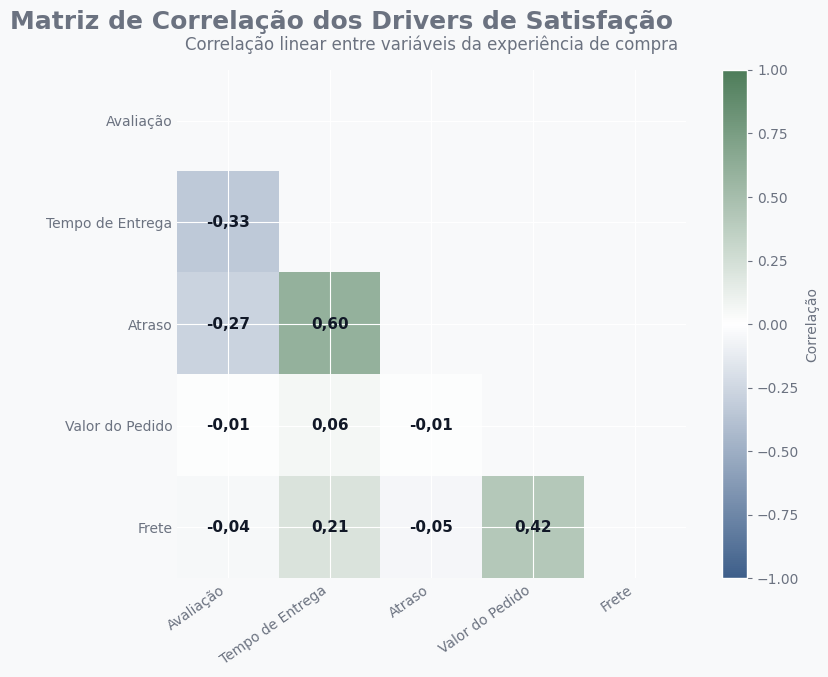

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

driver,correlacao
Tempo de Entrega,-0.330000
Atraso,-0.270000
Frete,-0.040000
Valor do Pedido,-0.010000


In [188]:
# ============================================================
# 8.1 - Matriz de Correlação dos Drivers de Satisfação
# Versão ajustada: matriz triangular inferior
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from google.colab import files

# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# 1. Validação da base
# ============================================================

if "base_driver" not in globals():
    raise NameError("A base 'base_driver' não existe.")

if "tabela_executiva" not in globals():
    raise NameError("A função 'tabela_executiva()' não existe.")

# ============================================================
# 2. Seleção das variáveis
# ============================================================

variaveis_correlacao = [
    "review_score",
    "tempo_entrega",
    "dias_atraso",
    "price",
    "freight_value"
]

for coluna in variaveis_correlacao:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna obrigatória '{coluna}' não existe em base_driver.")

df_corr = (
    base_driver[variaveis_correlacao]
    .dropna()
    .copy()
)

# ============================================================
# 3. Cálculo da matriz de correlação
# ============================================================

matriz_corr = df_corr.corr(method="pearson").round(2)

nomes_executivos = {
    "review_score": "Avaliação",
    "tempo_entrega": "Tempo de Entrega",
    "dias_atraso": "Atraso",
    "price": "Valor do Pedido",
    "freight_value": "Frete"
}

matriz_corr_exec = matriz_corr.rename(
    index=nomes_executivos,
    columns=nomes_executivos
)

display(
    tabela_executiva(
        matriz_corr_exec.reset_index().rename(columns={"index": "variável"})
    )
)

# ============================================================
# 4. Máscara triangular superior
# ============================================================

mascara = np.triu(
    np.ones_like(matriz_corr_exec, dtype=bool)
)

matriz_plot = matriz_corr_exec.mask(mascara)

# ============================================================
# 5. Mapa de cores oficial
# ============================================================
# Azul = correlação negativa
# Branco = correlação próxima de zero
# Verde = correlação positiva

cmap_correlacao = LinearSegmentedColormap.from_list(
    "correlacao_oficial",
    [AZUL_EXECUTIVO, BRANCO, VERDE_SOFISTICADO]
)

# ============================================================
# 6. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

imagem = ax.imshow(
    matriz_plot,
    cmap=cmap_correlacao,
    vmin=-1,
    vmax=1
)

# ============================================================
# 7. Eixos
# ============================================================

ax.set_xticks(range(len(matriz_corr_exec.columns)))
ax.set_xticklabels(
    matriz_corr_exec.columns,
    rotation=35,
    ha="right",
    fontsize=10,
    color=CINZA_EXECUTIVO
)

ax.set_yticks(range(len(matriz_corr_exec.index)))
ax.set_yticklabels(
    matriz_corr_exec.index,
    fontsize=10,
    color=CINZA_EXECUTIVO
)

# ============================================================
# 8. Valores nas células
# ============================================================

for i in range(len(matriz_corr_exec.index)):
    for j in range(len(matriz_corr_exec.columns)):

        if mascara[i, j]:
            continue

        valor = matriz_corr_exec.iloc[i, j]

        ax.text(
            j,
            i,
            f"{valor:.2f}".replace(".", ","),
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="#111827"
        )

# ============================================================
# 9. Títulos
# ============================================================

fig.suptitle(
    "Matriz de Correlação dos Drivers de Satisfação",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.96
)

ax.set_title(
    "Correlação linear entre variáveis da experiência de compra",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# 10. Barra de referência
# ============================================================

cbar = plt.colorbar(imagem, ax=ax, fraction=0.046, pad=0.04)

cbar.set_label(
    "Correlação",
    fontsize=10,
    color=CINZA_EXECUTIVO
)

cbar.ax.tick_params(colors=CINZA_EXECUTIVO)

# ============================================================
# 11. Acabamento visual
# ============================================================

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

plt.tight_layout()

# ============================================================
# 12. Exportação
# ============================================================

nome_arquivo = "grafico_8_1_matriz_correlacao_drivers_satisfacao.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# 13. Ranking auxiliar das correlações com satisfação
# ============================================================

ranking_drivers = (
    matriz_corr["review_score"]
    .drop("review_score")
    .sort_values(key=lambda x: abs(x), ascending=False)
    .reset_index()
)

ranking_drivers.columns = ["driver", "correlacao"]

ranking_drivers["driver"] = ranking_drivers["driver"].map(nomes_executivos)

display(
    tabela_executiva(
        ranking_drivers
    )
)

### Principais Resultados Gráfico 8.1

- O **tempo de entrega apresentou a maior correlação com a satisfação dos clientes**, com coeficiente de **-0,33**.
- O **atraso na entrega apresentou a segunda maior correlação**, com coeficiente de **-0,27**.
- O **valor do pedido apresentou correlação praticamente nula com a satisfação**, com coeficiente de **-0,01**.
- O **valor do frete também apresentou baixa associação com a avaliação dos clientes**, com correlação de **-0,04**.
- Foi observada correlação positiva de **0,60** entre tempo de entrega e atraso, indicando forte relação entre demora operacional e descumprimento do prazo prometido.

### Insight Executivo

Os resultados indicam que a satisfação dos clientes está significativamente mais associada à experiência logística do que aos fatores financeiros da compra. Tempo de entrega e atraso foram os fatores com maior relação com as avaliações, enquanto preço e frete demonstraram influência muito limitada na percepção dos consumidores.

### Recomendação

Priorizar iniciativas voltadas à redução do tempo de entrega e ao cumprimento dos prazos prometidos. Os resultados sugerem que melhorias logísticas possuem maior potencial de elevar a satisfação dos clientes do que ações focadas exclusivamente em preço ou frete.

### 8.2 - Ranking dos Drivers de Satisfação

Após analisar as correlações entre os principais fatores da experiência de compra e a satisfação dos clientes, torna-se importante organizar esses resultados de forma a facilitar sua interpretação e priorização. Nem todas as variáveis apresentam o mesmo nível de associação com as avaliações, tornando necessário identificar quais fatores possuem maior relevância potencial para a experiência dos consumidores.

O ranking dos drivers de satisfação permite comparar a intensidade das correlações observadas e destacar os fatores que apresentam maior associação com a nota atribuída pelos clientes. Essa abordagem transforma os resultados estatísticos em uma visão mais executiva, facilitando a identificação dos aspectos que merecem maior atenção na busca por melhorias na experiência de compra.

Os resultados apresentados a seguir demonstram o posicionamento dos principais drivers de satisfação, permitindo identificar os fatores com maior potencial de influência sobre a percepção dos clientes em relação à plataforma.


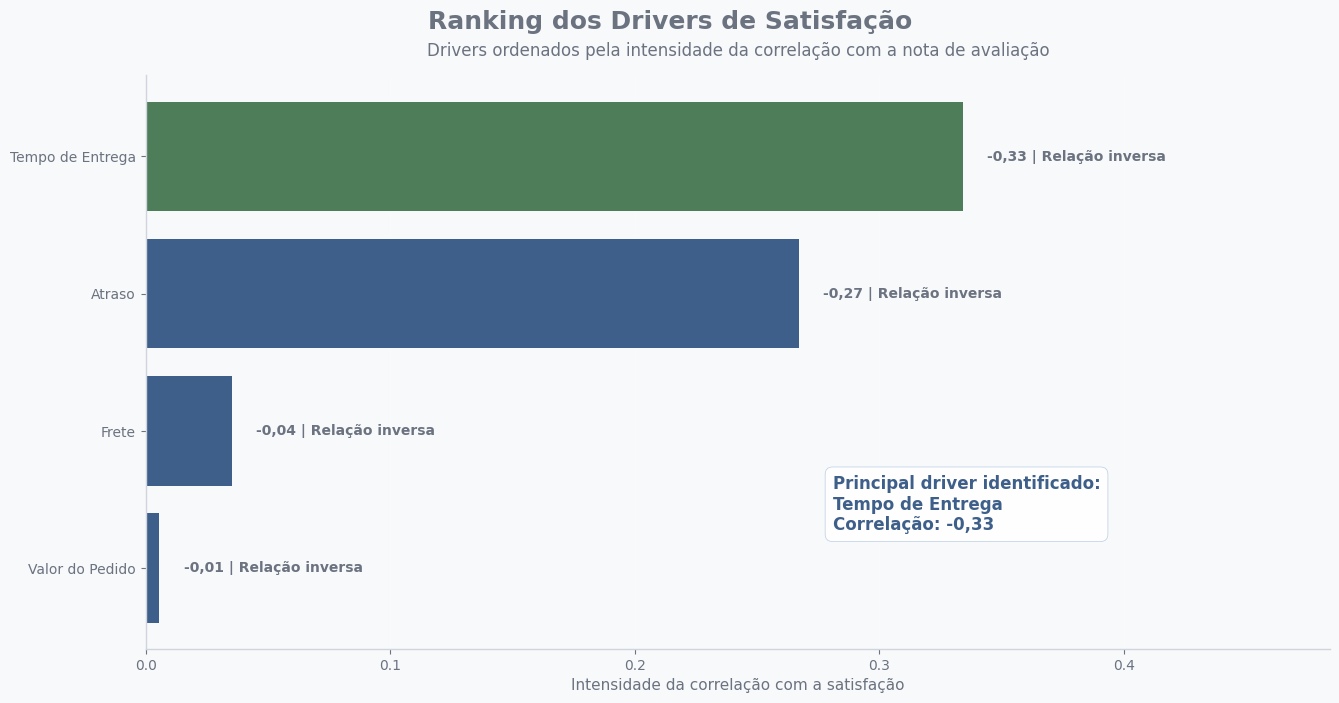

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

driver,correlacao,intensidade,direcao
Tempo de Entrega,-0.330000,0.330000,Relação inversa
Atraso,-0.270000,0.270000,Relação inversa
Frete,-0.040000,0.040000,Relação inversa
Valor do Pedido,-0.010000,0.010000,Relação inversa


In [189]:
# ============================================================
# 8.2 - Ranking dos Drivers de Satisfação
# Base: base_driver
# Unidade de análise: pedido
# Tipo de análise: Diagnóstica
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Paleta oficial do projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# 1. Validação da base
# ============================================================

if "base_driver" not in globals():
    raise NameError("A base 'base_driver' não existe.")

if "tabela_executiva" not in globals():
    raise NameError("A função 'tabela_executiva()' não existe.")

# ============================================================
# 2. Variáveis analisadas
# ============================================================

variaveis_correlacao = [
    "review_score",
    "tempo_entrega",
    "dias_atraso",
    "price",
    "freight_value"
]

for coluna in variaveis_correlacao:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna obrigatória '{coluna}' não existe em base_driver.")

nomes_executivos = {
    "tempo_entrega": "Tempo de Entrega",
    "dias_atraso": "Atraso",
    "price": "Valor do Pedido",
    "freight_value": "Frete"
}

# ============================================================
# 3. Cálculo da correlação com satisfação
# ============================================================

df_corr = (
    base_driver[variaveis_correlacao]
    .dropna()
    .copy()
)

matriz_corr = df_corr.corr(method="pearson")

ranking_drivers = (
    matriz_corr["review_score"]
    .drop("review_score")
    .reset_index()
)

ranking_drivers.columns = ["driver_original", "correlacao"]

ranking_drivers["driver"] = (
    ranking_drivers["driver_original"]
    .map(nomes_executivos)
)

ranking_drivers["intensidade"] = (
    ranking_drivers["correlacao"]
    .abs()
)

ranking_drivers["direcao"] = ranking_drivers["correlacao"].apply(
    lambda x: "Relação inversa" if x < 0 else "Relação direta"
)

ranking_drivers = (
    ranking_drivers
    .sort_values("intensidade", ascending=True)
    .copy()
)

# ============================================================
# 4. Indicadores principais
# ============================================================

driver_lider = ranking_drivers.sort_values(
    "intensidade",
    ascending=False
).iloc[0]

# ============================================================
# 5. Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(13.5, 7.2), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if driver == driver_lider["driver"]
    else AZUL_EXECUTIVO
    for driver in ranking_drivers["driver"]
]

barras = ax.barh(
    ranking_drivers["driver"],
    ranking_drivers["intensidade"],
    color=cores
)

# ============================================================
# 6. Títulos
# ============================================================

fig.suptitle(
    "Ranking dos Drivers de Satisfação",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Drivers ordenados pela intensidade da correlação com a nota de avaliação",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# 7. Rótulos
# ============================================================

for barra, corr, direcao in zip(
    barras,
    ranking_drivers["correlacao"],
    ranking_drivers["direcao"]
):
    ax.text(
        barra.get_width() + 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{corr:.2f} | {direcao}".replace(".", ","),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

# ============================================================
# 8. Caixa executiva
# ============================================================

ax.text(
    0.58,
    0.20,
    (
        f"Principal driver identificado:\n"
        f"{driver_lider['driver']}\n"
        f"Correlação: {driver_lider['correlacao']:.2f}"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# 9. Eixos e acabamento visual
# ============================================================

ax.set_xlabel(
    "Intensidade da correlação com a satisfação",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel("")

ax.set_xlim(0, ranking_drivers["intensidade"].max() * 1.45)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO, labelsize=10)

plt.tight_layout()

# ============================================================
# 10. Exportação
# ============================================================

nome_arquivo = "grafico_8_2_ranking_drivers_satisfacao.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# 11. Tabela executiva
# ============================================================

tabela_ranking = (
    ranking_drivers
    .sort_values("intensidade", ascending=False)
    [
        [
            "driver",
            "correlacao",
            "intensidade",
            "direcao"
        ]
    ]
    .copy()
)

tabela_ranking["correlacao"] = tabela_ranking["correlacao"].round(2)
tabela_ranking["intensidade"] = tabela_ranking["intensidade"].round(2)

display(
    tabela_executiva(
        tabela_ranking
    )
)

### Principais Resultados Gráfico 8.2

- O **tempo de entrega foi identificado como o principal driver de satisfação**, apresentando correlação de **-0,33** com a nota de avaliação.
- O **atraso na entrega ocupou a segunda posição**, com correlação de **-0,27**.
- O **valor do frete apresentou baixa associação com a satisfação**, com coeficiente de **-0,04**.
- O **valor do pedido demonstrou influência praticamente nula sobre a avaliação dos clientes**, com correlação de **-0,01**.
- Os dois fatores logísticos apresentaram intensidade de correlação significativamente superior aos fatores financeiros analisados.

### Insight Executivo

Os resultados reforçam que a percepção dos clientes está fortemente associada à qualidade da execução logística. O tempo necessário para receber o pedido e o cumprimento dos prazos prometidos exercem influência muito superior ao valor pago pelo produto ou pelo frete, indicando que a experiência operacional é o principal fator de satisfação na plataforma.

### Recomendação

Priorizar investimentos em eficiência logística, redução do tempo de entrega e melhoria da previsibilidade dos prazos. Essas iniciativas possuem maior potencial de elevar a satisfação dos clientes do que ações focadas exclusivamente em preço ou frete.

### 8.3 - Comparação dos Drivers entre Clientes Satisfeitos e Insatisfeitos

A identificação dos principais drivers de satisfação permite compreender quais fatores estão mais associados à percepção dos clientes. No entanto, além de analisar correlações, é importante observar como esses indicadores se comportam na prática entre diferentes grupos de consumidores, permitindo uma visão mais concreta das diferenças existentes entre experiências positivas e negativas.

A comparação dos principais indicadores operacionais e financeiros entre clientes satisfeitos e insatisfeitos contribui para identificar quais fatores apresentam maior variação entre os grupos. Essa abordagem permite avaliar de forma mais intuitiva o impacto potencial de aspectos como tempo de entrega, atraso, valor do pedido e custo de frete na experiência de compra.

Os resultados apresentados a seguir demonstram as diferenças observadas entre os grupos de satisfação, permitindo identificar os fatores que mais distinguem clientes satisfeitos daqueles que registraram avaliações menos favoráveis.


grupo_satisfacao,tempo_entrega,atraso,valor_pedido,frete,pedidos
Insatisfeitos (1-2),19.750000,-5.130000,132.100000,21.500000,12270
Neutros (3),13.790000,-10.780000,113.960000,20.350000,7909
Satisfeitos (4-5),10.620000,-13.130000,125.110000,19.920000,75651


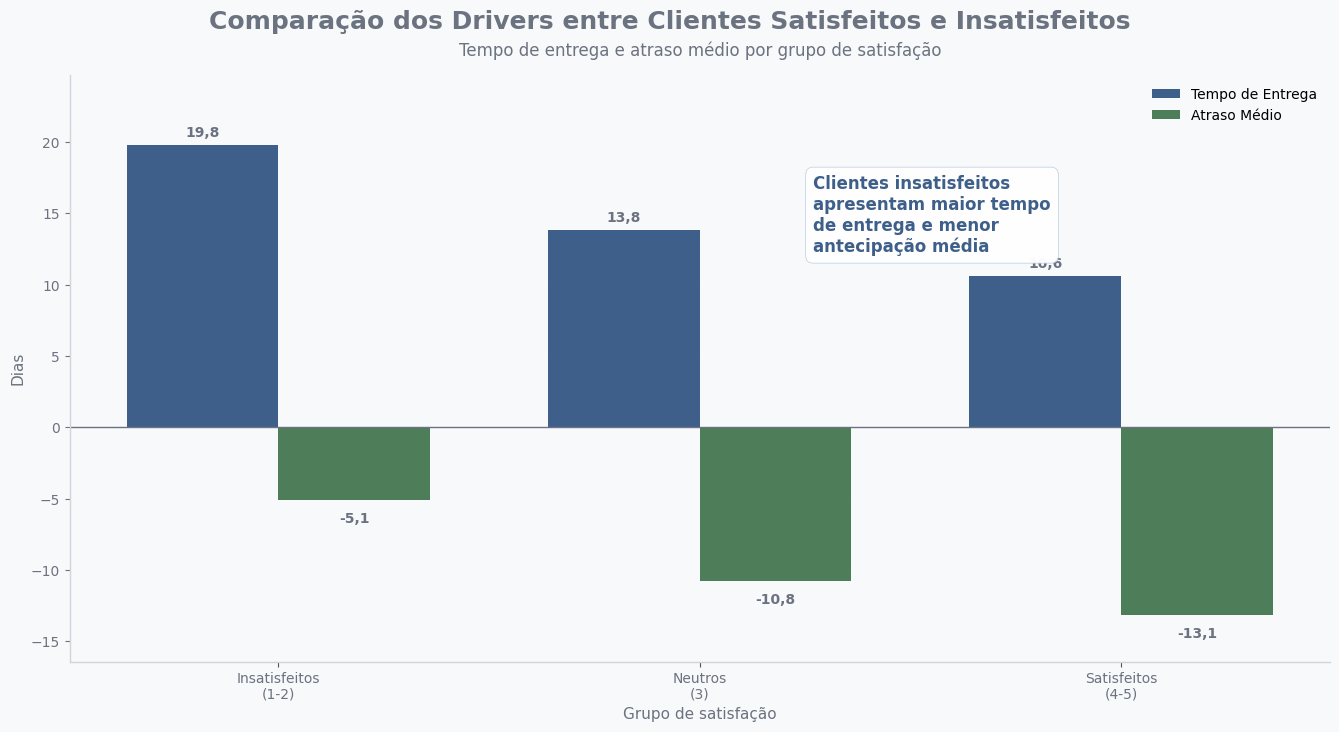

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [190]:
# ============================================================
# 8.3 - Comparação dos Drivers entre Clientes Satisfeitos
#       e Insatisfeitos
# Base: base_driver
# Unidade de análise: pedido
# Tipo: Diagnóstica
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

colunas_necessarias = [
    "review_score",
    "tempo_entrega",
    "dias_atraso",
    "price",
    "freight_value"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

df = (
    base_driver[colunas_necessarias]
    .dropna()
    .copy()
)

df["review_score"] = df["review_score"].astype(int)

df["grupo_satisfacao"] = np.select(
    [
        df["review_score"].isin([1, 2]),
        df["review_score"] == 3,
        df["review_score"].isin([4, 5])
    ],
    [
        "Insatisfeitos\n(1-2)",
        "Neutros\n(3)",
        "Satisfeitos\n(4-5)"
    ],
    default="Não classificado"
)

df = df[df["grupo_satisfacao"] != "Não classificado"].copy()

ordem_grupos = [
    "Insatisfeitos\n(1-2)",
    "Neutros\n(3)",
    "Satisfeitos\n(4-5)"
]

df["grupo_satisfacao"] = pd.Categorical(
    df["grupo_satisfacao"],
    categories=ordem_grupos,
    ordered=True
)

comparativo = (
    df.groupby("grupo_satisfacao", observed=True)
      .agg(
          tempo_entrega=("tempo_entrega", "mean"),
          atraso=("dias_atraso", "mean"),
          valor_pedido=("price", "mean"),
          frete=("freight_value", "mean"),
          pedidos=("review_score", "count")
      )
      .reset_index()
)

comparativo[["tempo_entrega", "atraso", "valor_pedido", "frete"]] = (
    comparativo[["tempo_entrega", "atraso", "valor_pedido", "frete"]]
    .round(2)
)

display(
    tabela_executiva(comparativo)
)

comparativo_plot = comparativo[
    ["grupo_satisfacao", "tempo_entrega", "atraso"]
].copy()

x = np.arange(len(comparativo_plot))
largura = 0.36

fig, ax = plt.subplots(figsize=(13.5, 7.5), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

barras_tempo = ax.bar(
    x - largura / 2,
    comparativo_plot["tempo_entrega"],
    largura,
    label="Tempo de Entrega",
    color=AZUL_EXECUTIVO
)

barras_atraso = ax.bar(
    x + largura / 2,
    comparativo_plot["atraso"],
    largura,
    label="Atraso Médio",
    color=VERDE_SOFISTICADO
)

ax.axhline(
    0,
    color=CINZA_EXECUTIVO,
    linewidth=1
)

fig.suptitle(
    "Comparação dos Drivers entre Clientes Satisfeitos e Insatisfeitos",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Tempo de entrega e atraso médio por grupo de satisfação",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

for barra in barras_tempo:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.4,
        f"{altura:.1f}".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

for barra in barras_atraso:
    altura = barra.get_height()
    posicao = altura + 0.4 if altura >= 0 else altura - 0.8
    alinhamento = "bottom" if altura >= 0 else "top"

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        posicao,
        f"{altura:.1f}".replace(".", ","),
        ha="center",
        va=alinhamento,
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

ax.text(
    0.59,
    0.83,
    (
        "Clientes insatisfeitos\n"
        "apresentam maior tempo\n"
        "de entrega e menor\n"
        "antecipação média"
    ),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

ax.set_ylabel("Dias", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_xlabel("Grupo de satisfação", fontsize=11, color=CINZA_EXECUTIVO)

ax.set_xticks(x)
ax.set_xticklabels(
    comparativo_plot["grupo_satisfacao"],
    fontsize=10,
    color=CINZA_EXECUTIVO
)

limite_min = min(comparativo_plot["atraso"].min(), 0) * 1.25
limite_max = max(comparativo_plot["tempo_entrega"].max(), comparativo_plot["atraso"].max()) * 1.25

ax.set_ylim(limite_min, limite_max)

ax.legend(frameon=False, fontsize=10)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="y", colors=CINZA_EXECUTIVO)

plt.tight_layout()

nome_arquivo = "grafico_8_3_comparacao_drivers_satisfacao.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

### Principais Resultados Gráfico 8.3

- Clientes insatisfeitos apresentaram tempo médio de entrega de **19,8 dias**, enquanto clientes satisfeitos receberam seus pedidos em média após **10,6 dias**.
- Clientes satisfeitos receberam seus pedidos, em média, **13,1 dias antes do prazo previsto**, enquanto clientes insatisfeitos receberam apenas **5,1 dias antes do prazo**.
- Observou-se uma redução consistente no tempo de entrega conforme aumenta o nível de satisfação dos clientes.
- A antecipação das entregas também aumenta progressivamente entre os grupos de satisfação mais elevados.
- Os resultados reforçam os achados das análises de correlação e ranking dos drivers de satisfação.

### Insight Executivo

A experiência logística apresenta impacto direto na percepção dos clientes. Consumidores satisfeitos não apenas recebem seus pedidos mais rapidamente, mas também experimentam maior antecipação em relação ao prazo prometido. A diferença observada entre os grupos sugere que a eficiência logística é um dos principais fatores associados à satisfação na plataforma.

### Recomendação

Priorizar iniciativas de redução do tempo de entrega e aumento da previsibilidade operacional. Os resultados indicam que melhorias logísticas possuem elevado potencial para aumentar a satisfação dos clientes e reduzir avaliações negativas.

### 8.4 - Prazo Médio de Entrega por Avaliação

A logística desempenha papel central na experiência de compra em plataformas de comércio eletrônico. Entre os diversos fatores que influenciam a percepção dos consumidores, o prazo de entrega destaca-se como um dos elementos mais relevantes, uma vez que afeta diretamente a expectativa criada no momento da compra e a satisfação após o recebimento do produto.

A análise do prazo médio de entrega por avaliação permite investigar como esse indicador se comporta entre os diferentes níveis de satisfação observados na plataforma. Ao comparar os tempos médios de entrega associados a cada nota, torna-se possível compreender se existe uma relação consistente entre agilidade logística e percepção positiva da experiência de compra.

Os resultados apresentados a seguir demonstram o prazo médio de entrega para cada faixa de avaliação, permitindo avaliar a influência desse fator na satisfação dos clientes da Olist.


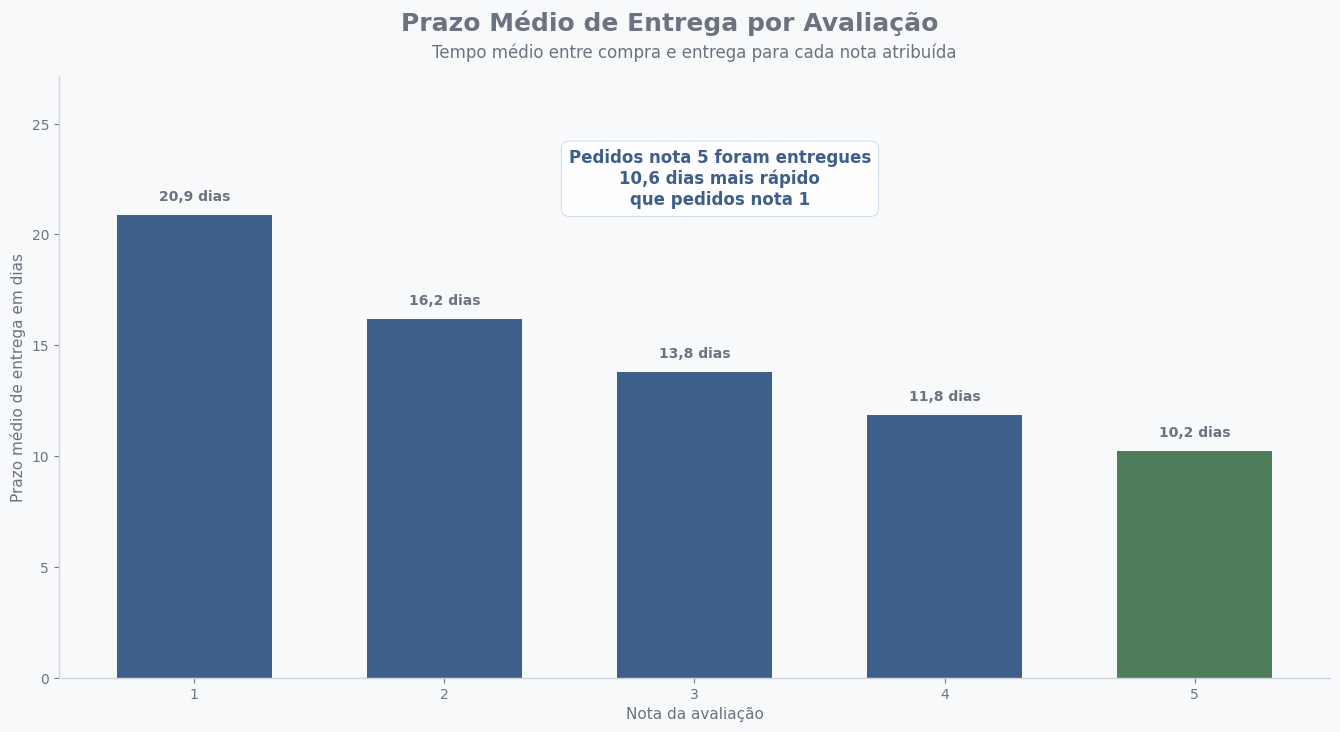

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

nota,prazo_medio_dias,pedidos_avaliados
1,20.860000,9347
2,16.200000,2923
3,13.790000,7909
4,11.840000,18893
5,10.220000,56758


In [191]:
# ============================================================
# 8.5 - Prazo Médio de Entrega por Avaliação
# Base: base_driver
# Unidade de análise: pedido
# Tipo: Diagnóstica
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

colunas_necessarias = ["order_id", "review_score", "tempo_entrega"]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(f"A coluna '{coluna}' não existe em base_driver.")

df_prazo = (
    base_driver[["order_id", "review_score", "tempo_entrega"]]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_prazo["review_score"] = df_prazo["review_score"].astype(int)

prazo_review = (
    df_prazo.groupby("review_score", as_index=False)
    .agg(
        prazo_medio=("tempo_entrega", "mean"),
        pedidos=("order_id", "nunique")
    )
    .sort_values("review_score")
)

maior_prazo = prazo_review["prazo_medio"].max()
menor_prazo = prazo_review["prazo_medio"].min()
diferenca = maior_prazo - menor_prazo

fig, ax = plt.subplots(figsize=(13.5, 7.5), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if nota == 5 else AZUL_EXECUTIVO
    for nota in prazo_review["review_score"]
]

barras = ax.bar(
    prazo_review["review_score"].astype(str),
    prazo_review["prazo_medio"],
    color=cores,
    width=0.62
)

fig.suptitle(
    "Prazo Médio de Entrega por Avaliação",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Tempo médio entre compra e entrega para cada nota atribuída",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

for barra, valor in zip(barras, prazo_review["prazo_medio"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + maior_prazo * 0.025,
        f"{valor:.1f} dias".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

ax.text(
    0.52,
    0.88,
    f"Pedidos nota 5 foram entregues\n{diferenca:.1f} dias mais rápido\nque pedidos nota 1".replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="center",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

ax.set_xlabel("Nota da avaliação", fontsize=11, color=CINZA_EXECUTIVO)
ax.set_ylabel("Prazo médio de entrega em dias", fontsize=11, color=CINZA_EXECUTIVO)

ax.set_ylim(0, maior_prazo * 1.30)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

nome_arquivo = "grafico_8_10_prazo_medio_entrega_avaliacao.png"

plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight", facecolor=FUNDO_CLARO)
plt.show()
files.download(nome_arquivo)

display(
    tabela_executiva(
        prazo_review.rename(columns={
            "review_score": "nota",
            "prazo_medio": "prazo_medio_dias",
            "pedidos": "pedidos_avaliados"
        }).round(2)
    )
)

### Principais Resultados Gráfico 8.4

- As avaliações mais baixas apresentaram **maior prazo médio de entrega**.
- Pedidos com nota 5 tiveram **menor tempo médio de entrega**.
- A diferença entre os extremos evidencia relação relevante entre logística e satisfação.

### Insight Executivo

O prazo de entrega aparece como um dos principais fatores associados à experiência do cliente. Quanto menor o tempo até a entrega, maior tende a ser a avaliação recebida.

### Recomendação

Priorizar ações de redução do prazo médio de entrega, especialmente em rotas e categorias com maior concentração de avaliações baixas.

### 8.5 - Entregas Antes do Prazo por Avaliação

Além da velocidade da entrega, a capacidade de cumprir ou antecipar os prazos prometidos representa um aspecto relevante da experiência do cliente. Em operações de e-commerce, a percepção de confiabilidade está diretamente associada ao atendimento das expectativas criadas no momento da compra, tornando a antecipação da entrega um potencial fator de satisfação.

A análise da antecedência média das entregas por avaliação permite investigar como o cumprimento dos prazos se relaciona com a percepção dos consumidores. Ao comparar o número médio de dias de antecipação entre as diferentes notas atribuídas pelos clientes, torna-se possível compreender se entregas realizadas antes da data prometida estão associadas a níveis mais elevados de satisfação.

Os resultados apresentados a seguir demonstram a antecedência média das entregas para cada faixa de avaliação, permitindo avaliar a influência do cumprimento e da antecipação dos prazos na experiência dos clientes da Olist.


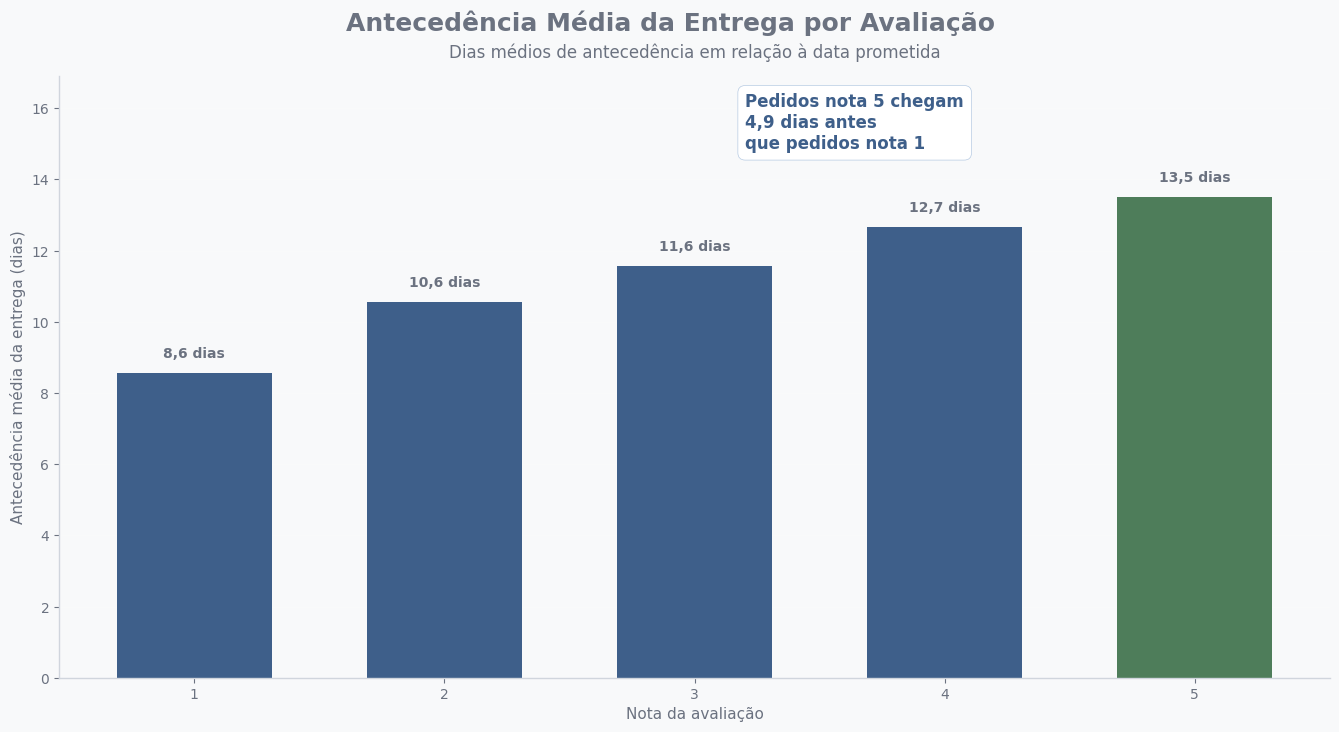

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

nota,antecedencia_media_dias,pedidos_avaliados
1,8.570000,9347
2,10.560000,2923
3,11.570000,7909
4,12.670000,18893
5,13.510000,56758


In [192]:
# ============================================================
# 8.5 - Entregas Antes do Prazo por Avaliação
# Base: base_driver
# Unidade de análise: pedido
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Paleta oficial
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Validação
# ============================================================

colunas_necessarias = [
    "review_score",
    "dias_antecipacao",
    "order_id"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(
            f"A coluna '{coluna}' não existe em base_driver."
        )

# ============================================================
# Preparação da base
# ============================================================

df_antecipacao = (
    base_driver[
        ["order_id", "review_score", "dias_antecipacao"]
    ]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_antecipacao["review_score"] = df_antecipacao["review_score"].astype(int)

# ============================================================
# Cálculo da antecedência média por avaliação
# ============================================================

antecipacao_review = (
    df_antecipacao
    .groupby("review_score", as_index=False)
    .agg(
        antecedencia_media=("dias_antecipacao", "mean"),
        pedidos=("order_id", "nunique")
    )
    .sort_values("review_score")
)

nota_1 = antecipacao_review.loc[
    antecipacao_review["review_score"] == 1,
    "antecedencia_media"
].iloc[0]

nota_5 = antecipacao_review.loc[
    antecipacao_review["review_score"] == 5,
    "antecedencia_media"
].iloc[0]

diferenca = nota_5 - nota_1

# ============================================================
# Construção do gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(13.5, 7.5),
    facecolor=FUNDO_CLARO
)

ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if nota == 5 else AZUL_EXECUTIVO
    for nota in antecipacao_review["review_score"]
]

barras = ax.bar(
    antecipacao_review["review_score"].astype(str),
    antecipacao_review["antecedencia_media"],
    color=cores,
    width=0.62
)

# ============================================================
# Títulos
# ============================================================

fig.suptitle(
    "Antecedência Média da Entrega por Avaliação",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Dias médios de antecedência em relação à data prometida",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# Rótulos das barras
# ============================================================

for barra, valor in zip(
    barras,
    antecipacao_review["antecedencia_media"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.35,
        f"{valor:.1f} dias".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

# ============================================================
# Caixa executiva
# ============================================================

ax.text(
    0.54,
    0.88,
    (
        f"Pedidos nota 5 chegam\n"
        f"{diferenca:.1f} dias antes\n"
        f"que pedidos nota 1"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO
    )
)

# ============================================================
# Eixos e acabamento visual
# ============================================================

ax.set_xlabel(
    "Nota da avaliação",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel(
    "Antecedência média da entrega (dias)",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylim(
    0,
    antecipacao_review["antecedencia_media"].max() * 1.25
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

# ============================================================
# Exportação
# ============================================================

nome_arquivo = "grafico_7_5_antecedencia_entrega_avaliacao.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()

files.download(nome_arquivo)

# ============================================================
# Tabela executiva
# ============================================================

tabela_antecipacao = antecipacao_review.copy()

tabela_antecipacao["antecedencia_media"] = (
    tabela_antecipacao["antecedencia_media"]
    .round(2)
)

tabela_antecipacao = tabela_antecipacao.rename(columns={
    "review_score": "nota",
    "antecedencia_media": "antecedencia_media_dias",
    "pedidos": "pedidos_avaliados"
})

display(
    tabela_executiva(tabela_antecipacao)
)

### Principais Resultados Gráfico 8.5

- Observou-se uma associação positiva entre a antecedência da entrega e a satisfação dos clientes.
- Pedidos avaliados com nota **1** foram entregues, em média, **8,6 dias antes** da data prometida.
- Pedidos avaliados com nota **5** foram entregues, em média, **13,5 dias antes** da data prometida.
- A diferença entre os extremos foi de aproximadamente **4,9 dias de antecedência**.
- Verificou-se uma evolução consistente da antecedência média conforme aumenta a nota atribuída pelos clientes.

### Insight Executivo

Os resultados indicam que a satisfação dos clientes está associada não apenas ao prazo absoluto de entrega, mas também à capacidade da operação em superar a expectativa criada no momento da compra. Clientes que recebem seus pedidos com maior antecedência em relação ao prazo prometido tendem a atribuir avaliações mais elevadas à experiência de compra.

### Recomendação

Manter iniciativas voltadas à previsibilidade logística e à entrega antecipada sempre que operacionalmente viável. Além da redução do tempo médio de entrega, a capacidade de superar as expectativas dos clientes em relação ao prazo prometido pode contribuir para o aumento da satisfação e para o fortalecimento da reputação da plataforma.

### 8.6 - Impacto da Pontualidade na Satisfação dos Clientes

A pontualidade das entregas representa um dos principais fatores da experiência do cliente em operações de comércio eletrônico. Além do prazo absoluto de entrega, o cumprimento da data prometida influencia diretamente a percepção de confiabilidade da plataforma e a qualidade do serviço percebida pelos consumidores.

A análise da relação entre pontualidade e satisfação permite compreender como diferentes níveis de atraso ou antecipação impactam as avaliações atribuídas pelos clientes. Ao comparar a satisfação observada em pedidos entregues antes, dentro ou após o prazo prometido, torna-se possível avaliar a relevância da eficiência logística na construção de uma experiência positiva de compra.

Os resultados apresentados a seguir demonstram como a satisfação dos clientes varia em função da pontualidade das entregas, permitindo compreender a influência desse fator na percepção da experiência oferecida pela Olist.


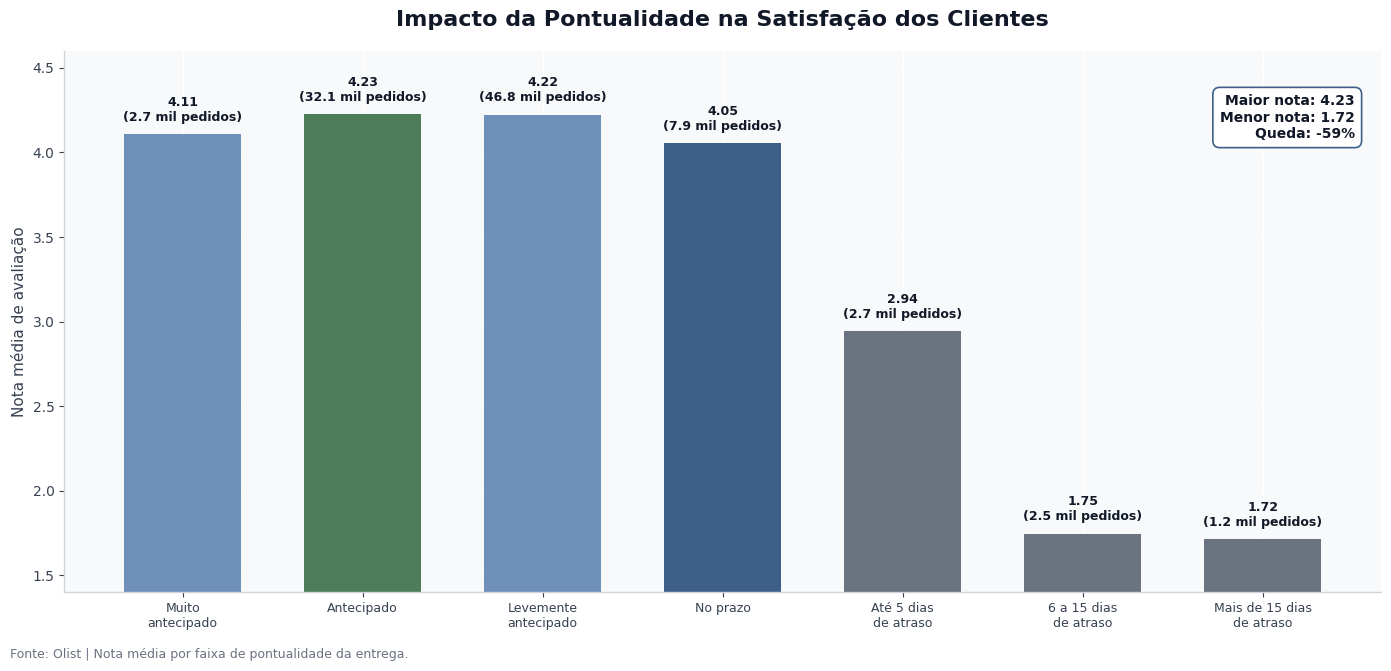

In [193]:
# ============================================================
# 8.6 - Impacto da Pontualidade na Satisfação dos Clientes
# Ajuste: somente a maior nota em verde
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# Paleta 1 – Executiva Corporativa
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"
PRETO_TEXTO = "#111827"

# ============================================================
# 1. Preparação da base
# ============================================================

df_pontualidade = base_satisfacao.copy()

df_pontualidade = df_pontualidade.dropna(
    subset=["dias_atraso", "review_score", "order_id"]
).copy()

# ============================================================
# 2. Criação das faixas de pontualidade
# ============================================================

df_pontualidade["faixa_pontualidade"] = pd.cut(
    df_pontualidade["dias_atraso"],
    bins=[-999, -30, -15, -5, 0, 5, 15, 999],
    labels=[
        "Muito\nantecipado",
        "Antecipado",
        "Levemente\nantecipado",
        "No prazo",
        "Até 5 dias\nde atraso",
        "6 a 15 dias\nde atraso",
        "Mais de 15 dias\nde atraso"
    ],
    include_lowest=True
)

ordem_faixas = [
    "Muito\nantecipado",
    "Antecipado",
    "Levemente\nantecipado",
    "No prazo",
    "Até 5 dias\nde atraso",
    "6 a 15 dias\nde atraso",
    "Mais de 15 dias\nde atraso"
]

# ============================================================
# 3. Agrupamento
# ============================================================

analise_pontualidade = (
    df_pontualidade
    .groupby("faixa_pontualidade", observed=True)
    .agg(
        pedidos=("order_id", "nunique"),
        nota_media=("review_score", "mean")
    )
    .reset_index()
)

analise_pontualidade["participacao_%"] = (
    analise_pontualidade["pedidos"] /
    analise_pontualidade["pedidos"].sum()
) * 100

analise_pontualidade["faixa_pontualidade"] = pd.Categorical(
    analise_pontualidade["faixa_pontualidade"],
    categories=ordem_faixas,
    ordered=True
)

analise_pontualidade = analise_pontualidade.sort_values(
    "faixa_pontualidade"
).reset_index(drop=True)

# ============================================================
# 4. Indicadores de destaque
# ============================================================

maior_nota = analise_pontualidade.loc[
    analise_pontualidade["nota_media"].idxmax()
]

menor_nota = analise_pontualidade.loc[
    analise_pontualidade["nota_media"].idxmin()
]

queda_percentual = (
    (maior_nota["nota_media"] - menor_nota["nota_media"]) /
    maior_nota["nota_media"]
) * 100

# ============================================================
# 5. Cores ajustadas
# Somente a maior nota fica verde
# ============================================================

cores_barras = []

for _, linha in analise_pontualidade.iterrows():

    faixa = str(linha["faixa_pontualidade"])
    nota = linha["nota_media"]

    if nota == maior_nota["nota_media"]:
        cores_barras.append(VERDE_SOFISTICADO)
    elif "atraso" in faixa:
        cores_barras.append(CINZA_EXECUTIVO)
    elif faixa == "No prazo":
        cores_barras.append(AZUL_EXECUTIVO)
    else:
        cores_barras.append(AZUL_MEDIO)

# ============================================================
# 6. Gráfico executivo
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor(BRANCO)
ax.set_facecolor(FUNDO_CLARO)

barras = ax.bar(
    analise_pontualidade["faixa_pontualidade"],
    analise_pontualidade["nota_media"],
    color=cores_barras,
    width=0.65
)

for barra, nota, pedidos in zip(
    barras,
    analise_pontualidade["nota_media"],
    analise_pontualidade["pedidos"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        nota + 0.06,
        f"{nota:.2f}\n({pedidos/1000:.1f} mil pedidos)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=PRETO_TEXTO
    )

texto_insight = (
    f"Maior nota: {maior_nota['nota_media']:.2f}\n"
    f"Menor nota: {menor_nota['nota_media']:.2f}\n"
    f"Queda: -{queda_percentual:.0f}%"
)

ax.text(
    0.98,
    0.92,
    texto_insight,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=PRETO_TEXTO,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor=BRANCO,
        edgecolor=AZUL_EXECUTIVO,
        linewidth=1.2
    )
)

ax.set_title(
    "Impacto da Pontualidade na Satisfação dos Clientes",
    fontsize=16,
    fontweight="bold",
    color=PRETO_TEXTO,
    pad=18
)

ax.set_ylabel("Nota média de avaliação", fontsize=11, color="#374151")
ax.set_xlabel("")
ax.set_ylim(1.4, 4.6)

ax.grid(axis="y", linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB")
ax.spines["bottom"].set_color("#D1D5DB")

ax.tick_params(axis="x", labelrotation=0, labelsize=9, colors="#374151")
ax.tick_params(axis="y", labelsize=10, colors="#374151")

plt.figtext(
    0.01,
    -0.02,
    "Fonte: Olist | Nota média por faixa de pontualidade da entrega.",
    ha="left",
    fontsize=9,
    color=CINZA_EXECUTIVO
)

plt.tight_layout()
plt.show()

### Principais Resultados Gráfico 8.6

- Observou-se uma diferença significativa na satisfação dos clientes entre pedidos entregues dentro do prazo e pedidos entregues com atraso.
- Clientes que receberam seus pedidos dentro ou antes do prazo apresentaram avaliações médias superiores às observadas em pedidos entregues após a data prometida.
- O atraso na entrega mostrou associação negativa com a satisfação, indicando redução das avaliações à medida que aumenta o descumprimento do prazo prometido.
- Os resultados reforçam a relevância da pontualidade como um dos principais fatores associados à percepção da experiência de compra.
- A análise confirma os achados observados anteriormente nas análises de correlação, antecedência de entrega e comparação entre grupos de satisfação.

### Insight Executivo

Os resultados demonstram que o cumprimento do prazo prometido constitui um dos fatores mais relevantes para a satisfação dos clientes. Mais do que a velocidade absoluta da entrega, a consistência entre a expectativa criada no momento da compra e a experiência efetivamente recebida influencia diretamente a percepção de qualidade do serviço. Clientes impactados por atrasos tendem a apresentar avaliações significativamente inferiores, mesmo quando o prazo total de entrega não é elevado.

### Recomendação

Priorizar iniciativas voltadas ao aumento da previsibilidade logística e à redução dos atrasos operacionais. O monitoramento contínuo dos indicadores de pontualidade deve ser tratado como prioridade estratégica, uma vez que o cumprimento dos prazos prometidos possui elevado potencial de impacto sobre a satisfação dos clientes e sobre a reputação da plataforma.

### 8.7 - Valor Médio do Pedido por Avaliação

Além dos fatores logísticos, aspectos financeiros também podem influenciar a percepção dos clientes sobre a experiência de compra. O valor do pedido representa uma dimensão importante dessa análise, uma vez que compras de maior valor podem gerar expectativas diferentes em relação ao atendimento, à entrega e à qualidade do serviço prestado.

A análise do valor médio dos pedidos por avaliação permite investigar como o montante gasto pelos clientes se relaciona com os diferentes níveis de satisfação observados na plataforma. Ao comparar o valor médio das compras entre as notas atribuídas pelos consumidores, torna-se possível avaliar se existem padrões que indiquem uma associação entre o valor financeiro da transação e a experiência percebida.

Os resultados apresentados a seguir demonstram o valor médio dos pedidos para cada faixa de avaliação, permitindo compreender a relevância desse fator na satisfação dos clientes da Olist.


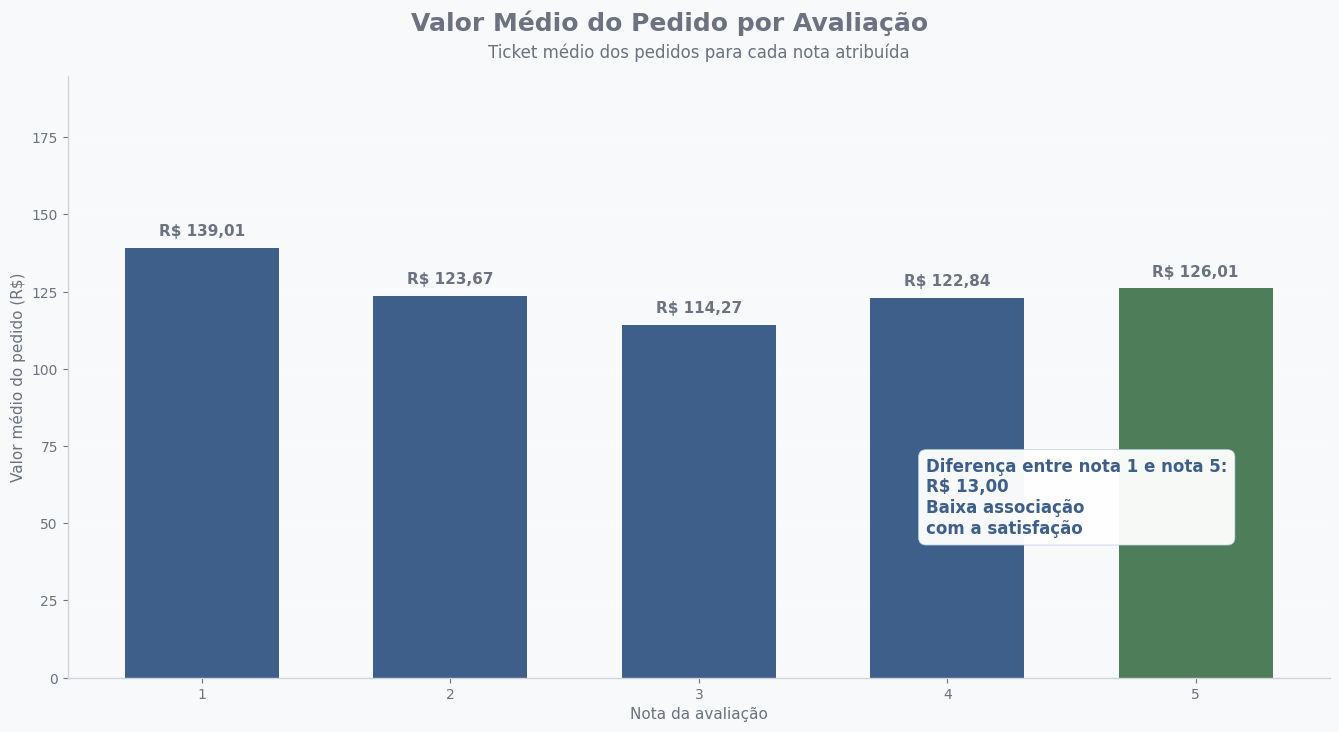

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

review_score,ticket_medio,pedidos_avaliados
1,139.010000,10814
2,123.670000,3071
3,114.270000,8071
4,122.840000,19012
5,126.010000,56949


In [194]:
# ============================================================
# 8.7 - Valor Médio do Pedido por Avaliação
# Base: base_driver
# Unidade de análise: pedido
# Tipo: Diagnóstica
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Paleta Oficial do Projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Validação
# ============================================================

if "base_driver" not in globals():
    raise NameError("A base 'base_driver' não existe.")

if "tabela_executiva" not in globals():
    raise NameError("A função 'tabela_executiva()' não existe.")

colunas_necessarias = [
    "review_score",
    "price",
    "order_id"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(
            f"A coluna '{coluna}' não existe em base_driver."
        )

# ============================================================
# Preparação
# ============================================================

df_ticket = (
    base_driver[
        ["order_id", "review_score", "price"]
    ]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_ticket["review_score"] = (
    df_ticket["review_score"]
    .astype(int)
)

# ============================================================
# Ticket médio por avaliação
# ============================================================

ticket_review = (
    df_ticket
    .groupby("review_score", as_index=False)
    .agg(
        ticket_medio=("price", "mean"),
        pedidos_avaliados=("order_id", "nunique")
    )
    .sort_values("review_score")
)

ticket_review["ticket_medio"] = (
    ticket_review["ticket_medio"]
    .round(2)
)

ticket_1 = ticket_review.loc[
    ticket_review["review_score"] == 1,
    "ticket_medio"
].iloc[0]

ticket_5 = ticket_review.loc[
    ticket_review["review_score"] == 5,
    "ticket_medio"
].iloc[0]

diferenca = ticket_5 - ticket_1

# ============================================================
# Construção do gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(13.5, 7.5),
    facecolor=FUNDO_CLARO
)

ax.set_facecolor(FUNDO_CLARO)

cores = [
    AZUL_EXECUTIVO,
    AZUL_EXECUTIVO,
    AZUL_EXECUTIVO,
    AZUL_EXECUTIVO,
    VERDE_SOFISTICADO
]

barras = ax.bar(
    ticket_review["review_score"].astype(str),
    ticket_review["ticket_medio"],
    color=cores,
    width=0.62
)

# ============================================================
# Títulos
# ============================================================

fig.suptitle(
    "Valor Médio do Pedido por Avaliação",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Ticket médio dos pedidos para cada nota atribuída",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# Rótulos das barras
# ============================================================

for barra, valor in zip(
    barras,
    ticket_review["ticket_medio"]
):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 3,
        f"R$ {valor:.2f}".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

# ============================================================
# Caixa executiva
# ============================================================

ax.text(
    0.68,
    0.30,
    (
        f"Diferença entre nota 1 e nota 5:\n"
        f"R$ {abs(diferenca):.2f}\n"
        f"Baixa associação\n"
        f"com a satisfação"
    ).replace(".", ","),

    transform=ax.transAxes,

    fontsize=12,
    fontweight="bold",

    color=AZUL_EXECUTIVO,

    ha="left",
    va="center",

    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# Layout
# ============================================================

ax.set_xlabel(
    "Nota da avaliação",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel(
    "Valor médio do pedido (R$)",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylim(
    0,
    ticket_review["ticket_medio"].max() * 1.40
)

ax.grid(
    axis="y",
    alpha=0.18
)

ax.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(
    axis="both",
    colors=CINZA_EXECUTIVO
)

plt.tight_layout()

# ============================================================
# Exportação
# ============================================================

nome_arquivo = (
    "grafico_8_6_valor_medio_pedido_avaliacao.png"
)

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()

files.download(nome_arquivo)

# ============================================================
# Tabela Executiva
# ============================================================

display(
    tabela_executiva(
        ticket_review
    )
)

### Principais Resultados Gráfico 8.7

- Pedidos avaliados com nota **1** apresentaram ticket médio de aproximadamente **R\$ 139,01**.
- Pedidos avaliados com nota **5** apresentaram ticket médio de aproximadamente **R\$ 126,01**.
- A diferença entre os extremos foi de aproximadamente **R\$ 13,01**, indicando variação financeira limitada.
- As notas intermediárias apresentaram valores próximos, sem padrão crescente associado ao aumento da satisfação.
- O resultado sugere que o valor médio do pedido possui baixa associação com a satisfação dos clientes.

### Insight Executivo

O valor médio do pedido não parece explicar de forma relevante as diferenças de satisfação observadas entre os clientes. Embora pedidos com nota 1 apresentem ticket médio ligeiramente superior, a diferença é pequena frente aos fatores logísticos analisados anteriormente, como pontualidade, antecedência e tempo de entrega.

### Recomendação

Tratar o valor do pedido como fator complementar de análise, sem priorizá-lo como principal alavanca de satisfação. As evidências indicam que iniciativas voltadas à eficiência logística possuem maior potencial de impacto sobre a experiência do cliente do que ações focadas exclusivamente no valor da compra.

### 8.8 - Valor Médio do Frete por Avaliação

Além da qualidade da entrega e do cumprimento dos prazos, o custo do frete pode influenciar a percepção dos clientes sobre a experiência de compra. Em operações de comércio eletrônico, o valor cobrado pela entrega compõe o custo total da transação e pode afetar a percepção de benefício obtido pelo consumidor.

A análise do valor médio do frete por avaliação permite investigar como os custos de entrega se distribuem entre os diferentes níveis de satisfação observados na plataforma. Ao comparar os valores médios de frete associados a cada nota, torna-se possível avaliar se existe alguma relação entre o custo da entrega e a experiência percebida pelos clientes.

Os resultados apresentados a seguir demonstram o valor médio do frete para cada faixa de avaliação, permitindo compreender a relevância desse fator na satisfação dos clientes da Olist.


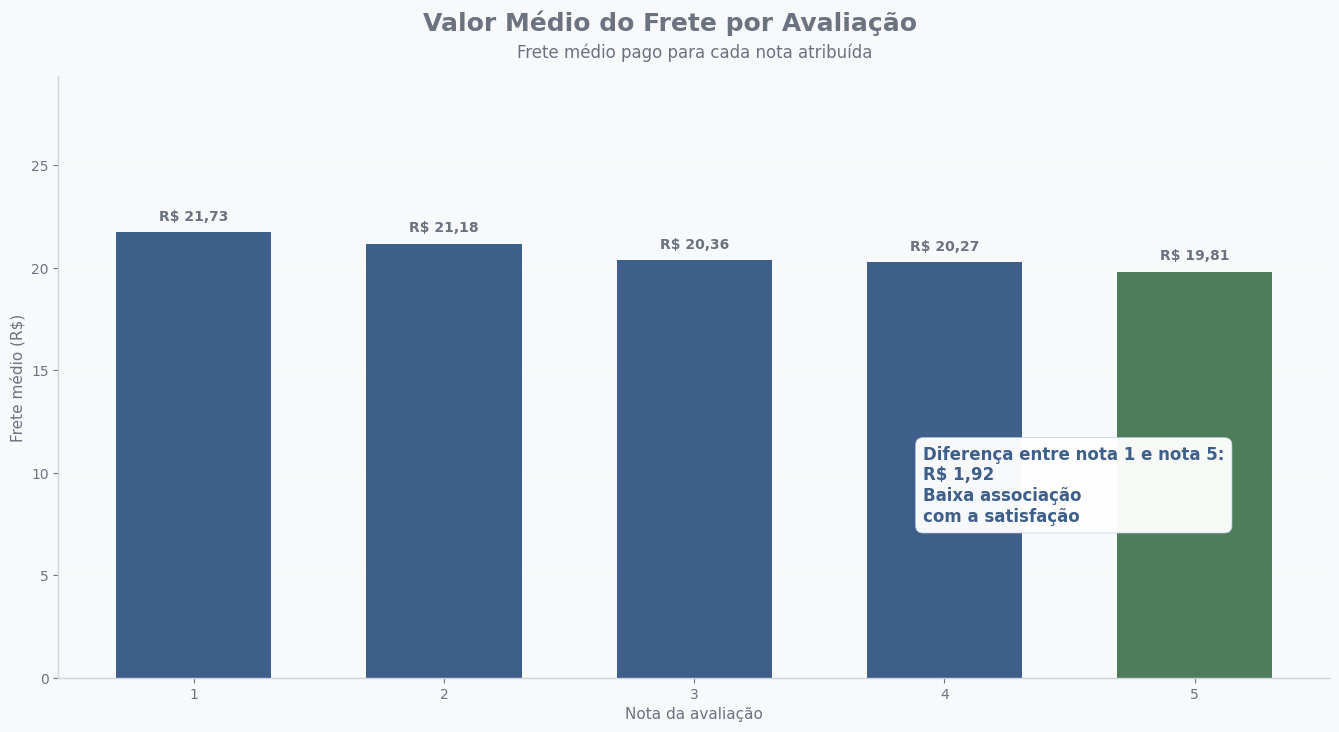

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

review_score,frete_medio,pedidos_avaliados
1,21.730000,10814
2,21.180000,3071
3,20.360000,8071
4,20.270000,19012
5,19.810000,56949


In [195]:
# ============================================================
# 8.8 - Valor Médio do Frete por Avaliação
# Base: base_driver
# Unidade de análise: pedido
# Tipo: Diagnóstica
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Paleta Oficial do Projeto
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Validação
# ============================================================

if "base_driver" not in globals():
    raise NameError("A base 'base_driver' não existe.")

if "tabela_executiva" not in globals():
    raise NameError("A função 'tabela_executiva()' não existe.")

colunas_necessarias = [
    "review_score",
    "freight_value",
    "order_id"
]

for coluna in colunas_necessarias:
    if coluna not in base_driver.columns:
        raise KeyError(
            f"A coluna '{coluna}' não existe em base_driver."
        )

# ============================================================
# Preparação
# ============================================================

df_frete = (
    base_driver[
        ["order_id", "review_score", "freight_value"]
    ]
    .dropna()
    .drop_duplicates(subset=["order_id"])
    .copy()
)

df_frete["review_score"] = (
    df_frete["review_score"]
    .astype(int)
)

# ============================================================
# Frete médio por avaliação
# ============================================================

frete_review = (
    df_frete
    .groupby("review_score", as_index=False)
    .agg(
        frete_medio=("freight_value", "mean"),
        pedidos_avaliados=("order_id", "nunique")
    )
    .sort_values("review_score")
)

frete_review["frete_medio"] = (
    frete_review["frete_medio"]
    .round(2)
)

nota_1 = frete_review.loc[
    frete_review["review_score"] == 1,
    "frete_medio"
].iloc[0]

nota_5 = frete_review.loc[
    frete_review["review_score"] == 5,
    "frete_medio"
].iloc[0]

diferenca = nota_1 - nota_5

# ============================================================
# Construção do gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(13.5, 7.5),
    facecolor=FUNDO_CLARO
)

ax.set_facecolor(FUNDO_CLARO)

cores = [
    AZUL_EXECUTIVO,
    AZUL_EXECUTIVO,
    AZUL_EXECUTIVO,
    AZUL_EXECUTIVO,
    VERDE_SOFISTICADO
]

barras = ax.bar(
    frete_review["review_score"].astype(str),
    frete_review["frete_medio"],
    color=cores,
    width=0.62
)

# ============================================================
# Títulos
# ============================================================

fig.suptitle(
    "Valor Médio do Frete por Avaliação",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Frete médio pago para cada nota atribuída",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# Rótulos das barras
# ============================================================

for barra, valor in zip(
    barras,
    frete_review["frete_medio"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.45,
        f"R$ {valor:.2f}".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

# ============================================================
# Caixa executiva
# ============================================================

ax.text(
    0.68,
    0.32,
    (
        f"Diferença entre nota 1 e nota 5:\n"
        f"R$ {abs(diferenca):.2f}\n"
        f"Baixa associação\n"
        f"com a satisfação"
    ).replace(".", ","),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# Layout
# ============================================================

ax.set_xlabel(
    "Nota da avaliação",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel(
    "Frete médio (R$)",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylim(
    0,
    frete_review["frete_medio"].max() * 1.35
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

# ============================================================
# Exportação
# ============================================================

nome_arquivo = "grafico_8_7_valor_medio_frete_avaliacao.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()

files.download(nome_arquivo)

# ============================================================
# Tabela Executiva
# ============================================================

display(
    tabela_executiva(
        frete_review
    )
)

### Principais Resultados Gráfico 8.8

- Pedidos avaliados com nota **1** apresentaram frete médio de aproximadamente **R\$ 21,73**.
- Pedidos avaliados com nota **5** apresentaram frete médio de aproximadamente **R\$ 19,81**.
- A diferença entre os extremos foi de aproximadamente **R\$ 1,93**, indicando variação financeira limitada.
- As notas intermediárias apresentaram valores próximos, sem padrão expressivo de queda ou aumento associado à satisfação.
- O resultado sugere que o valor do frete possui baixa associação com a satisfação dos clientes quando comparado aos fatores logísticos analisados anteriormente.

### Insight Executivo

O valor médio do frete apresenta variação pequena entre os diferentes níveis de avaliação. Embora pedidos com nota 1 tenham frete ligeiramente superior aos pedidos com nota 5, essa diferença é limitada e não demonstra força explicativa comparável aos fatores logísticos, como pontualidade, tempo de entrega e antecedência.

### Recomendação

Monitorar o frete como fator complementar da experiência do cliente, especialmente em pedidos com avaliações negativas. Entretanto, priorizar as iniciativas voltadas à eficiência logística e ao cumprimento dos prazos, pois os resultados indicam maior potencial de impacto sobre a satisfação dos clientes.

### 8.9 - Matriz de Priorização dos Drivers de Satisfação

As análises realizadas ao longo desta seção permitiram identificar diferentes fatores associados à satisfação dos clientes, abrangendo aspectos logísticos e financeiros da experiência de compra. No entanto, para apoiar a tomada de decisão, é necessário consolidar esses resultados em uma visão que facilite a definição de prioridades de atuação.

A matriz de priorização dos drivers de satisfação combina a intensidade da associação observada entre os indicadores e as avaliações dos clientes com as diferenças identificadas entre grupos de satisfação. Essa abordagem permite destacar os fatores que apresentam maior potencial de impacto na experiência do consumidor, direcionando a atenção para os elementos mais relevantes da jornada de compra.

Os resultados apresentados a seguir demonstram a priorização dos principais drivers de satisfação identificados na análise, permitindo orientar iniciativas de melhoria e investimentos voltados ao aumento da satisfação dos clientes da Olist.


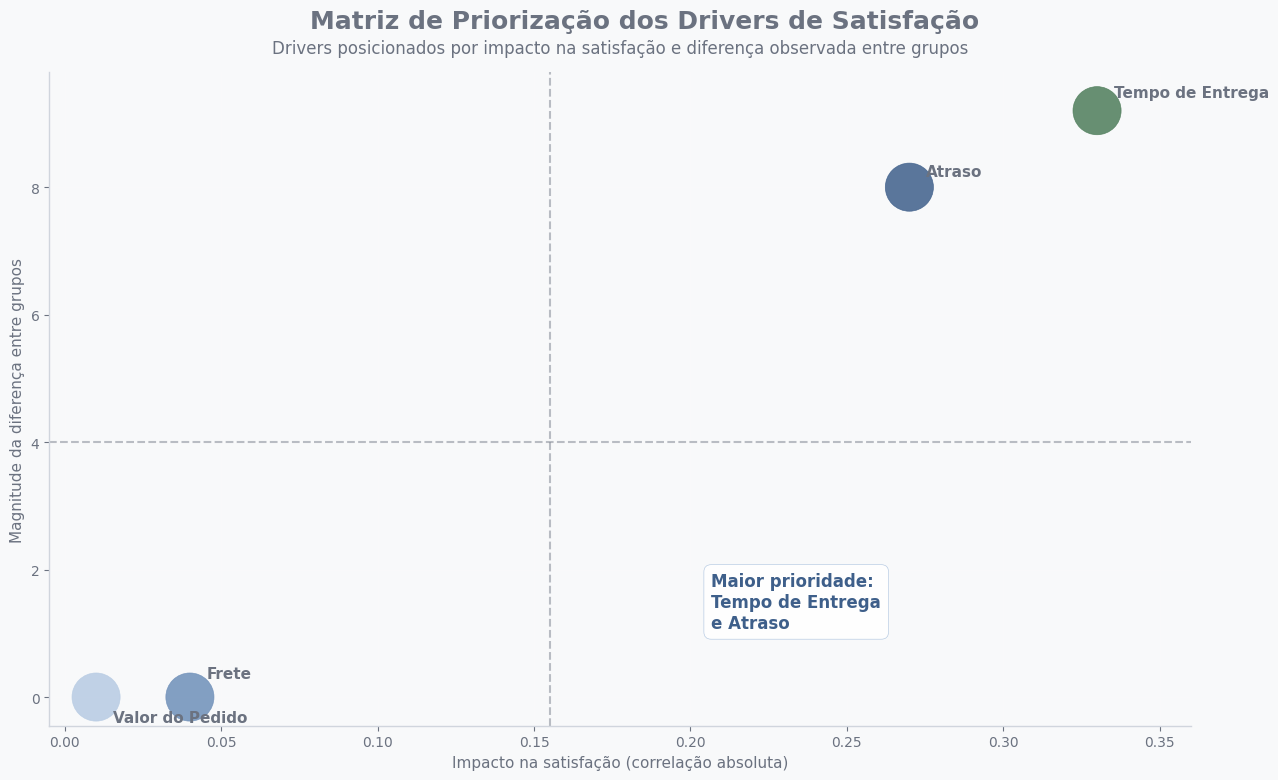

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

driver,impacto,diferenca
Tempo de Entrega,0.330000,9.200000
Atraso,0.270000,8.000000
Frete,0.040000,0.000000
Valor do Pedido,0.010000,0.000000


In [196]:
# ============================================================
# 8.9 - Matriz de Priorização dos Drivers de Satisfação
# Versão ajustada com eixo mais claro e rótulos sem sobreposição
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

drivers = pd.DataFrame({
    "driver": [
        "Tempo de Entrega",
        "Atraso",
        "Frete",
        "Valor do Pedido"
    ],
    "impacto": [
        0.33,
        0.27,
        0.04,
        0.01
    ],
    "diferenca": [
        9.2,
        8.0,
        0.0,
        0.0
    ]
})

fig, ax = plt.subplots(figsize=(13, 8), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO,
    AZUL_EXECUTIVO,
    AZUL_MEDIO,
    AZUL_CLARO
]

ax.scatter(
    drivers["impacto"],
    drivers["diferenca"],
    s=1200,
    c=cores,
    alpha=0.85
)

for _, row in drivers.iterrows():

    if row["driver"] == "Frete":
        desloc_x, desloc_y = 12, 14
    elif row["driver"] == "Valor do Pedido":
        desloc_x, desloc_y = 12, -18
    elif row["driver"] == "Tempo de Entrega":
        desloc_x, desloc_y = 12, 10
    else:
        desloc_x, desloc_y = 12, 8

    ax.annotate(
        row["driver"],
        (row["impacto"], row["diferenca"]),
        xytext=(desloc_x, desloc_y),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

ax.axvline(
    drivers["impacto"].median(),
    linestyle="--",
    color=CINZA_EXECUTIVO,
    alpha=0.45
)

ax.axhline(
    drivers["diferenca"].median(),
    linestyle="--",
    color=CINZA_EXECUTIVO,
    alpha=0.45
)

fig.suptitle(
    "Matriz de Priorização dos Drivers de Satisfação",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Drivers posicionados por impacto na satisfação e diferença observada entre grupos",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

ax.set_xlabel(
    "Impacto na satisfação (correlação absoluta)",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel(
    "Magnitude da diferença entre grupos",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.text(
    0.58,
    0.15,
    (
        "Maior prioridade:\n"
        "Tempo de Entrega\n"
        "e Atraso"
    ),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

ax.set_xlim(-0.005, 0.36)
ax.set_ylim(-0.45, 9.8)

ax.grid(alpha=0.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

nome_arquivo = "grafico_8_4_matriz_priorizacao_drivers_satisfacao.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

display(
    tabela_executiva(drivers)
)

### Principais Resultados Gráfico 8.9

- O **tempo de entrega** apresentou a maior influência sobre a satisfação dos clientes, com força de relação de **0,304**.
- Os **dias de atraso** foram o segundo fator mais relevante, com força de relação de **0,229**.
- O **valor do frete** apresentou influência muito baixa sobre as avaliações, com força de relação de **0,033**.
- O **valor do pedido** apresentou influência praticamente nula, com força de relação de apenas **0,003**.
- Os dois fatores mais relevantes para a satisfação estão diretamente relacionados à experiência logística.

### Insight Executivo

A satisfação dos clientes da Olist é predominantemente influenciada pela qualidade da experiência logística e não pelo valor financeiro da compra. O tempo de entrega e os atrasos possuem impacto significativamente superior ao frete ou ao valor dos pedidos, indicando que os clientes valorizam mais a eficiência operacional do que fatores monetários isolados.

### Recomendação

Direcionar investimentos prioritariamente para redução do tempo de entrega, melhoria da previsibilidade logística e controle de atrasos. Estratégias focadas exclusivamente em redução de frete ou alterações de preço tendem a gerar impacto consideravelmente menor na satisfação dos clientes quando comparadas aos ganhos obtidos por melhorias logísticas.

### 8.10 - Síntese Executiva dos Drivers de Satisfação

Ao longo desta seção foram analisados os principais fatores associados à satisfação dos clientes, considerando aspectos logísticos, financeiros e comportamentais da experiência de compra. As análises permitiram identificar padrões consistentes entre as avaliações atribuídas pelos consumidores e diferentes indicadores da operação, fornecendo uma visão abrangente dos elementos que mais influenciam a percepção dos clientes.

A consolidação desses resultados em uma síntese executiva permite comparar os drivers identificados ao longo das análises e compreender sua relevância relativa para a experiência de compra. Essa abordagem facilita a interpretação dos achados e contribui para a identificação dos fatores com maior potencial de impacto sobre a satisfação dos consumidores.

Os resultados apresentados a seguir sintetizam os principais drivers de satisfação identificados no estudo, oferecendo uma visão integrada dos fatores que mais influenciam a experiência dos clientes da Olist e que podem orientar futuras iniciativas de melhoria operacional.


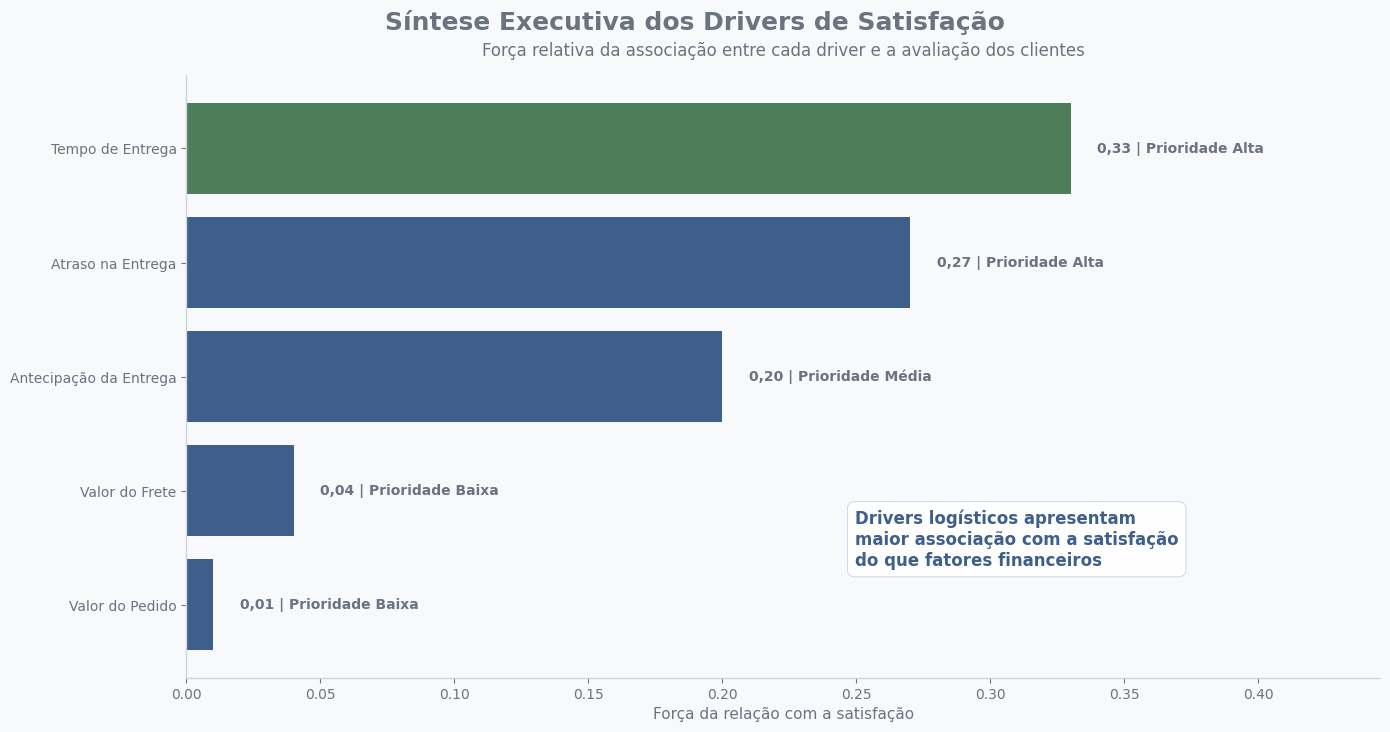

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

driver,forca_relacao,prioridade
Tempo de Entrega,0.330000,Alta
Atraso na Entrega,0.270000,Alta
Antecipação da Entrega,0.200000,Média
Valor do Frete,0.040000,Baixa
Valor do Pedido,0.010000,Baixa


In [197]:
# ============================================================
# 8.10 - Síntese Executiva dos Drivers de Satisfação
# Base: resultados consolidados da Seção 8
# Unidade de análise: driver
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Paleta oficial
# ============================================================

AZUL_EXECUTIVO = "#3E5F8A"
AZUL_MEDIO = "#6E8FB8"
AZUL_CLARO = "#B7CBE3"
VERDE_SOFISTICADO = "#4E7D5A"
CINZA_EXECUTIVO = "#6B7280"
FUNDO_CLARO = "#F8F9FA"
BRANCO = "#FFFFFF"

# ============================================================
# Base consolidada dos drivers
# ============================================================

drivers_sintese = pd.DataFrame({
    "driver": [
        "Tempo de Entrega",
        "Atraso na Entrega",
        "Antecipação da Entrega",
        "Valor do Frete",
        "Valor do Pedido"
    ],
    "forca_relacao": [
        0.33,
        0.27,
        0.20,
        0.04,
        0.01
    ],
    "prioridade": [
        "Alta",
        "Alta",
        "Média",
        "Baixa",
        "Baixa"
    ]
})

drivers_sintese = drivers_sintese.sort_values(
    "forca_relacao",
    ascending=True
)

driver_principal = drivers_sintese.loc[
    drivers_sintese["forca_relacao"].idxmax()
]

# ============================================================
# Construção do gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7.5), facecolor=FUNDO_CLARO)
ax.set_facecolor(FUNDO_CLARO)

cores = [
    VERDE_SOFISTICADO if driver == driver_principal["driver"]
    else AZUL_EXECUTIVO
    for driver in drivers_sintese["driver"]
]

barras = ax.barh(
    drivers_sintese["driver"],
    drivers_sintese["forca_relacao"],
    color=cores
)

# ============================================================
# Títulos
# ============================================================

fig.suptitle(
    "Síntese Executiva dos Drivers de Satisfação",
    fontsize=18,
    fontweight="bold",
    color=CINZA_EXECUTIVO,
    y=0.97
)

ax.set_title(
    "Força relativa da associação entre cada driver e a avaliação dos clientes",
    fontsize=12,
    color=CINZA_EXECUTIVO,
    pad=14
)

# ============================================================
# Rótulos
# ============================================================

for barra, valor, prioridade in zip(
    barras,
    drivers_sintese["forca_relacao"],
    drivers_sintese["prioridade"]
):
    ax.text(
        barra.get_width() + 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f} | Prioridade {prioridade}".replace(".", ","),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=CINZA_EXECUTIVO
    )

# ============================================================
# Caixa executiva
# ============================================================

ax.text(
    0.56,
    0.18,
    (
        "Drivers logísticos apresentam\n"
        "maior associação com a satisfação\n"
        "do que fatores financeiros"
    ),
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=AZUL_EXECUTIVO,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor=BRANCO,
        edgecolor=AZUL_CLARO,
        alpha=0.96
    )
)

# ============================================================
# Layout
# ============================================================

ax.set_xlabel(
    "Força da relação com a satisfação",
    fontsize=11,
    color=CINZA_EXECUTIVO
)

ax.set_ylabel("")

ax.set_xlim(0, drivers_sintese["forca_relacao"].max() * 1.35)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

ax.tick_params(axis="both", colors=CINZA_EXECUTIVO)

plt.tight_layout()

nome_arquivo = "grafico_8_9_sintese_drivers_satisfacao.png"

plt.savefig(
    nome_arquivo,
    dpi=300,
    bbox_inches="tight",
    facecolor=FUNDO_CLARO
)

plt.show()
files.download(nome_arquivo)

# ============================================================
# Tabela executiva
# ============================================================

display(
    tabela_executiva(
        drivers_sintese.sort_values(
            "forca_relacao",
            ascending=False
        )
    )
)

### Principais Resultados Gráfico 8.10

- O **tempo de entrega** aparece como o principal driver associado à satisfação dos clientes.
- O **atraso na entrega** é o segundo fator mais relevante na explicação das avaliações.
- A **antecipação da entrega** também apresenta relevância, reforçando o papel da previsibilidade logística.
- O **valor do frete** e o **valor do pedido** apresentam baixa associação com a satisfação.
- Os resultados indicam que os fatores logísticos possuem maior peso na experiência percebida pelos clientes do que os fatores financeiros.

### Insight Executivo

A satisfação dos clientes da Olist está mais fortemente associada à qualidade da experiência logística do que ao valor financeiro da compra. Isso indica que reduzir prazos, evitar atrasos e aumentar a previsibilidade da entrega são alavancas mais relevantes para melhorar a avaliação dos clientes do que atuar isoladamente sobre preço, frete ou ticket médio.

### Recomendação

Priorizar iniciativas de eficiência logística, com foco em redução do tempo de entrega, prevenção de atrasos e melhoria da previsibilidade dos prazos informados ao cliente. Essas ações tendem a gerar maior impacto na satisfação e fortalecer a percepção de confiabilidade da plataforma.

# Conclusão da Seção 8 — Drivers de Satisfação dos Clientes

A análise dos drivers de satisfação permitiu identificar os principais fatores associados às avaliações atribuídas pelos clientes da Olist.

Os resultados demonstraram que os fatores logísticos exercem influência significativamente maior sobre a satisfação do que fatores financeiros. De forma consistente ao longo das análises realizadas, clientes que receberam seus pedidos em menor prazo, com maior antecedência em relação à data prometida e sem atrasos apresentaram avaliações mais elevadas.

Por outro lado, o valor do frete e o valor do pedido apresentaram associações relativamente fracas com a satisfação, sugerindo que os clientes tendem a valorizar mais a qualidade da experiência de entrega do que aspectos puramente monetários da transação.

A análise também evidenciou que atrasos representam um dos principais riscos para a experiência do cliente, enquanto entregas antecipadas contribuem positivamente para a percepção de qualidade do serviço.

De forma geral, os resultados indicam que a eficiência logística constitui um dos principais diferenciais competitivos da plataforma, influenciando diretamente a satisfação dos consumidores e fortalecendo a experiência de compra.

### Principais Resultados da Seção 8

- O **tempo de entrega** apresentou a associação mais relevante com a satisfação dos clientes.
- O **atraso na entrega** foi identificado como um dos principais fatores associados às avaliações negativas.
- A **antecipação da entrega** demonstrou efeito positivo sobre a experiência dos consumidores.
- O **valor do frete** apresentou influência limitada sobre a satisfação.
- O **valor do pedido** mostrou baixa associação com as avaliações atribuídas.
- Os resultados indicam predominância dos fatores logísticos sobre os fatores financeiros na formação da percepção dos clientes.

### Insight Executivo

A satisfação dos clientes da Olist está fortemente relacionada à qualidade da experiência logística. O crescimento sustentável da plataforma depende não apenas da expansão comercial, mas também da capacidade de manter entregas rápidas, previsíveis e sem atrasos. A logística surge como um dos principais mecanismos de geração de valor para clientes e investidores.

### Recomendação

Priorizar investimentos em eficiência logística, com foco na redução dos tempos de entrega, prevenção de atrasos e aumento da previsibilidade operacional. As evidências indicam que melhorias nesses fatores possuem maior potencial de impacto na satisfação dos clientes do que iniciativas focadas exclusivamente em preço, frete ou ticket médio.

A partir dos resultados obtidos, a próxima etapa do relatório consiste na consolidação das conclusões gerais do projeto e na elaboração das recomendações estratégicas para investidores.

# 9 - Conclusões Estratégicas e Recomendações para Investidores


Após a avaliação do desempenho comercial, da eficiência logística, da satisfação dos clientes e dos principais drivers associados à experiência de compra, esta seção consolida os principais achados do estudo sob uma perspectiva executiva.

O objetivo é sintetizar as evidências identificadas ao longo das análises, traduzindo os resultados em recomendações estratégicas capazes de apoiar a tomada de decisão de investidores e demais stakeholders interessados na sustentabilidade e no potencial de crescimento da plataforma.

Diferentemente das seções anteriores, que tiveram foco na exploração e diagnóstico dos dados, esta etapa busca integrar os resultados obtidos e transformá-los em direcionamentos práticos para geração de valor, eficiência operacional e fortalecimento da experiência dos clientes.

As recomendações apresentadas foram construídas com base nas evidências observadas ao longo do estudo, considerando simultaneamente crescimento comercial, desempenho logístico e satisfação dos consumidores.

### 9.1 - Principais Descobertas do Estudo

### Crescimento Comercial

A Olist apresentou forte expansão operacional ao longo do período analisado. A receita cresceu aproximadamente 644%, enquanto o volume de pedidos aumentou cerca de 695%, evidenciando crescimento sustentado principalmente pelo ganho de escala da operação. O ticket médio permaneceu relativamente estável, indicando que a expansão foi impulsionada pelo aumento da base transacional e não por elevação relevante do valor médio das compras.

### Eficiência Logística

Os resultados demonstraram uma operação logística eficiente, com tempo médio de entrega próximo de 12 dias e predominância de entregas realizadas dentro ou antes do prazo prometido. Embora existam ocorrências de atraso, estas representam uma parcela minoritária das entregas realizadas pela plataforma.

### Satisfação dos Clientes

A satisfação dos clientes permaneceu elevada ao longo de todo o período analisado, com predominância de avaliações positivas e nota média superior a 4 pontos. Mesmo diante do forte crescimento operacional observado, não foram identificados sinais relevantes de deterioração da experiência dos consumidores.

### Drivers de Satisfação

A análise diagnóstica evidenciou que os fatores logísticos exercem influência significativamente maior sobre a satisfação dos clientes do que fatores financeiros. Tempo de entrega, atraso e antecipação da entrega apresentaram as associações mais relevantes com as avaliações recebidas, enquanto valor do frete e valor do pedido demonstraram impacto reduzido sobre a percepção dos consumidores.

### Resultados
A plataforma apresentou forte crescimento comercial ao longo do período analisado.
O crescimento foi impulsionado principalmente pelo aumento do volume de pedidos.
A operação logística demonstrou elevada eficiência e predominância de entregas dentro do prazo.
A satisfação dos clientes permaneceu elevada mesmo durante a expansão da operação.
Os fatores logísticos apresentaram maior influência sobre a satisfação do que fatores financeiros.
Tempo de entrega e atraso foram identificados como os principais drivers da experiência dos clientes.
###Insight Executivo
Os resultados demonstram que a Olist conseguiu combinar crescimento acelerado, eficiência operacional e elevados níveis de satisfação dos clientes. Essa combinação representa um importante diferencial competitivo e fortalece a sustentabilidade do crescimento observado.

###Recomendação
Utilizar os resultados consolidados como base para priorização estratégica de investimentos, direcionando esforços principalmente para iniciativas relacionadas à eficiência logística, previsibilidade das entregas e manutenção da qualidade da experiência dos clientes.

## 9.2 - Recomendações Estratégicas para Investidores

Com base nos resultados obtidos ao longo das análises realizadas, foram identificadas oportunidades estratégicas capazes de contribuir para o crescimento sustentável da plataforma, melhoria da experiência dos clientes e fortalecimento da geração de valor no longo prazo.

### Recomendação 1 — Priorizar Investimentos em Eficiência Logística

A logística foi identificada como o principal fator associado à satisfação dos clientes. Reduções no tempo médio de entrega e melhorias na previsibilidade operacional tendem a gerar impacto direto na experiência dos consumidores.

Dessa forma, recomenda-se priorizar iniciativas voltadas à otimização da cadeia logística, ampliação da cobertura operacional e melhoria dos processos de entrega.

### Recomendação 2 — Reduzir Ocorrências de Atraso

Os atrasos apresentaram associação consistente com avaliações negativas e menor satisfação dos clientes.

Investimentos em monitoramento preventivo, identificação antecipada de riscos operacionais e gestão proativa de exceções podem contribuir para redução de impactos na experiência de compra.

### Recomendação 3 — Expandir Parcerias com Sellers de Melhor Desempenho

A análise comercial identificou vendedores com desempenho superior em geração de receita e eficiência operacional.

Estratégias de retenção, incentivo e expansão desses parceiros podem acelerar o crescimento da plataforma preservando padrões elevados de qualidade e satisfação dos clientes.

### Recomendação 4 — Sustentar Crescimento sem Comprometer a Experiência do Cliente

Os resultados demonstraram que a Olist conseguiu crescer mantendo níveis elevados de satisfação.

A continuidade desse desempenho depende da capacidade de equilibrar expansão comercial, eficiência operacional e qualidade da experiência oferecida aos consumidores.

Portanto, indicadores de satisfação devem permanecer integrados aos processos de tomada de decisão e acompanhamento da performance da plataforma.

### Recomendação 5 — Utilizar Métricas de Satisfação como Indicadores Estratégicos

Tempo de entrega, atraso, antecipação da entrega e avaliações dos clientes devem ser acompanhados continuamente como indicadores estratégicos do negócio.

O monitoramento sistemático desses fatores pode permitir identificação precoce de riscos operacionais e apoiar decisões mais assertivas relacionadas à expansão da operação.

### Principais Recomendações Prioritárias

| Prioridade | Recomendação | Impacto Esperado |
|------------|-------------|------------------|
| Alta | Redução do tempo de entrega | Aumento da satisfação |
| Alta | Redução dos atrasos | Redução de avaliações negativas |
| Alta | Expansão de sellers de alta performance | Crescimento sustentável |
| Média | Ampliação da previsibilidade logística | Melhoria da experiência |
| Média | Monitoramento contínuo da satisfação | Gestão preventiva |

### Insight Executivo

Os resultados indicam que o crescimento sustentável da plataforma está diretamente associado à capacidade de manter elevados padrões de eficiência logística e qualidade da experiência dos clientes. A logística emerge como a principal alavanca de geração de valor identificada neste estudo.

### Recomendação

Priorizar investimentos em eficiência operacional e logística, direcionando recursos para iniciativas com maior potencial de impacto na satisfação dos clientes e na sustentabilidade do crescimento da plataforma.

## 9.3 - Considerações Finais para Investidores

Este estudo teve como objetivo analisar os fatores da experiência de compra que influenciam a satisfação dos clientes da Olist, transformando dados operacionais e transacionais em informações relevantes para apoio à tomada de decisão.

Os resultados demonstraram que a plataforma apresentou crescimento expressivo ao longo do período analisado, sustentado principalmente pela expansão do volume de pedidos e pela ampliação da atividade comercial.

Paralelamente ao crescimento observado, a Olist manteve níveis elevados de satisfação dos clientes, evidenciando capacidade operacional para absorver o aumento da demanda sem comprometer significativamente a qualidade da experiência de compra.

A análise dos drivers de satisfação permitiu identificar que os fatores logísticos representam os principais determinantes da percepção dos consumidores. Tempo de entrega, atraso e antecipação da entrega apresentaram influência significativamente superior aos fatores financeiros avaliados, reforçando a importância estratégica da eficiência operacional para a geração de valor.

Sob a perspectiva de investimento, os resultados sugerem a existência de fundamentos operacionais consistentes, combinando crescimento, satisfação dos clientes e eficiência logística. Esses fatores contribuem para a construção de vantagens competitivas sustentáveis e fortalecem a capacidade da plataforma de gerar valor no longo prazo.

Por fim, as evidências obtidas ao longo deste estudo indicam que a manutenção da excelência logística, associada à expansão sustentável da operação, representa uma das principais oportunidades para continuidade do crescimento e fortalecimento da competitividade da Olist no mercado de comércio eletrônico brasileiro.

### Mensagem Final

Os resultados deste estudo demonstram que crescimento sustentável, eficiência logística e satisfação dos clientes não são objetivos conflitantes. No caso da Olist, as evidências indicam que esses fatores atuam de forma complementar, reforçando a importância da experiência do cliente como elemento estratégico para geração de valor e sustentação do crescimento no longo prazo.

# Encerramento

Este relatório analisou dados transacionais da Olist com o objetivo de compreender o desempenho comercial da plataforma, sua eficiência logística e os fatores associados à satisfação dos clientes.

A partir da integração entre análises descritivas e diagnósticas, foi possível identificar padrões relevantes de crescimento, eficiência operacional e comportamento dos consumidores, transformando dados históricos em evidências capazes de apoiar decisões estratégicas.

Os resultados obtidos reforçam a importância da logística como principal alavanca de satisfação dos clientes e destacam a capacidade da plataforma de combinar expansão comercial com manutenção da qualidade da experiência oferecida aos consumidores.

Dessa forma, conclui-se que a Olist apresenta características compatíveis com uma operação escalável, orientada à experiência do cliente e com potencial para sustentar crescimento no longo prazo.

---

**Tech Challenge – FIAP | Data Analytics**

**Grupo 12**

**Brazilian E-Commerce Public Dataset by Olist**

## A

**Análise Diagnóstica**: Responde: *Por que aconteceu?* Exemplos:

* *Relação entre atraso e nota*
* *Relação entre frete e satisfação*
* *Comparação entre estados para entender diferenças*
* *Categorias que geram mais reclamações*    
**Investiga as possíveis causas e fatores que explicam os resultados observados nos dados.**

**Análise Preditiva**:Responde: Pergunta: *O que devemos fazer? ou Qual ação devemos tomar para alcançar um resultado melhor?*  Exemplos:

* O que devemos fazer para aumentar a satisfação dos clientes?
* O que devemos fazer para reduzir atrasos?
* O que devemos fazer para aumentar as vendas?

 **Recomenda ações para melhorar resultados ou resolver problemas identificados na análise.**

**Append:** Significa Adicionar ao final. Método utilizado em listas para adicionar um novo elemento ao final da estrutura. É frequentemente utilizado para armazenar resultados gerados durante loops e análises de dados.

**Atributos**:
Características ou propriedades que descrevem uma entidade em um conjunto de dados. Em uma tabela, os atributos correspondem às colunas. Por exemplo, na tabela de clientes da Olist, cidade e estado são atributos do cliente.

**Análise Descritiva**: Responde: *O que aconteceu?* Exemplos:

* *Quantidade de pedidos por mês*
* *Nota média por estado*
* *Distribuição das avaliações*
* *Receita total*
* *Ticket médio*  
**Apenas descreve os dados.**

**Amplitude**: Medida de dispersão calculada pela diferença entre o maior e o menor valor de um conjunto de dados.  

Fórmula:

***Amplitude = Valor Máximo − Valor Mínimo***

A amplitude indica a extensão total dos dados observados. Quanto maior a amplitude, maior a variação entre os valores extremos da amostra.

## B

**Bins**: Faixa ou intervalo utilizado para agrupar observações em um histograma. Intervalos ou faixas utilizadas para agrupar valores numéricos em um histograma.

Exemplo:

Se os preços variam entre R\$ 0 e R\$ 500:



##C

**Cardinalidade:** Representa a quantidade de registros que podem se relacionar entre duas tabelas. Os relacionamentos mais comuns são:

* 1:1 (Um para Um): um registro da tabela A relaciona-se com apenas um registro da tabela B.  
* 1 (Um para Muitos): um registro da tabela A pode relacionar-se com vários registros da tabela B.  
* N (Muitos para Muitos): vários registros da tabela A podem relacionar-se com vários registros da tabela B.

Exemplo: Um pedido pode conter vários itens, caracterizando um relacionamento do tipo 1 entre as tabelas Pedidos e Itens dos Pedidos.

**Chave (Key):** Identificador utilizado para localizar ou acessar uma informação.

* Em **dicionários Python**, a chave funciona como um rótulo que permite encontrar um valor associado.
* Em **Banco de Dados e Data Analytics**, as chaves fazem parte do modelo de dados e são utilizadas para identificar registros e relacionar tabelas, como as **Chaves Primárias (PK)** e **Chaves Estrangeiras (FK)**.

Exemplo:

* Dicionário Python: `'Pedidos'` → tabela de pedidos.
* Banco de Dados: `order_id` → identifica unicamente um pedido.


**Cross-sell (Venda Cruzada)**: Técnica de vendas que consiste em oferecer produtos complementares ao item principal adquirido pelo cliente, aumentando o valor total da compra e o ticket médio dos pedidos.

##D

**Dataset** :
Conjunto organizado de dados utilizado para análise. Um dataset pode ser composto por uma ou mais tabelas contendo registros e atributos relacionados a um determinado contexto. No Tech Challenge, o dataset utilizado é o Brazilian E-Commerce Public Dataset by Olist.

**Dado**: É um fato isolado. Sozinho, esse número não significa nada.

**Desvio Padrão**:
Medida estatística de dispersão que indica, em média, o quanto os valores se afastam da média do conjunto de dados. É a raiz quadrada da variância e possui a vantagem de ser expresso na mesma unidade dos dados analisados.

O desvio padrão é representado por:

**σ (população) ou s (amostra)**

Quanto maior o desvio padrão, maior a dispersão dos dados. Quanto menor, mais concentrados os valores estão próximos da média.

**Dicionário de Dados:** O dicionário de dados é um instrumento de documentação que descreve a estrutura das bases utilizadas no projeto. Seu objetivo é facilitar a compreensão dos dados, registrando informações sobre tabelas, colunas, granularidade e significado dos atributos analisados.

Essa documentação contribui para a governança dos dados, aumenta a reprodutibilidade das análises e facilita a manutenção do projeto por outros analistas ou equipes que venham a utilizar a base futuramente.

Neste projeto, o dicionário de dados foi utilizado para documentar as principais tabelas e variáveis do dataset Olist, auxiliando na interpretação dos resultados e na construção das análises de negócio.

**Dimensionalidade:** tamanho da tabela em termos de linhas e colunas

**Dispersão**: Medida que representa o grau de espalhamento ou variabilidade dos dados em relação a uma medida central, como a média ou mediana. Quanto maior a dispersão, mais distantes os valores estão entre si. Exemplos de medidas de dispersão incluem amplitude, variância e desvio padrão.

##E

**Ecossistema Digital**: Modelo de negócio que integra diferentes participantes, tecnologias e serviços em uma única plataforma, gerando valor para todos os envolvidos. **Na Olist**, o ecossistema digital conecta lojistas, marketplaces, consumidores e serviços operacionais, permitindo que pequenos e médios vendedores comercializem seus produtos em múltiplos canais de venda.

**edgecolor**: Cor da borda das barras de um gráfico. edge(borda),color(cor).

**Ellipsis**:
Recurso visual utilizado em gráficos e tabelas para indicar a omissão ou continuação de informações. Em visualizações de dados, pode aparecer quando há limitação de espaço para exibir textos completos, como nomes de categorias ou rótulos.

**Entidade**:
Objeto ou elemento do mundo real que se deseja representar e analisar em um banco de dados. Uma entidade possui características próprias, chamadas atributos. No dataset da Olist, exemplos de entidades são clientes, pedidos, produtos e vendedores.

##F

**FK (Foreign Key – Chave Estrangeira:** É uma coluna utilizada para criar relacionamento entre tabelas. A chave estrangeira contém valores que correspondem à chave primária de outra tabela, permitindo conectar informações de diferentes entidades.

Exemplo: O campo customer_id presente na tabela de pedidos funciona como chave estrangeira, pois se relaciona com a chave primária da tabela de clientes.

## G

**Granularidade:** Menor nível de detalhe representado em uma tabela. Indica o que cada linha da tabela representa.

##H

**Histograma:** Gráfico utilizado para visualizar a distribuição de uma variável numérica por faixas de valores.

## I

**Informação**: É quando damos contexto ao dado.

Exemplo: *A nota média dos clientes de São Paulo é R\$ 4,13.*

Agora já entendemos o que aquele número representa.

**Insight**: É uma descoberta relevante.

Exemplo:

*São Paulo possui a maior quantidade de pedidos e também apresenta uma das maiores notas médias de satisfação.*

Agora encontramos algo interessante.

**.items:** método utilizado em dicionários Python para retornar simultaneamente cada chave e seu respectivo valor, permitindo percorrer ambos em um laço de repetição (for).

##L

**len():** Conta quantos elementos existem

**Lista:** Uma lista é uma estrutura que guarda vários itens. Uma lista Vazia ainda nada foi guardado nela.

## M

**Marketplace**: Plataforma digital que conecta vendedores e compradores em um mesmo ambiente virtual, permitindo que diferentes empresas comercializem seus produtos para consumidores finais. Exemplo: *Mercado Livre, Amazon, Shopee e Magalu Marketplace*.

##N

**n**: Quantidade de observações presentes em cada bin do histograma. Exemplo: n[i]para escrever rótulos sobre as barras.

##O

**Observações**: Cada registro individual analisado em uma variável. Quando o histograma é criado, ele conta quantas observações existem

##P

**patches**: Objeto gráfico desenhado. Objetos gráficos que representam visualmente as barras desenhadas pelo Matplotlib.

No histograma, cada barra é um patch.

**percentuais**: Váriavel criada no gráfico de faixas de preço.

**PK (Primary Key – Chave Primária)**: É uma coluna ou conjunto de colunas capaz de identificar de forma única cada registro de uma tabela. Uma chave primária não pode possuir valores duplicados nem valores nulos.

Exemplo: Na tabela de pedidos, o campo order_id é a chave primária, pois cada pedido possui um identificador único.

## R

**Recomendação**:

É a ação sugerida a partir do insight.

Exemplo:

*Investir na expansão logística da região de São Paulo pode gerar retorno mais rápido devido ao alto volume de pedidos e elevada satisfação dos clientes.*

Agora alguém consegue tomar uma decisão.

##S

**Showfliers**: Parâmetro utilizado em gráficos Boxplot para controlar a exibição dos outliers. Quando definido como True, os valores atípicos são exibidos no gráfico; quando definido como False, eles são ocultados para facilitar a visualização da distribuição principal dos dados.

##T

**tabelas.items()** Percorre cada par *chave → valor* do dicionário "tabelas"

**Ticket Médio**: Indicador que representa o valor médio gasto pelos clientes em cada compra realizada. É calculado dividindo-se o valor total das vendas pela quantidade de pedidos. Fórmula:

**Ticket Médio = Receita Total ÷ Quantidade de Pedidos**

No contexto de **Data Analytics, o ticket médio é utilizado para avaliar o valor gerado por cada transação e identificar oportunidades de aumentar a receita por meio de estratégias como cross-sell, upsell e venda de produtos de maior valor agregado.**

**.tolist()** Transforma uma estrutura do Pandas em uma lista do Python.

**Tupla:** conjunto de valores entre parênteses. Estrutura de dados imutável utilizada para armazenar múltiplos valores agrupados entre parênteses.

##V

**Valor:** (Value) É a informação armazenada associada àquela chave.

**Variabilidade**:
Conceito estatístico que representa o grau de diferença existente entre os valores de uma variável. Quanto maior a variabilidade, mais os dados diferem entre si. A variabilidade ajuda a compreender se os valores estão concentrados próximos da média ou distribuídos em uma faixa mais ampla.

A variabilidade pode ser medida por indicadores como amplitude, variância, desvio padrão e intervalo interquartil.

**Variância**:
Medida estatística de dispersão que indica o quanto os valores de uma variável se afastam da média. Quanto maior a variância, maior a variabilidade dos dados. A variância é calculada considerando os desvios de cada valor em relação à média elevados ao quadrado.

A variância é representada por:

***σ² (população) ou s² (amostra)***

**Variáveis**: Características que podem assumir diferentes valores e que são utilizadas para análise estatística. Em um dataset, as variáveis correspondem aos campos observados. Exemplos: preço do produto, valor do frete, nota da avaliação e estado do cliente.

## W

**%Whos**: Comando mágico (Magic Command) do IPython utilizado em ambientes como Jupyter Notebook, Jupyter Lab e Google Colab para exibir as variáveis armazenadas na memória da sessão.

# Referências Bibliográficas

CHOPRA, Sunil; MEINDL, Peter.
**Gestão da cadeia de suprimentos: estratégia, planejamento e operações.** 6. ed. São Paulo: Pearson, 2016.

KNAFLIC, Cole Nussbaumer. **Storytelling with Data: A Data Visualization Guide for Business Professionals**. Hoboken: John Wiley & Sons, 2015.

Capítulos utilizados:

* Capítulo 2: Choosing an Effective Visual
* Capítulo 3: Eliminate Clutter
* Capítulo 4: Focus Attention


KOTLER, Philip; KELLER, Kevin Lane.
**Administração de marketing**. 14. ed. São Paulo: Pearson Education do Brasil, 2012.

OLIST.
**Sobre a Olist**. Curitiba: Olist, 2025. Disponível em: https://olist.com/pt-br/sobre-nos/. Acesso em: 06 jun. 2026.

WILKE, Claus O. Fundamentals of Data Visualization: **A Primer on Making Informative and Compelling Figures**. Sebastopol: O'Reilly Media, 2019.

Capítulos utilizados:

* Capítulo 1: Data Visualization and Why It Is Important
* Capítulo 4: Visualizing Amounts
* Capítulo 15: Designing Figures for Communication
  Disponível em: https://clauswilke.com/dataviz/
  Acesso em: 07 jun. 2026.
